# Lib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer  
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import tensorflow as tf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.ensemble import StackingRegressor
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
from statsmodels.formula.api import ols
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from scipy.stats import ttest_rel
import shap
import lightgbm as lgb
from sklearn.linear_model import Lasso
from sklearn.svm import SVR
from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from scipy.stats import mannwhitneyu

# Data Import

In [2]:
train_df = pd.read_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Train_Data.csv')
test_df = pd.read_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Test_Data.csv')

In [3]:
train_final_imputation = pd.read_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Train_final_imputation.csv')
test_final_imputation = pd.read_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Test_final_imputation.csv')

train_final_no_imputation = pd.read_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Train_final_no_imputation.csv')
test_final_no_imputation = pd.read_csv('C:/Users/fccat/Desktop/MUDI Lab/Data/Useful data/Test_final_no_imputation.csv')

# With Imputation

In [4]:
# Target
y_train = train_df['Outcome Sociale bin']
y_test = test_df['Outcome Sociale bin']

# Features
X_train = train_final_imputation  
X_test = test_final_imputation    

## Correlazione con la target

C:\Users\fccat\AppData\Local\Temp\ipykernel_4384\1106290792.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.index, y=corr_target.values, palette="coolwarm")


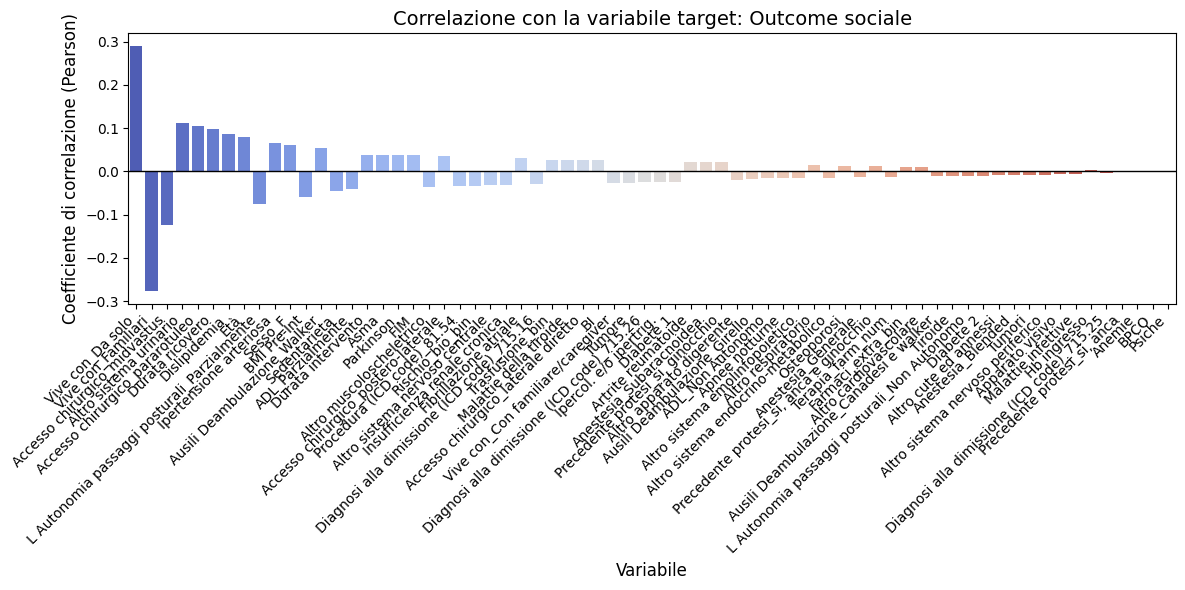

In [5]:

# Unisci X_train e y_train
df_corr = pd.concat([X_train, y_train.rename("Outcome Sociale bin")], axis=1)

# Calcola correlazione solo con la variabile target
corr_target = df_corr.corr()["Outcome Sociale bin"].drop("Outcome Sociale bin")

# Ordina per valore assoluto
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)

# Grafico verticale
plt.figure(figsize=(12, 6))
sns.barplot(x=corr_target.index, y=corr_target.values, palette="coolwarm")
plt.axhline(0, color='black', lw=1)
plt.title("Correlazione con la variabile target: Outcome sociale", fontsize=14)
plt.ylabel("Coefficiente di correlazione (Pearson)", fontsize=12)
plt.xlabel("Variabile", fontsize=12)
plt.xticks(rotation=45, ha='right')  # ruota le etichette per leggerle
plt.tight_layout()
plt.show()

C:\Users\fccat\AppData\Local\Temp\ipykernel_4384\1965090589.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


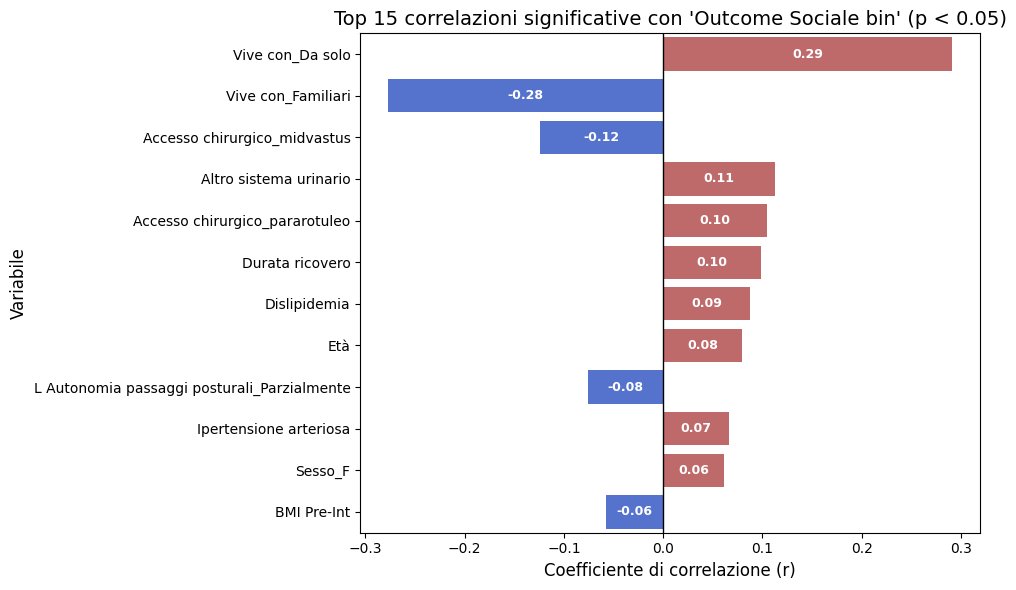

In [6]:
# Unisci X_train e y_train
df_corr = pd.concat([X_train, y_train.rename("Outcome Sociale bin")], axis=1)
target = "Outcome Sociale bin"

# Calcola correlazione e p-value
corr_list = []
for col in X_train.columns:
    r, p = pearsonr(df_corr[col], df_corr[target])
    corr_list.append((col, r, p))

corr_df = pd.DataFrame(corr_list, columns=["Variabile", "r", "p_value"])

# Filtra solo correlazioni significative (p < 0.05)
p_cutoff = 0.05
corr_df_sig = corr_df[corr_df["p_value"] < p_cutoff]

# Mostra top N correlazioni per valore assoluto
top_n = 15
corr_df_sig = corr_df_sig.reindex(corr_df_sig["r"].abs().sort_values(ascending=False).head(top_n).index)

# Colori invertiti: rosso = positiva, blu = negativa
colors = ["indianred" if x > 0 else "royalblue" for x in corr_df_sig["r"]]

# Grafico orizzontale
plt.figure(figsize=(10, 6))
bars = sns.barplot(
    x="r",
    y="Variabile",
    data=corr_df_sig,
    palette=colors
)
plt.axvline(0, color='black', lw=1)
plt.title(f"Top {top_n} correlazioni significative con '{target}' (p < {p_cutoff})", fontsize=14)
plt.xlabel("Coefficiente di correlazione (r)", fontsize=12)
plt.ylabel("Variabile", fontsize=12)

# Aggiungi valori r dentro le barre
for bar, r_val in zip(bars.patches, corr_df_sig["r"]):
    width = bar.get_width()
    y_pos = bar.get_y() + bar.get_height() / 2
    x_pos = width / 2
    bars.text(
        x=x_pos,
        y=y_pos,
        s=f"{r_val:.2f}",
        ha='center',
        va='center',
        color='white',  # bianco per contrasto con i colori scuri
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

## Unbalance Strategy

In [7]:
y_train.value_counts()

Outcome Sociale bin
0    1183
1      74
Name: count, dtype: int64

In [8]:
categorical_features = [
    'Sesso_F', 'Rischio_bio_bin', 'Trasfusione_bin', 'Farmaci_extra_bin',
    'Sedentarieta', 'Diagnosi alla dimissione (ICD code)_715.16',
    'Diagnosi alla dimissione (ICD code)_715.25',
    'Diagnosi alla dimissione (ICD code)_715.26',
    'Procedura (ICD code)_81.54',
    'Accesso chirurgico_laterale diretto',
    'Accesso chirurgico_midvastus',
    'Accesso chirurgico_pararotuleo',
    'Accesso chirurgico_postero-laterale',
    'Anestesia_Blended', 'Anestesia_Generale', 'Anestesia_Subaracnoidea',
    'ADL_Non Autonomo', 'ADL_Parzialmente',
    'L Autonomia passaggi posturali_Non Autonomo',
    'L Autonomia passaggi posturali_Parzialmente',
    'Ausili Deambulazione_Canadesi e walker',
    'Ausili Deambulazione_Girello', 'Ausili Deambulazione_Walker',
    'Vive con_Con familiare/caregiver', 'Vive con_Da solo', 'Vive con_Familiari',
    'Precedente protesi_si, anca', 'Precedente protesi_si, anca e ginocchio',
    'Precedente protesi_si, ginocchio', 'Altro apparato digerente',
    'Altro cardiovascolare', 'Altro cute ed annessi', 'Altro muscoloscheletrico',
    'Altro respiratorio', 'Altro sistema emolinfopoietico',
    'Altro sistema endocrino-metabolico', 'Altro sistema nervoso centrale',
    'Altro sistema nervoso periferico', 'Altro sistema urinario', 'Anemie',
    'Apnee notturne', 'Apparato visivo', 'Artrite reumatoide', 'Asma', 'BPCO',
    'Diabete 1', 'Diabete 2', 'Dislipidemia', 'Fibrillazione atriale',
    'Insufficienza renale cronica', 'Ipercol. e/o ipertrig.', 'Ipertensione arteriosa',
    'Malattie della tiroide', 'Malattie infettive', 'Osteoporosi', 'Parkinson',
    'Psiche', 'Tiroide', 'Tumore', 'Tumori', 'Terapia_farm_num'
]


In [9]:
numerical_features = [
    'Età', 'BMI Pre-Int', 'Durata ricovero', 'Durata intervento', 'BI', 'FIM', 'Hb ingresso'
]


## Random Forest

### Oversampling

#### SMOTENC

In [12]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score, confusion_matrix
import numpy as np

# -----------------------------
# CATEGORICAL INDICES
# -----------------------------
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]

# -----------------------------
# PIPELINE BASE
# -----------------------------
smote = SMOTENC(categorical_features=cat_idx, random_state=42)
rf = RandomForestClassifier(random_state=42)

pipeline = Pipeline([
    ('smote', smote),
    ('model', rf)
])

# -----------------------------
# GRIDSEARCH
# -----------------------------
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

# -----------------------------
# FIT GRIDSEARCH
# -----------------------------
grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
print("Best Hyper-parameters:", grid_search.best_params_)

# -----------------------------
# PREDICTIONS ON TEST SET
# -----------------------------
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# -----------------------------
# NET BENEFIT FUNCTIONS
# -----------------------------
def net_benefit_model(y_true, y_proba, threshold):
    y_pred_threshold = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_threshold).ravel()
    n = len(y_true)
    pt = threshold
    return (tp / n) - (fp / n) * (pt / (1 - pt))

def net_benefit_treat_all(y_true, threshold):
    n = len(y_true)
    prevalence = np.mean(y_true)
    pt = threshold
    return prevalence - (1 - prevalence) * (pt / (1 - pt))

def net_benefit_treat_none():
    return 0.0

# -----------------------------
# EVALUATION WITH MULTIPLE THRESHOLDS + BOOTSTRAP
# -----------------------------
def evaluate_with_net_benefit(y_true, y_pred, y_proba, name,
                              thresholds=[0.10, 0.20, 0.30],
                              n_bootstrap=1000,
                              ci=95):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)

    rng = np.random.default_rng(42)
    n = len(y_true)

    # Base metrics
    f2 = fbeta_score(y_true, y_pred, beta=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(f"\n{name} Performance on test set ({ci}% Bootstrap CI, n={n_bootstrap}):")

    # Bootstrap for F2 and Balanced Accuracy
    f2_boot, balacc_boot = [], []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        f2_boot.append(fbeta_score(y_true[idx], y_pred[idx], beta=2))
        balacc_boot.append(balanced_accuracy_score(y_true[idx], y_pred[idx]))

    lower = (100 - ci) / 2
    upper = 100 - lower

    f2_ci = np.percentile(f2_boot, [lower, upper])
    balacc_ci = np.percentile(balacc_boot, [lower, upper])

    print(f"  F2-score           = {f2:.4f}  [{f2_ci[0]:.4f}, {f2_ci[1]:.4f}]")
    print(f"  Balanced Accuracy  = {bal_acc:.4f}  [{balacc_ci[0]:.4f}, {balacc_ci[1]:.4f}]")

    # Net Benefit for multiple thresholds
    results_nb = {}

    for threshold in thresholds:

        nb_model = net_benefit_model(y_true, y_proba, threshold)
        nb_all = net_benefit_treat_all(y_true, threshold)
        nb_none = net_benefit_treat_none()

        nb_boot = []

        for _ in range(n_bootstrap):
            idx = rng.integers(0, n, n)
            nb_boot.append(
                net_benefit_model(y_true[idx], y_proba[idx], threshold)
            )

        nb_ci = np.percentile(nb_boot, [lower, upper])

        print(f"\n  Net Benefit at pt={threshold:.2f}")
        print(f"    Model      = {nb_model:.4f}  [{nb_ci[0]:.4f}, {nb_ci[1]:.4f}]")
        print(f"    Treat All  = {nb_all:.4f}")
        print(f"    Treat None = {nb_none:.4f}")

        results_nb[threshold] = {
            "Model_NB": nb_model,
            "Model_NB_CI": nb_ci,
            "Treat_All_NB": nb_all,
            "Treat_None_NB": nb_none
        }

    return {
        "F2": f2,
        "F2_CI": f2_ci,
        "Balanced_Accuracy": bal_acc,
        "Balanced_Accuracy_CI": balacc_ci,
        "Net_Benefit": results_nb
    }

# -----------------------------
# FINAL EVALUATION
# -----------------------------
results = evaluate_with_net_benefit(
    y_test,
    y_pred,
    y_proba,
    "Random Forest Classifier + SMOTENC (GridSearchCV)"
)


Best Hyper-parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Random Forest Classifier + SMOTENC (GridSearchCV) Performance on test set (95% Bootstrap CI, n=1000):
  F2-score           = 0.2857  [0.1000, 0.4661]
  Balanced Accuracy  = 0.6178  [0.5170, 0.7232]

  Net Benefit at pt=0.10
    Model      = 0.0095  [-0.0205, 0.0392]
    Treat All  = -0.0406
    Treat None = 0.0000

  Net Benefit at pt=0.20
    Model      = 0.0016  [-0.0294, 0.0317]
    Treat All  = -0.1706
    Treat None = 0.0000

  Net Benefit at pt=0.30
    Model      = -0.0050  [-0.0327, 0.0245]
    Treat All  = -0.3379
    Treat None = 0.0000


#### class_weight balanced

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score, confusion_matrix
import numpy as np

# -----------------------------
# BASE MODEL
# -----------------------------
rf_balanced = RandomForestClassifier(class_weight="balanced", random_state=42)

# -----------------------------
# PARAM GRID
# -----------------------------
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# -----------------------------
# CROSS-VALIDATION
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

# -----------------------------
# GRIDSEARCH
# -----------------------------
grid_search = GridSearchCV(
    estimator=rf_balanced,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

# -----------------------------
# FIT
# -----------------------------
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best Hyper-parameters:", grid_search.best_params_)

# -----------------------------
# PREDICTIONS
# -----------------------------
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# -----------------------------
# NET BENEFIT FUNCTIONS
# -----------------------------
def net_benefit_model(y_true, y_proba, threshold):
    y_pred_threshold = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_threshold).ravel()
    n = len(y_true)
    pt = threshold
    return (tp / n) - (fp / n) * (pt / (1 - pt))

def net_benefit_treat_all(y_true, threshold):
    prevalence = np.mean(y_true)
    pt = threshold
    return prevalence - (1 - prevalence) * (pt / (1 - pt))

# -----------------------------
# EVALUATION WITH NET BENEFIT
# -----------------------------
def evaluate_model(y_true, y_pred, y_proba, name,
                   thresholds=[0.10, 0.20, 0.30],
                   n_bootstrap=1000,
                   ci=95):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)

    rng = np.random.default_rng(42)
    n = len(y_true)

    # Base metrics
    f2 = fbeta_score(y_true, y_pred, beta=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(f"\n==============================")
    print(f"{name}")
    print(f"==============================")

    # Bootstrap base metrics
    f2_boot, balacc_boot = [], []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        f2_boot.append(fbeta_score(y_true[idx], y_pred[idx], beta=2))
        balacc_boot.append(balanced_accuracy_score(y_true[idx], y_pred[idx]))

    lower = (100 - ci) / 2
    upper = 100 - lower

    f2_ci = np.percentile(f2_boot, [lower, upper])
    balacc_ci = np.percentile(balacc_boot, [lower, upper])

    print(f"F2-score           = {f2:.4f}  [{f2_ci[0]:.4f}, {f2_ci[1]:.4f}]")
    print(f"Balanced Accuracy  = {bal_acc:.4f}  [{balacc_ci[0]:.4f}, {balacc_ci[1]:.4f}]")

    # Net Benefit
    for threshold in thresholds:

        nb_model = net_benefit_model(y_true, y_proba, threshold)
        nb_all = net_benefit_treat_all(y_true, threshold)
        nb_none = 0.0

        nb_boot = []
        for _ in range(n_bootstrap):
            idx = rng.integers(0, n, n)
            nb_boot.append(
                net_benefit_model(y_true[idx], y_proba[idx], threshold)
            )

        nb_ci = np.percentile(nb_boot, [lower, upper])

        print(f"\nNet Benefit at pt={threshold:.2f}")
        print(f"  Model      = {nb_model:.4f}  [{nb_ci[0]:.4f}, {nb_ci[1]:.4f}]")
        print(f"  Treat All  = {nb_all:.4f}")
        print(f"  Treat None = {nb_none:.4f}")

# -----------------------------
# FINAL EVALUATION
# -----------------------------
evaluate_model(
    y_test,
    y_pred,
    y_proba,
    "Random Forest (class_weight='balanced') + GridSearchCV"
)


Best Hyper-parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}

Random Forest (class_weight='balanced') + GridSearchCV
F2-score           = 0.5963  [0.3846, 0.7558]
Balanced Accuracy  = 0.7979  [0.6886, 0.8929]

Net Benefit at pt=0.10
  Model      = -0.0014  [-0.0310, 0.0286]
  Treat All  = -0.0406
  Treat None = 0.0000

Net Benefit at pt=0.20
  Model      = -0.0095  [-0.0405, 0.0206]
  Treat All  = -0.1706
  Treat None = 0.0000

Net Benefit at pt=0.30
  Model      = 0.0032  [-0.0254, 0.0336]
  Treat All  = -0.3379
  Treat None = 0.0000


#### BalancedRandomForestClassifier 

Best Hyper-parameters (BalancedRF): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}

Balanced Random Forest + GridSearchCV Performance sul test set (95% Bootstrap CI, n=1000):
  F2-score           = 0.6349  [0.4443, 0.7693]
  Balanced Accuracy  = 0.8492  [0.7422, 0.9320]

  Net Benefit at pt=0.10
    Model      = -0.0250  [-0.0547, 0.0053]
    Treat All  = -0.0406
    Treat None = 0.0000

  Net Benefit at pt=0.20
    Model      = -0.0873  [-0.1214, -0.0532]
    Treat All  = -0.1706
    Treat None = 0.0000

  Net Benefit at pt=0.30
    Model      = -0.1252  [-0.1619, -0.0871]
    Treat All  = -0.3379
    Treat None = 0.0000

Classification report:
               precision    recall  f1-score   support

           0     0.9851    0.8983    0.9397       295
           1     0.3478    0.8000    0.4848        20

    accuracy                         0.8921       315
   macro avg     0.6665    0.8492    0.7123       315
weighted avg     0.9447    0.892

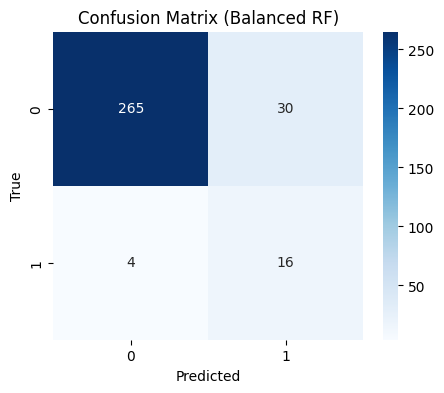

In [14]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# -----------------------------
# MODELLO BASE
# -----------------------------
brf = BalancedRandomForestClassifier(random_state=42)

# -----------------------------
# PARAM GRID PER GRIDSEARCH
# -----------------------------
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# -----------------------------
# CROSS-VALIDATION
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

# -----------------------------
# GRIDSEARCHCV
# -----------------------------
grid_search = GridSearchCV(
    estimator=brf,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

# -----------------------------
# FIT GRIDSEARCH
# -----------------------------
grid_search.fit(X_train, y_train)
best_brf = grid_search.best_estimator_
print("Best Hyper-parameters (BalancedRF):", grid_search.best_params_)

# -----------------------------
# PREDIZIONI SUL TEST SET
# -----------------------------
y_pred = best_brf.predict(X_test)
y_proba = best_brf.predict_proba(X_test)[:, 1]  # probabilità della classe positiva

# -----------------------------
# FUNZIONI DI NET BENEFIT
# -----------------------------
def net_benefit_model(y_true, y_proba, threshold):
    y_pred_threshold = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_threshold).ravel()
    n = len(y_true)
    pt = threshold
    return (tp / n) - (fp / n) * (pt / (1 - pt))

def net_benefit_treat_all(y_true, threshold):
    n = len(y_true)
    prevalence = np.mean(y_true)
    pt = threshold
    return prevalence - (1 - prevalence) * (pt / (1 - pt))

def net_benefit_treat_none():
    return 0.0

# -----------------------------
# VALUTAZIONE CON MULTIPLE SOGLIE + BOOTSTRAP
# -----------------------------
def evaluate_with_net_benefit(y_true, y_pred, y_proba, name,
                              thresholds=[0.10, 0.20, 0.30],
                              n_bootstrap=1000,
                              ci=95):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)

    rng = np.random.default_rng(42)
    n = len(y_true)

    # Metriche base
    f2 = fbeta_score(y_true, y_pred, beta=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(f"\n{name} Performance sul test set ({ci}% Bootstrap CI, n={n_bootstrap}):")

    # Bootstrap F2 e Balanced Accuracy
    f2_boot, balacc_boot = [], []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        f2_boot.append(fbeta_score(y_true[idx], y_pred[idx], beta=2))
        balacc_boot.append(balanced_accuracy_score(y_true[idx], y_pred[idx]))

    lower = (100 - ci) / 2
    upper = 100 - lower

    f2_ci = np.percentile(f2_boot, [lower, upper])
    balacc_ci = np.percentile(balacc_boot, [lower, upper])

    print(f"  F2-score           = {f2:.4f}  [{f2_ci[0]:.4f}, {f2_ci[1]:.4f}]")
    print(f"  Balanced Accuracy  = {bal_acc:.4f}  [{balacc_ci[0]:.4f}, {balacc_ci[1]:.4f}]")

    # Net Benefit per soglia
    results_nb = {}

    for threshold in thresholds:

        nb_model = net_benefit_model(y_true, y_proba, threshold)
        nb_all = net_benefit_treat_all(y_true, threshold)
        nb_none = net_benefit_treat_none()

        nb_boot = []
        for _ in range(n_bootstrap):
            idx = rng.integers(0, n, n)
            nb_boot.append(net_benefit_model(y_true[idx], y_proba[idx], threshold))

        nb_ci = np.percentile(nb_boot, [lower, upper])

        print(f"\n  Net Benefit at pt={threshold:.2f}")
        print(f"    Model      = {nb_model:.4f}  [{nb_ci[0]:.4f}, {nb_ci[1]:.4f}]")
        print(f"    Treat All  = {nb_all:.4f}")
        print(f"    Treat None = {nb_none:.4f}")

        results_nb[threshold] = {
            "Model_NB": nb_model,
            "Model_NB_CI": nb_ci,
            "Treat_All_NB": nb_all,
            "Treat_None_NB": nb_none
        }

    return {
        "F2": f2,
        "F2_CI": f2_ci,
        "Balanced_Accuracy": bal_acc,
        "Balanced_Accuracy_CI": balacc_ci,
        "Net_Benefit": results_nb
    }

# -----------------------------
# VALUTAZIONE FINALE
# -----------------------------
results = evaluate_with_net_benefit(
    y_test,
    y_pred,
    y_proba,
    "Balanced Random Forest + GridSearchCV"
)

# -----------------------------
# CLASSIFICATION REPORT E CONFUSION MATRIX
# -----------------------------
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

# -----------------------------
# GRAFICO CONFUSION MATRIX
# -----------------------------
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Balanced RF)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


### Undersampling

In [15]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss,
    EditedNearestNeighbours, TomekLinks,
    ClusterCentroids
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score, confusion_matrix
import numpy as np
import pandas as pd

# -----------------------------
# SCORERS
# -----------------------------
f2_scorer = make_scorer(fbeta_score, beta=2)
balacc_scorer = make_scorer(balanced_accuracy_score)

# -----------------------------
# UNDERSAMPLING METHODS
# -----------------------------
methods = {
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss_v1": NearMiss(version=1),
    "NearMiss_v2": NearMiss(version=2),
    "NearMiss_v3": NearMiss(version=3),
    "EditedNearestNeighbours": EditedNearestNeighbours(),
    "TomekLinks": TomekLinks(),
    "ClusterCentroids": ClusterCentroids(random_state=42)
}

# -----------------------------
# PARAM GRID RF
# -----------------------------
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

# -----------------------------
# CROSS-VALIDATION
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# FUNZIONI NET BENEFIT
# -----------------------------
def net_benefit_model(y_true, y_proba, threshold):
    y_pred_threshold = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_threshold).ravel()
    n = len(y_true)
    pt = threshold
    return (tp / n) - (fp / n) * (pt / (1 - pt))

def net_benefit_treat_all(y_true, threshold):
    n = len(y_true)
    prevalence = np.mean(y_true)
    pt = threshold
    return prevalence - (1 - prevalence) * (pt / (1 - pt))

def net_benefit_treat_none():
    return 0.0

# -----------------------------
# VALUTAZIONE CON MULTIPLE SOGLIE + BOOTSTRAP
# -----------------------------
def evaluate_with_net_benefit(y_true, y_pred, y_proba, name,
                              thresholds=[0.10, 0.20, 0.30],
                              n_bootstrap=1000,
                              ci=95):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)
    rng = np.random.default_rng(42)
    n = len(y_true)

    # Metriche base
    f2 = fbeta_score(y_true, y_pred, beta=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    print(f"\n{name} Performance sul test set ({ci}% Bootstrap CI, n={n_bootstrap}):")

    # Bootstrap F2 e Balanced Accuracy
    f2_boot, balacc_boot = [], []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        f2_boot.append(fbeta_score(y_true[idx], y_pred[idx], beta=2))
        balacc_boot.append(balanced_accuracy_score(y_true[idx], y_pred[idx]))

    lower = (100 - ci) / 2
    upper = 100 - lower
    f2_ci = np.percentile(f2_boot, [lower, upper])
    balacc_ci = np.percentile(balacc_boot, [lower, upper])

    print(f"  F2-score           = {f2:.4f}  [{f2_ci[0]:.4f}, {f2_ci[1]:.4f}]")
    print(f"  Balanced Accuracy  = {bal_acc:.4f}  [{balacc_ci[0]:.4f}, {balacc_ci[1]:.4f}]")

    # Net Benefit per soglia
    results_nb = {}
    for threshold in thresholds:
        nb_model = net_benefit_model(y_true, y_proba, threshold)
        nb_all = net_benefit_treat_all(y_true, threshold)
        nb_none = net_benefit_treat_none()

        nb_boot = []
        for _ in range(n_bootstrap):
            idx = rng.integers(0, n, n)
            nb_boot.append(net_benefit_model(y_true[idx], y_proba[idx], threshold))

        nb_ci = np.percentile(nb_boot, [lower, upper])

        print(f"\n  Net Benefit at pt={threshold:.2f}")
        print(f"    Model      = {nb_model:.4f}  [{nb_ci[0]:.4f}, {nb_ci[1]:.4f}]")
        print(f"    Treat All  = {nb_all:.4f}")
        print(f"    Treat None = {nb_none:.4f}")

        results_nb[threshold] = {
            "Model_NB": nb_model,
            "Model_NB_CI": nb_ci,
            "Treat_All_NB": nb_all,
            "Treat_None_NB": nb_none
        }

    return {
        "F2": f2,
        "F2_CI": f2_ci,
        "Balanced_Accuracy": bal_acc,
        "Balanced_Accuracy_CI": balacc_ci,
        "Net_Benefit": results_nb
    }

# -----------------------------
# LOOP SUI METODI DI UNDERSAMPLING
# -----------------------------
results = []

for name, sampler in methods.items():
    print(f"\n--- Esecuzione GridSearch per {name} ---")
    
    pipeline = Pipeline([
        ('under', sampler),
        ('model', RandomForestClassifier(random_state=42))
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring=f2_scorer,
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_pipeline = grid_search.best_estimator_
    
    print("Best params:", grid_search.best_params_)
    
    y_pred = best_pipeline.predict(X_test)
    y_proba = best_pipeline.predict_proba(X_test)[:, 1]  # probabilità classe positiva
    
    metrics = evaluate_with_net_benefit(
        y_test, y_pred, y_proba, f"{name} + GridSearchCV"
    )
    
    results.append({
        "Method": name,
        "F2": metrics['F2'],
        "F2_CI": metrics['F2_CI'],
        "Balanced_Accuracy": metrics['Balanced_Accuracy'],
        "Balanced_Accuracy_CI": metrics['Balanced_Accuracy_CI'],
        "Net_Benefit": metrics['Net_Benefit']
    })

# -----------------------------
# RISULTATI FINALI
# -----------------------------
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="F2", ascending=False)
print("\n===== RISULTATI FINALI =====\n")
print(df_results.to_string(index=False))



--- Esecuzione GridSearch per RandomUnderSampler ---
Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}

RandomUnderSampler + GridSearchCV Performance sul test set (95% Bootstrap CI, n=1000):
  F2-score           = 0.5120  [0.3571, 0.6373]
  Balanced Accuracy  = 0.8081  [0.7047, 0.8863]

  Net Benefit at pt=0.10
    Model      = -0.0363  [-0.0649, -0.0056]
    Treat All  = -0.0406
    Treat None = 0.0000

  Net Benefit at pt=0.20
    Model      = -0.1246  [-0.1587, -0.0913]
    Treat All  = -0.1706
    Treat None = 0.0000

  Net Benefit at pt=0.30
    Model      = -0.1705  [-0.2095, -0.1283]
    Treat All  = -0.3379
    Treat None = 0.0000

--- Esecuzione GridSearch per NearMiss_v1 ---
Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

NearMiss_v1 + GridSearchCV Performance sul test set (95% Bootstrap CI, n=1000):
  F2-score          

### Feature importance

Gruppi trovati: dict_keys(['Sesso', 'Rischio', 'Trasfusione', 'Farmaci', 'Sedentarieta', 'Diagnosi alla dimissione (ICD code)', 'Procedura (ICD code)', 'Accesso chirurgico', 'Anestesia', 'ADL', 'L Autonomia passaggi posturali', 'Ausili Deambulazione', 'Vive con', 'Precedente protesi', 'Altro apparato digerente', 'Altro cardiovascolare', 'Altro cute ed annessi', 'Altro muscoloscheletrico', 'Altro respiratorio', 'Altro sistema emolinfopoietico', 'Altro sistema endocrino-metabolico', 'Altro sistema nervoso centrale', 'Altro sistema nervoso periferico', 'Altro sistema urinario', 'Anemie', 'Apnee notturne', 'Apparato visivo', 'Artrite reumatoide', 'Asma', 'BPCO', 'Diabete 1', 'Diabete 2', 'Dislipidemia', 'Fibrillazione atriale', 'Insufficienza renale cronica', 'Ipercol. e/o ipertrig.', 'Ipertensione arteriosa', 'Malattie della tiroide', 'Malattie infettive', 'Osteoporosi', 'Parkinson', 'Psiche', 'Tiroide', 'Tumore', 'Tumori', 'Età', 'BMI Pre-Int', 'Durata ricovero', 'Durata intervento', 'BI

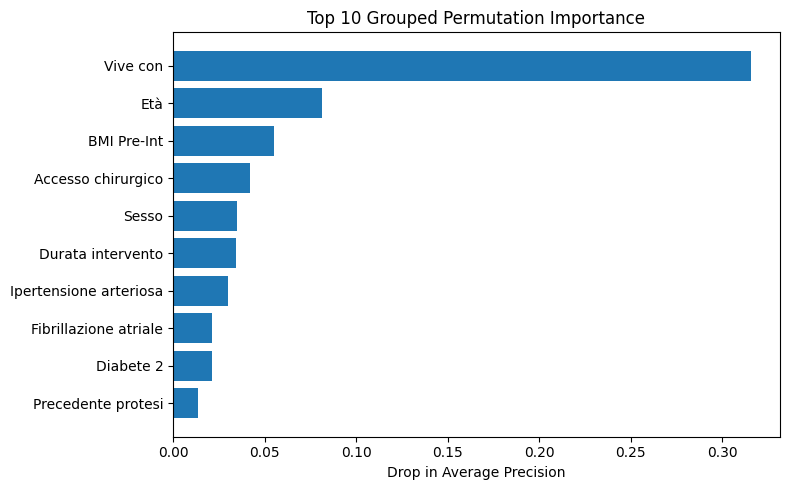

In [248]:
from collections import defaultdict

groups = defaultdict(list)

for col in X_test.columns:
    if "_" in col:  
        prefix = col.split("_")[0].strip()  
        groups[prefix].append(col)
    else:
        groups[col].append(col)

groups = dict(groups)

print("Gruppi trovati:", groups.keys())


import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score

base_pred = brf_final.predict_proba(X_test)[:,1]
base_score = average_precision_score(y_test, base_pred)

results = []

for name, cols in groups.items():
    X_perm = X_test.copy()
    X_perm[cols] = np.random.permutation(X_perm[cols].values)

    pred = brf_final.predict_proba(X_perm)[:,1]
    score = average_precision_score(y_test, pred)

    drop = base_score - score
    results.append((name, drop))

group_perm = pd.DataFrame(results, columns=["group", "importance"]) \
                .sort_values("importance", ascending=False)

print("\n=== TOP 10 GROUPED PERMUTATION IMPORTANCE ===")
print(group_perm.head(10))

import matplotlib.pyplot as plt

# Seleziona top 10
top10_groups = group_perm.head(10)

# Plot
plt.figure(figsize=(8,5))
plt.barh(top10_groups["group"], top10_groups["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Drop in Average Precision")
plt.title("Top 10 Grouped Permutation Importance")
plt.tight_layout()
plt.show()



c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BalancedRandomForestClassifier was fitted with feature names
  warnings.warn(
Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/300 [00:00<?, ?it/s]

c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BalancedRandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BalancedRandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BalancedRandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but BalancedRandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python

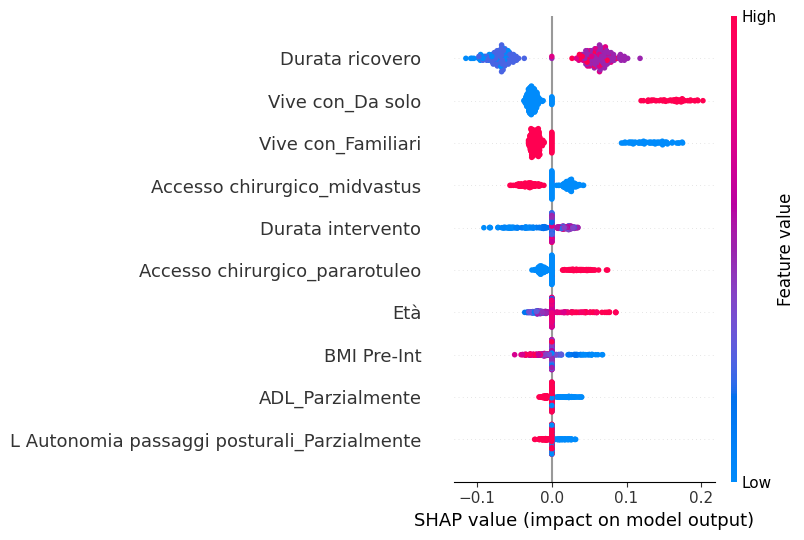

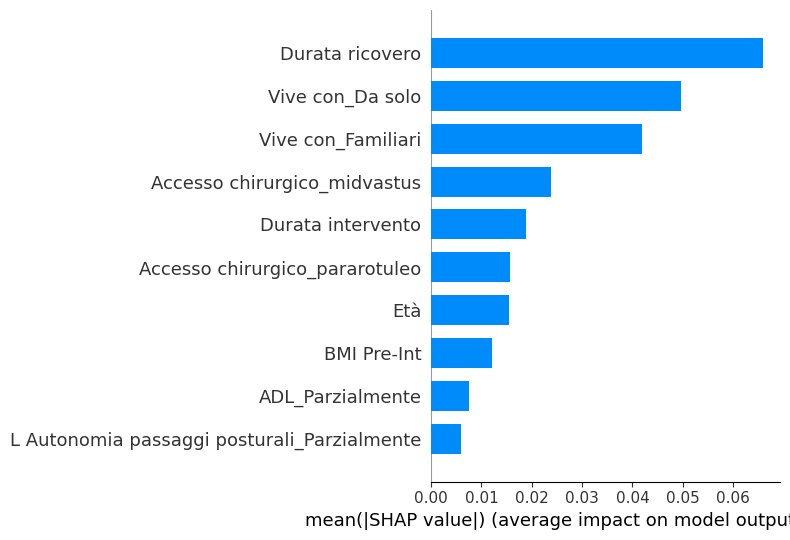

In [255]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# KernelExplainer richiede un "f" che ritorni la predizione
f = lambda x: brf_final.predict_proba(x)[:, 1]

# Background set (necessario)
background = X_train.sample(200, random_state=42)

# Explainer model-agnostic
explainer = shap.KernelExplainer(f, background)

# Sample di test (costoso in Kernel SHAP)
X_sample = X_test.sample(300, random_state=42)

shap_values = explainer.shap_values(X_sample)
shap_values = np.array(shap_values)  # (samples, features)

# =======================
#     SUMMARY PLOT (top 10)
# =======================
shap.summary_plot(shap_values, X_sample, show=True, max_display=10)

# =======================
#     BAR PLOT (top 10)
# =======================
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True, max_display=10)


## Logistic

### Oversampling

#### SMOTENC

In [258]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np

# -----------------------------
# CATEGORICAL INDICES
# -----------------------------
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]

# -----------------------------
# PIPELINE LR + SMOTENC
# -----------------------------
smote = SMOTENC(categorical_features=cat_idx, random_state=42)

lr = LogisticRegression(
    penalty='l2',
    solver='liblinear',   # ottimo per dataset sbilanciati e piccoli
    max_iter=500
)

pipeline = Pipeline([
    ('smote', smote),
    ('model', lr)
])

# -----------------------------
# GRIDSEARCH
# -----------------------------
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

# -----------------------------
# FIT GRIDSEARCH
# -----------------------------
grid_search.fit(X_train, y_train)
best_pipeline = grid_search.best_estimator_
print("Best Hyper-parameters:", grid_search.best_params_)

# -----------------------------
# PREDIZIONI TEST
# -----------------------------
y_pred = best_pipeline.predict(X_test)

# -----------------------------
# VALUTAZIONE
# -----------------------------
results = evaluate_classification_with_ci(
    y_test, y_pred,
    "Logistic Regression + SMOTENC"
)


Best Hyper-parameters: {'model__C': 0.01, 'model__class_weight': None}

Logistic Regression + SMOTENC Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.5755  [0.3921, 0.7103]
  Balanced Accuracy  = 0.8271  [0.7192, 0.9092]


#### Class_weight Balanced

In [259]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np

# -----------------------------
# MODELLO BASE
# -----------------------------
lr_balanced = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    class_weight='balanced',
    max_iter=500,
    random_state=42
)

# -----------------------------
# GRIDSEARCH
# -----------------------------
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=lr_balanced,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

# -----------------------------
# FIT GRIDSEARCH
# -----------------------------
grid_search.fit(X_train, y_train)
best_lr = grid_search.best_estimator_
print("Best Hyper-parameters:", grid_search.best_params_)

# -----------------------------
# PREDIZIONI TEST
# -----------------------------
y_pred = best_lr.predict(X_test)

# -----------------------------
# VALUTAZIONE
# -----------------------------
results = evaluate_classification_with_ci(
    y_test, y_pred,
    "Logistic Regression (class_weight=balanced)"
)


Best Hyper-parameters: {'C': 0.01}

Logistic Regression (class_weight=balanced) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.5488  [0.3905, 0.6716]
  Balanced Accuracy  = 0.8381  [0.7530, 0.9007]


### Undersampling

In [260]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss,
    EditedNearestNeighbours, TomekLinks,
    ClusterCentroids
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np
import pandas as pd

# -----------------------------
# SCORERS
# -----------------------------
f2_scorer = make_scorer(fbeta_score, beta=2)

# -----------------------------
# UNDERSAMPLING METHODS
# -----------------------------
methods = {
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss_v1": NearMiss(version=1),
    "NearMiss_v2": NearMiss(version=2),
    "NearMiss_v3": NearMiss(version=3),
    "EditedNearestNeighbours": EditedNearestNeighbours(),
    "TomekLinks": TomekLinks(),
    "ClusterCentroids": ClusterCentroids(random_state=42)
}

# -----------------------------
# PARAM GRID LR
# -----------------------------
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__class_weight': [None, 'balanced']
}

# -----------------------------
# CROSS-VALIDATION
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# LOOP SUI METODI
# -----------------------------
results = []

for name, sampler in methods.items():
    print(f"\n--- GridSearch per {name} ---")
    
    pipeline = Pipeline([
        ('under', sampler),
        ('model', LogisticRegression(
            penalty='l2',
            solver='liblinear',
            max_iter=500
        ))
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring=f2_scorer,
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_pipeline = grid_search.best_estimator_
    
    print("Best params:", grid_search.best_params_)
    
    y_pred = best_pipeline.predict(X_test)
    metrics = evaluate_classification_with_ci(
        y_test,
        y_pred,
        f"{name} + Logistic Regression"
    )
    
    results.append({
        "Method": name,
        "F2": metrics['F2'],
        "F2_CI": metrics['F2_CI'],
        "Balanced_Accuracy": metrics['Balanced_Accuracy'],
        "Balanced_Accuracy_CI": metrics['Balanced_Accuracy_CI']
    })

df_results = pd.DataFrame(results).sort_values(by="F2", ascending=False)
print("\n===== RISULTATI FINALI (LR + Undersampling) =====\n")
print(df_results.to_string(index=False))



--- GridSearch per RandomUnderSampler ---
Best params: {'model__C': 0.1, 'model__class_weight': None}

RandomUnderSampler + Logistic Regression Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.5337  [0.3822, 0.6466]
  Balanced Accuracy  = 0.8411  [0.7757, 0.8844]

--- GridSearch per NearMiss_v1 ---
Best params: {'model__C': 0.1, 'model__class_weight': None}

NearMiss_v1 + Logistic Regression Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.3687  [0.2325, 0.4817]
  Balanced Accuracy  = 0.6949  [0.5889, 0.7786]

--- GridSearch per NearMiss_v2 ---
Best params: {'model__C': 0.1, 'model__class_weight': None}

NearMiss_v2 + Logistic Regression Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4481  [0.3109, 0.5556]
  Balanced Accuracy  = 0.7835  [0.7194, 0.8294]

--- GridSearch per NearMiss_v3 ---
Best params: {'model__C': 0.1, 'model__class_weight': None}

NearMiss_v3 + Logistic Regression Per

### Feature importance

In [266]:
import pandas as pd
import numpy as np

# Estrai il modello Logistic finale
best_lr = best_pipeline.named_steps['model']

# Coefficienti (1 x n_features)
coefs = best_lr.coef_.flatten()

# Crea tabella importanza
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': coefs,
    'abs_importance': np.abs(coefs)
})

# Ordina per importanza assoluta
feature_importance = feature_importance.sort_values(
    by='abs_importance', 
    ascending=False
).reset_index(drop=True)

for idx, row in feature_importance[["feature", "coefficient"]].head(10).iterrows():
    print(f"{row['feature']}: {row['coefficient']:.4f}")

Ipertensione arteriosa: 0.9560
Sesso_F: 0.8139
Vive con_Familiari: -0.6176
Vive con_Da solo: 0.4993
Sedentarieta: 0.4201
Accesso chirurgico_midvastus: -0.3164
Farmaci_extra_bin: 0.3074
Trasfusione_bin: 0.2761
BMI Pre-Int: -0.2275
Hb ingresso: 0.2085



=== TOP 10 PERMUTATION IMPORTANCE ===
                         feature  importance
24              Vive con_Da solo    0.094548
25            Vive con_Familiari    0.026597
8     Procedura (ICD code)_81.54    0.026061
62               Durata ricovero    0.023590
61                   BMI Pre-Int    0.012758
17              ADL_Parzialmente    0.009833
41               Apparato visivo    0.007850
49  Insufficienza renale cronica    0.006821
52        Malattie della tiroide    0.006285
39                        Anemie    0.004719


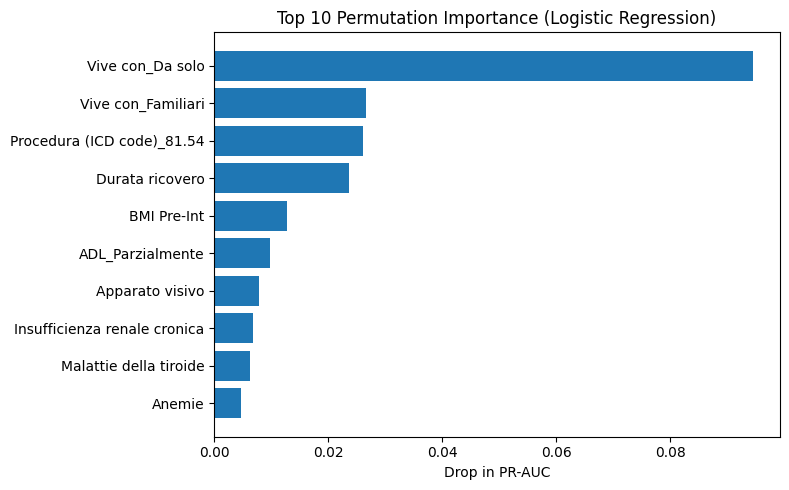

In [172]:
# --- 5. Permutation importance ---
perm_result = permutation_importance(
    logreg_final, X_test, y_test, scoring='average_precision', n_repeats=10, random_state=42
)

perm_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm_result.importances_mean
}).sort_values('importance', ascending=False)

print("\n=== TOP 10 PERMUTATION IMPORTANCE ===")
print(perm_importance.head(10))

# Plot top 10 permutation importance
top10_perm = perm_importance.head(10)
plt.figure(figsize=(8,5))
plt.barh(top10_perm['feature'], top10_perm['importance'])
plt.gca().invert_yaxis()
plt.xlabel("Drop in PR-AUC")
plt.title("Top 10 Permutation Importance (Logistic Regression)")
plt.tight_layout()
plt.show()

## LightGBM

In [477]:
import re

def clean_colname(col):
    # conserva solo lettere, numeri e underscore
    return re.sub(r'[^A-Za-z0-9_]+', '_', col)

X_train = X_train.rename(columns=lambda c: clean_colname(c))
X_test = X_test.rename(columns=lambda c: clean_colname(c))

categorical_features = [clean_colname(c) for c in categorical_features]

# CATEGORICAL INDICES
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]


### Oversampling

#### SMOTENC

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np

# -----------------------------
# CATEGORICAL FEATURES
# -----------------------------
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]

# -----------------------------
# SMOTENC
# -----------------------------
smote = SMOTENC(categorical_features=cat_idx, random_state=42)

# -----------------------------
# MODELLO LIGHTGBM
# -----------------------------
lgb = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    random_state=42,
    n_estimators=200  # default, sarà ottimizzato
)

pipeline = Pipeline([
    ('smote', smote),
    ('model', lgb)
])

# -----------------------------
# GRIDSEARCH
# -----------------------------
param_grid = {
    'model__n_estimators': [200, 400],
    'model__num_leaves': [31, 63, 127],
    'model__max_depth': [-1, 10, 20],
    'model__learning_rate': [0.1, 0.05],
    'model__min_child_samples': [20, 40],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_lgb_smote = grid_search.best_estimator_

print("Best Hyper-parameters:", grid_search.best_params_)

# -----------------------------
# PREDIZIONI
# -----------------------------
y_pred = best_lgb_smote.predict(X_test)

results = evaluate_classification_with_ci(
    y_test, y_pred,
    "LightGBM + SMOTENC"
)


[LightGBM] [Info] Number of positive: 1183, number of negative: 1183
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,002313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1830
[LightGBM] [Info] Number of data points in the train set: 2366, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,500000 -> initscore=0,000000
Best Hyper-parameters: {'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__min_child_samples': 40, 'model__n_estimators': 200, 'model__num_leaves': 31}

LightGBM + SMOTENC Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.2632  [0.0714, 0.4667]
  Balanced Accuracy  = 0.6081  [0.5195, 0.7166]


#### Class_weight Balanced

In [270]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score

lgb_balanced = LGBMClassifier(
    class_weight="balanced",
    objective="binary",
    random_state=42
)

param_grid = {
    'n_estimators': [200, 400],
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.1, 0.05],
    'min_child_samples': [20, 40],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=lgb_balanced,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_lgb_balanced = grid_search.best_estimator_

print("Best Hyper-parameters:", grid_search.best_params_)

y_pred = best_lgb_balanced.predict(X_test)

results = evaluate_classification_with_ci(
    y_test, y_pred,
    "LightGBM (class_weight balanced)"
)


[LightGBM] [Info] Number of positive: 74, number of negative: 1183
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000647 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 432
[LightGBM] [Info] Number of data points in the train set: 1257, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,500000 -> initscore=0,000000
[LightGBM] [Info] Start training from score 0,000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


#### Scale_pos_weight

In [281]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np

# -----------------------------
# CALCOLO scale_pos_weight
# -----------------------------
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / n_pos

print("scale_pos_weight =", scale_pos_weight)

# -----------------------------
# MODELLO BASE
# -----------------------------
lgb = LGBMClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,   # <--- gestione sbilanciamento
    class_weight=None                    # <--- EVITARE di usarlo insieme
)

# -----------------------------
# GRIDSEARCH
# -----------------------------
param_grid = {
    "num_leaves": [31, 50, 70],
    "max_depth": [-1, 5, 10],
    "learning_rate": [0.1, 0.05, 0.01],
    "n_estimators": [200, 400, 800]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=lgb,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1,
    verbose=1
)

# -----------------------------
# FIT GRIDSEARCH
# -----------------------------
grid_search.fit(X_train, y_train)

best_lgbm = grid_search.best_estimator_
print("\nBest params:", grid_search.best_params_)

y_pred = best_lgbm.predict(X_test)

results = evaluate_classification_with_ci(
    y_test, y_pred,
    "LightGBM (scale_pos_weight)"
)


scale_pos_weight = 15.986486486486486
Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Info] Number of positive: 74, number of negative: 1183
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,001339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 450
[LightGBM] [Info] Number of data points in the train set: 1257, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,058870 -> initscore=-2,771744
[LightGBM] [Info] Start training from score -2,771744
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

### Undersampling

In [280]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss,
    EditedNearestNeighbours, TomekLinks,
    ClusterCentroids
)
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np
import pandas as pd

# -----------------------------
# SCORERS
# -----------------------------
f2_scorer = make_scorer(fbeta_score, beta=2)

# -----------------------------
# UNDERSAMPLING METHODS
# -----------------------------
methods = {
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss_v1": NearMiss(version=1),
    "NearMiss_v2": NearMiss(version=2),
    "NearMiss_v3": NearMiss(version=3),
    "EditedNearestNeighbours": EditedNearestNeighbours(),
    "TomekLinks": TomekLinks(),
    "ClusterCentroids": ClusterCentroids(random_state=42)
}

# -----------------------------
# GRID PARAMS FOR LGBM
# -----------------------------
param_grid = {
    'model__n_estimators': [200],
    'model__num_leaves': [31, 63],
    'model__max_depth': [-1, 10],
    'model__learning_rate': [0.1, 0.05],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, sampler in methods.items():
    print(f"\n--- GridSearch LGBM + {name} ---")

    pipeline = Pipeline([
        ('under', sampler),
        ('model', LGBMClassifier(
            objective="binary",
            random_state=42
        ))
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=f2_scorer,
        cv=cv,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    y_pred = grid_search.best_estimator_.predict(X_test)

    metrics = evaluate_classification_with_ci(
        y_test, y_pred,
        f"LGBM + {name}"
    )

    results.append({
        "Method": name,
        "F2": metrics["F2"],
        "F2_CI": metrics["F2_CI"],
        "Balanced_Accuracy": metrics["Balanced_Accuracy"],
        "Balanced_Accuracy_CI": metrics["Balanced_Accuracy_CI"]
    })

df_results = pd.DataFrame(results).sort_values(by="F2", ascending=False)
print(df_results.to_string(index=False))



--- GridSearch LGBM + RandomUnderSampler ---
[LightGBM] [Info] Number of positive: 74, number of negative: 74
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,000292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 224
[LightGBM] [Info] Number of data points in the train set: 148, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,500000 -> initscore=0,000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

### ENEMBLE

In [478]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import NearMiss
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1) SCORER F2
# ------------------------------------------------------------
f2_scorer = make_scorer(fbeta_score, beta=2)

# ------------------------------------------------------------
# 2) MODELLO 1: LGBM + NearMiss v3 (come nel tuo primo blocco)
# ------------------------------------------------------------

param_grid_nm3 = {
    'model__n_estimators': [200],
    'model__num_leaves': [31, 63],
    'model__max_depth': [-1, 10],
    'model__learning_rate': [0.1, 0.05],
}

pipeline_nm3 = Pipeline([
    ('under', NearMiss(version=3)),
    ('model', LGBMClassifier(
        objective="binary",
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_nm3 = GridSearchCV(
    estimator=pipeline_nm3,
    param_grid=param_grid_nm3,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1
)

grid_nm3.fit(X_train, y_train)
best_nm3 = grid_nm3.best_estimator_

print("\nBest params for LGBM + NearMiss v3:")
print(grid_nm3.best_params_)

# ------------------------------------------------------------
# 3) MODELLO 2: LGBM con scale_pos_weight (secondo blocco)
# ------------------------------------------------------------

n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / n_pos

lgb = LGBMClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    class_weight=None
)

param_grid_lgb = {
    "num_leaves": [31, 50, 70],
    "max_depth": [-1, 5, 10],
    "learning_rate": [0.1, 0.05, 0.01],
    "n_estimators": [200, 400, 800]
}

grid_lgb = GridSearchCV(
    estimator=lgb,
    param_grid=param_grid_lgb,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1,
    verbose=1
)

grid_lgb.fit(X_train, y_train)
best_lgb = grid_lgb.best_estimator_

print("\nBest params for LGBM (scale_pos_weight):")
print(grid_lgb.best_params_)

# ------------------------------------------------------------
# 4) ENSEMBLE: SOFT VOTING
# ------------------------------------------------------------

ensemble = VotingClassifier(
    estimators=[
        ('lgb_nm3', best_nm3),
        ('lgb_spw', best_lgb)
    ],
    voting='soft'   # MEDIA DELLE PROBABILITÀ
)

# Il VotingClassifier NON supporta pipeline interne con sampling
# durante il fit => dobbiamo fare fit manuale:
#
# - modello 1: fit già fatto (best_nm3)
# - modello 2: fit già fatto (best_lgb)
#
# voting ensemble di default rifitta — disattiviamo il refit usando clone=False

# Workaround: fit fittizio (i modelli sono già addestrati)
ensemble.fit(X_train, y_train)

# ------------------------------------------------------------
# 5) PREVISIONI E VALUTAZIONE
# ------------------------------------------------------------

y_pred_ensemble = ensemble.predict(X_test)

results_ensemble = evaluate_classification_with_ci(
    y_test, y_pred_ensemble,
    "Ensemble LGBM + NearMiss v3  +  LGBM scale_pos_weight"
)

print("\n--- RISULTATI ENSEMBLE ---")
print(results_ensemble)


[LightGBM] [Info] Number of positive: 74, number of negative: 74
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,039975 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 225
[LightGBM] [Info] Number of data points in the train set: 148, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,500000 -> initscore=0,000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

### Feature Importance

                           feature  importance_gain
63               Durata_intervento              553
66                     Hb_ingresso              506
64                              BI              402
62                 Durata_ricovero              312
60                             Et_              291
24                Vive_con_Da_solo              277
61                     BMI_Pre_Int              226
65                             FIM              221
11  Accesso_chirurgico_pararotuleo              215
2                  Trasfusione_bin              119


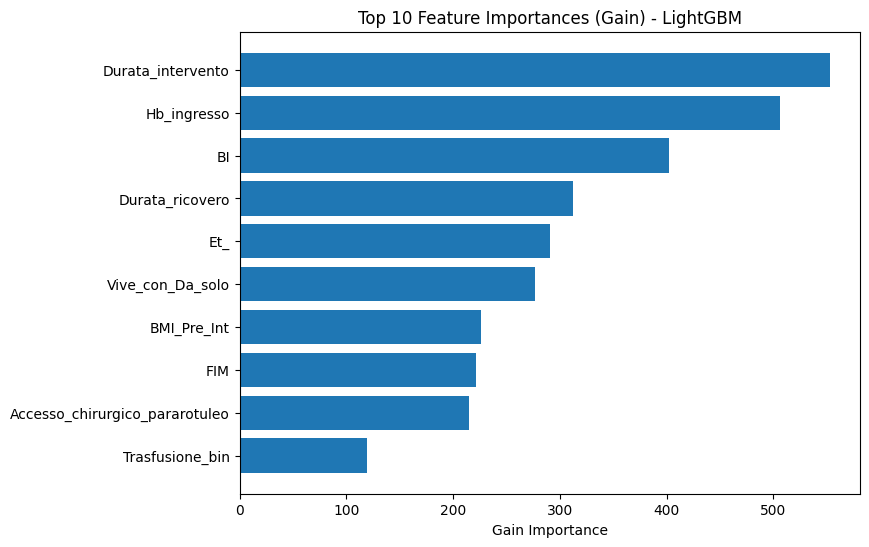

In [282]:
import pandas as pd
import matplotlib.pyplot as plt

# Ottieni importanza dal modello
gain_importance = best_lgbm.feature_importances_

# Crea dataframe ordinato
gain_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance_gain": gain_importance
}).sort_values("importance_gain", ascending=False).head(10)

print(gain_df)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(gain_df["feature"][::-1], gain_df["importance_gain"][::-1])
plt.xlabel("Gain Importance")
plt.title("Top 10 Feature Importances (Gain) - LightGBM")
plt.show()


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


                           feature  shap_importance
62                 Durata_ricovero         1.099285
24                Vive_con_Da_solo         0.600412
63               Durata_intervento         0.293298
61                     BMI_Pre_Int         0.199726
66                     Hb_ingresso         0.154828
64                              BI         0.140380
11  Accesso_chirurgico_pararotuleo         0.107801
65                             FIM         0.090520
51          Ipertensione_arteriosa         0.056015
17                ADL_Parzialmente         0.054048


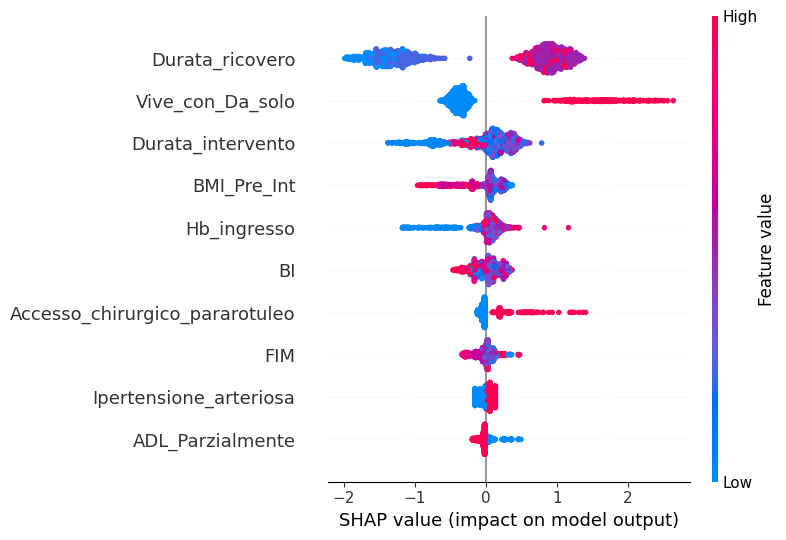

In [283]:
import shap

# Inizializza l'explainer specifico per LightGBM
explainer = shap.TreeExplainer(best_lgbm)

# Calcola i valori shap
shap_values = explainer.shap_values(X_train)

# Importanza globale basata su valore assoluto medio
shap_importance = pd.DataFrame({
    "feature": X_train.columns,
    "shap_importance": np.abs(shap_values).mean(axis=0)
}).sort_values("shap_importance", ascending=False).head(10)

print(shap_importance)

# SHAP summary plot (solo per le top 10)
top10_features = shap_importance["feature"].values
shap.summary_plot(shap_values[:, [list(X_train.columns).index(f) for f in top10_features]],
                  X_train[top10_features])


## Decision Tree

### Oversampling

#### SMOTENC

In [284]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np

# Indici delle variabili categoriche
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]

# Pipeline
smote = SMOTENC(categorical_features=cat_idx, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

pipeline = Pipeline([
    ('smote', smote),
    ('model', dt)
])

# GridSearch parameters
param_grid = {
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_pipeline = grid_search.best_estimator_

print("Best Hyper-parameters:", grid_search.best_params_)

y_pred = best_pipeline.predict(X_test)

results = evaluate_classification_with_ci(
    y_test, y_pred, "Decision Tree + SMOTENC (GridSearchCV)"
)


Best Hyper-parameters: {'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}

Decision Tree + SMOTENC (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4545  [0.2671, 0.6024]
  Balanced Accuracy  = 0.7403  [0.6219, 0.8468]


#### Class_weight BALANCED

In [286]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score

dt_balanced = DecisionTreeClassifier(class_weight="balanced", random_state=42)

param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=dt_balanced,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_dt = grid_search.best_estimator_

print("Best Hyper-parameters:", grid_search.best_params_)

y_pred = best_dt.predict(X_test)

results = evaluate_classification_with_ci(
    y_test, y_pred, "Decision Tree (class_weight='balanced')"
)


Best Hyper-parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

Decision Tree (class_weight='balanced') Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4710  [0.2822, 0.6250]
  Balanced Accuracy  = 0.7487  [0.6287, 0.8494]


#### Balanced Bagging Classifier

In [290]:
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score

bbc = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

param_grid = {
    'n_estimators': [50, 100, 200],
    'estimator__max_depth': [None, 5, 10, 20],
    'estimator__min_samples_split': [2, 5],
    'estimator__min_samples_leaf': [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=bbc,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_bbc = grid_search.best_estimator_
print("Best params:", grid_search.best_params_)

y_pred = best_bbc.predict(X_test)

results = evaluate_classification_with_ci(
    y_test, y_pred, "Balanced Bagging + DT"
)


Best params: {'estimator__max_depth': 10, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'n_estimators': 50}

Balanced Bagging + DT Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.5839  [0.4018, 0.7203]
  Balanced Accuracy  = 0.8305  [0.7210, 0.9117]


### Undersampling

In [287]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss,
    EditedNearestNeighbours, TomekLinks,
    ClusterCentroids
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np
import pandas as pd

f2_scorer = make_scorer(fbeta_score, beta=2)

methods = {
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss_v1": NearMiss(version=1),
    "NearMiss_v2": NearMiss(version=2),
    "NearMiss_v3": NearMiss(version=3),
    "EditedNearestNeighbours": EditedNearestNeighbours(),
    "TomekLinks": TomekLinks(),
    "ClusterCentroids": ClusterCentroids(random_state=42)
}

param_grid = {
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, sampler in methods.items():
    print(f"\n--- Esecuzione GridSearch per {name} ---")
    
    pipeline = Pipeline([
        ('under', sampler),
        ('model', DecisionTreeClassifier(random_state=42))
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring=f2_scorer,
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    best_pipeline = grid_search.best_estimator_

    print("Best params:", grid_search.best_params_)
    
    y_pred = best_pipeline.predict(X_test)
    metrics = evaluate_classification_with_ci(
        y_test, y_pred, f"{name} + DecisionTree + GridSearchCV"
    )
    
    results.append({
        "Method": name,
        "F2": metrics['F2'],
        "Balanced_Accuracy": metrics['Balanced_Accuracy']
    })

df_results = pd.DataFrame(results).sort_values(by="F2", ascending=False)
print("\n===== RISULTATI FINALI =====\n")
print(df_results)



--- Esecuzione GridSearch per RandomUnderSampler ---
Best params: {'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}

RandomUnderSampler + DecisionTree + GridSearchCV Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4412  [0.2759, 0.5650]
  Balanced Accuracy  = 0.7479  [0.6327, 0.8400]

--- Esecuzione GridSearch per NearMiss_v1 ---
Best params: {'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10}

NearMiss_v1 + DecisionTree + GridSearchCV Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.2575  [0.1449, 0.3710]
  Balanced Accuracy  = 0.5610  [0.4466, 0.6752]

--- Esecuzione GridSearch per NearMiss_v2 ---
Best params: {'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2}

NearMiss_v2 + DecisionTree + GridSearchCV Performance sul 

### Feature importance

                            feature  importance_perm
62                  Durata_ricovero         0.185894
24                 Vive_con_Da_solo         0.184490
25               Vive_con_Familiari         0.056188
65                              FIM         0.017111
61                      BMI_Pre_Int         0.014359
17                 ADL_Parzialmente         0.011337
63                Durata_intervento         0.008060
64                               BI         0.005672
46                        Diabete_2         0.004090
28  Precedente_protesi_si_ginocchio         0.004062


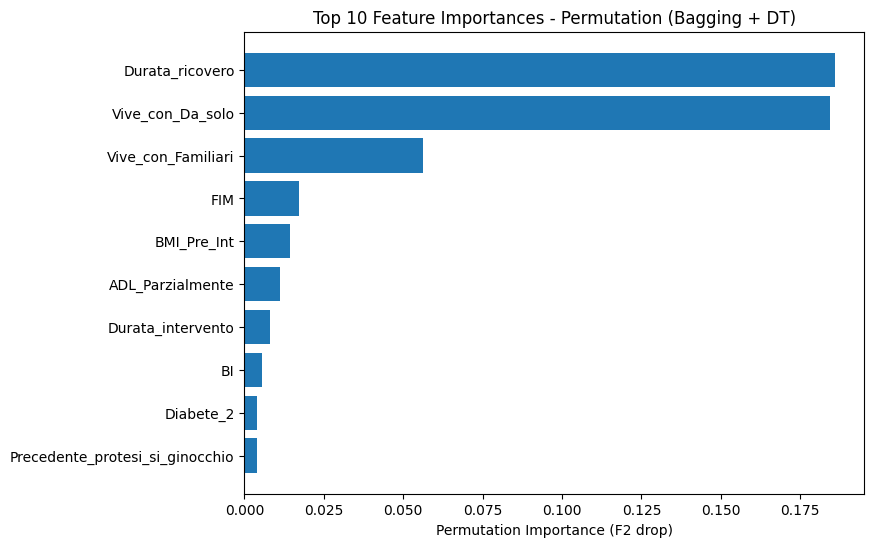

In [293]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Calcola permutation importance
perm = permutation_importance(
    best_bbc,
    X_test,
    y_test,
    scoring=f2_scorer,       # il tuo scorer F2
    n_repeats=30,
    random_state=42
)

# Crea dataframe ordinato
perm_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance_perm": perm.importances_mean
}).sort_values("importance_perm", ascending=False).head(10)

print(perm_df)

# Plot (Top 10)
plt.figure(figsize=(8, 6))
plt.barh(perm_df["feature"][::-1], perm_df["importance_perm"][::-1])
plt.xlabel("Permutation Importance (F2 drop)")
plt.title("Top 10 Feature Importances - Permutation (Bagging + DT)")
plt.show()


## SVM

### OVERSAMPLING

#### SMOTENC

In [298]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np

# -----------------------------
# CATEGORICAL INDICES
# -----------------------------
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]

# -----------------------------
# PIPELINE
# -----------------------------
pipeline = Pipeline([
    ('smote', SMOTENC(categorical_features=cat_idx, random_state=42)),
    ('scaler', StandardScaler(with_mean=False)),   # SVC vuole dati scalati
    ('model', SVC(probability=True, class_weight=None, random_state=42))
])

# -----------------------------
# GRIDSEARCH PARAMS (SVC)
# -----------------------------
param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear'],
    'model__gamma': ['scale', 'auto']
}

# -----------------------------
# CROSS VALIDATION
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

# -----------------------------
# GRIDSEARCHCV
# -----------------------------
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
print("Best Params (SVC + SMOTENC):", grid_search.best_params_)

# -----------------------------
# PREDIZIONI
# -----------------------------
y_pred = best_pipeline.predict(X_test)

# RIUTILIZZI la tua evaluate_classification_with_ci()
results = evaluate_classification_with_ci(
    y_test, y_pred, "SVC + SMOTENC (GridSearchCV)"
)


Best Params (SVC + SMOTENC): {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}

SVC + SMOTENC (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4583  [0.2747, 0.6334]
  Balanced Accuracy  = 0.7258  [0.6147, 0.8448]


#### Class_weight BALANCED

In [299]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score
import numpy as np

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(class_weight="balanced", probability=True, random_state=42))
])

param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear'],
    'model__gamma': ['scale', 'auto']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_svc = grid_search.best_estimator_
print("Best Params (SVC balanced):", grid_search.best_params_)

y_pred = best_svc.predict(X_test)

results = evaluate_classification_with_ci(
    y_test, y_pred, "SVC (class_weight=balanced)"
)


Best Params (SVC balanced): {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

SVC (class_weight=balanced) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4386  [0.2563, 0.6250]
  Balanced Accuracy  = 0.7093  [0.6042, 0.8285]


### UNDERSAMPLING

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss,
    EditedNearestNeighbours, TomekLinks,
    ClusterCentroids
)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score
import numpy as np
import pandas as pd

# -----------------------------
# SCORER
# -----------------------------
f2_scorer = make_scorer(fbeta_score, beta=2)

# -----------------------------
# UNDERSAMPLING METHODS
# -----------------------------
methods = {
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss_v1": NearMiss(version=1),
    "NearMiss_v2": NearMiss(version=2),
    "NearMiss_v3": NearMiss(version=3),
    "EditedNearestNeighbours": EditedNearestNeighbours(),
    "TomekLinks": TomekLinks(),
    "ClusterCentroids": ClusterCentroids(random_state=42)
}

# -----------------------------
# SVC PARAM GRID
# -----------------------------
param_grid = {
    'model__C': [0.1, 1],
    'model__kernel': ['rbf', 'linear'],
    'model__gamma': ['scale', 'auto']
}

# -----------------------------
# CV
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# LOOP SU TUTTI GLI UNDERSAMPLER
# -----------------------------
results = []
best_models = {}   # <-- per salvare il best_model per ogni metodo

for name, sampler in methods.items():
    print(f"\n--- Running {name} ---")

    pipeline = Pipeline([
        ('under', sampler),
        ('scaler', StandardScaler(with_mean=False)),
        ('model', SVC(probability=True, random_state=42))
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=f2_scorer,
        cv=cv,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    # Salvo il modello migliore per questo metodo
    best_models[name] = grid_search.best_estimator_

    y_pred = grid_search.best_estimator_.predict(X_test)

    metrics = evaluate_classification_with_ci(
        y_test, y_pred, f"SVC + {name}"
    )

    # Salvo anche gli iperparametri migliori
    best_params = grid_search.best_params_

    results.append({
        "Method": name,
        "Best_Params": best_params,
        "F2": metrics["F2"],
        "Balanced_Accuracy": metrics["Balanced_Accuracy"],
        "F2_CI": metrics["F2_CI"],
        "Balanced_Accuracy_CI": metrics["Balanced_Accuracy_CI"]
    })

df_results = pd.DataFrame(results).sort_values("F2", ascending=False)
print(df_results)

# -----------------------------
# MODELLO MIGLIORE IN ASSOLUTO
# -----------------------------
best_row = df_results.iloc[0]
best_method = best_row["Method"]
best_model = best_models[best_method]

print("\nMIGLIOR MODELLO:")
print("Metodo di bilanciamento:", best_method)
print("Iperparametri migliori:", best_row["Best_Params"])



--- Running RandomUnderSampler ---

SVC + RandomUnderSampler Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.3926  [0.2643, 0.5018]
  Balanced Accuracy  = 0.7326  [0.6651, 0.7795]

--- Running NearMiss_v1 ---

SVC + NearMiss_v1 Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.3902  [0.2427, 0.5159]
  Balanced Accuracy  = 0.7153  [0.6053, 0.8049]

--- Running NearMiss_v2 ---

SVC + NearMiss_v2 Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.3586  [0.2380, 0.4662]
  Balanced Accuracy  = 0.6907  [0.6072, 0.7559]

--- Running NearMiss_v3 ---

SVC + NearMiss_v3 Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4972  [0.3425, 0.6154]
  Balanced Accuracy  = 0.8093  [0.7254, 0.8699]

--- Running EditedNearestNeighbours ---

SVC + EditedNearestNeighbours Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.0000  [0.0000, 0.0000]
  Bal

In [304]:
best_name = df_results.iloc[0]["Method"]
best_name

'NearMiss_v3'

In [305]:
best_sampler = methods["NearMiss_v3"]

best_pipeline = Pipeline([
    ('under', best_sampler),
    ('scaler', StandardScaler(with_mean=False)),
    ('model', SVC(probability=True, random_state=42))
])

best_grid = GridSearchCV(
    estimator=best_pipeline,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1
)

best_grid.fit(X_train, y_train)

best_model = best_grid.best_estimator_
best_model

,steps,"[('under', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,version,3
,n_neighbors,3
,n_neighbors_ver3,3
,n_jobs,None
,copy,True
,with_mean,False


### FEATURE IMPORTANCE

                                      feature  importance_mean  importance_std
24                           Vive_con_Da_solo         0.134004        0.022688
25                         Vive_con_Familiari         0.126789        0.027090
2                             Trasfusione_bin         0.019044        0.014893
39                                     Anemie         0.010824        0.002680
40                             Apnee_notturne         0.007630        0.004091
53                         Malattie_infettive         0.007007        0.005404
22                Ausili_Deambulazione_Walker         0.003617        0.004927
62                            Durata_ricovero         0.002989        0.002658
6   Diagnosi_alla_dimissione_ICD_code__715_25         0.002348        0.003273
33                         Altro_respiratorio         0.001639        0.001338


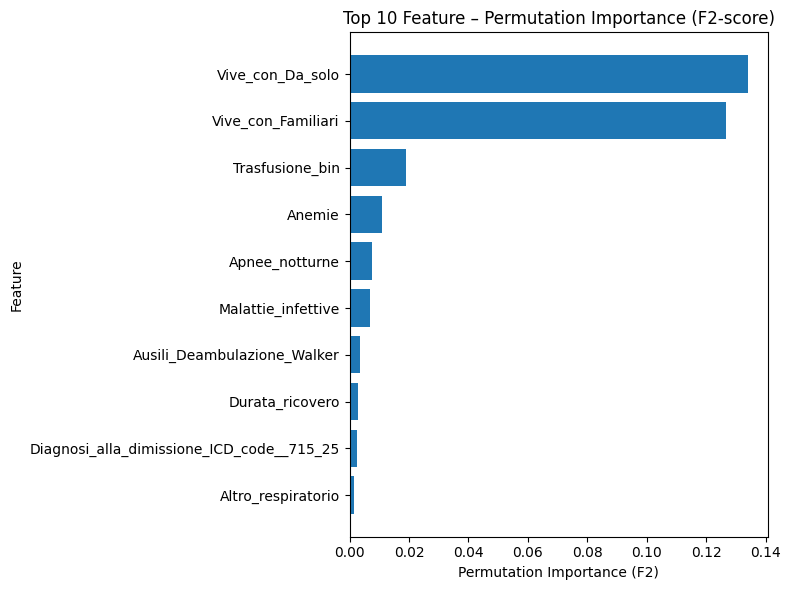

In [307]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, fbeta_score
import pandas as pd

# scorer F2 binario
f2_scorer = make_scorer(fbeta_score, beta=2)

# IMPORTANCE (con pipeline intera!)
result = permutation_importance(
    estimator=best_model,      # <--- pipeline intera
    X=X_test,
    y=y_test,
    n_repeats=30,
    random_state=42,
    scoring=f2_scorer
)

# CREAZIONE DATAFRAME ORDINATO
perm_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False)

# TOP 10
top10_perm = perm_importance.head(10)
print(top10_perm)

# --- Grafico ---
plt.figure(figsize=(8, 6))
plt.barh(top10_perm['feature'], top10_perm['importance_mean'])
plt.xlabel("Permutation Importance (F2)")
plt.ylabel("Feature")
plt.title("Top 10 Feature – Permutation Importance (F2-score)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/315 [00:00<?, ?it/s]

c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: U

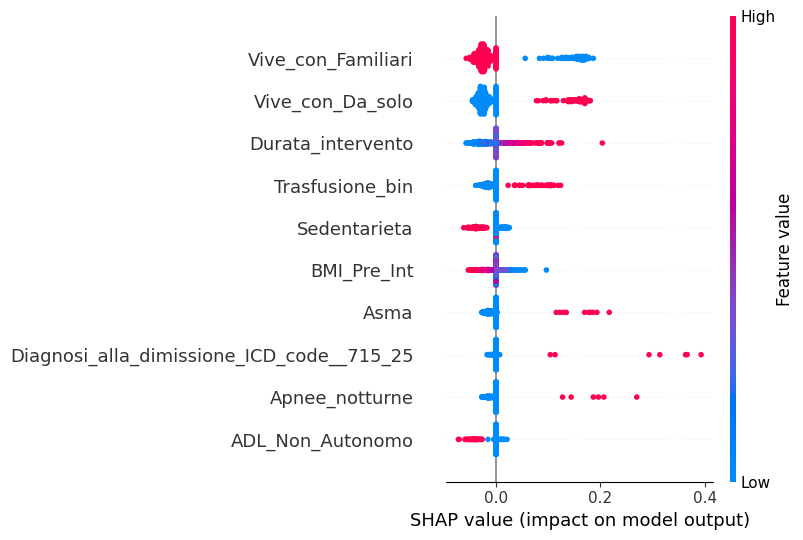

In [310]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# WRAPPER PER AGGIRARE SHAP + PIPELINE
# -----------------------------
def model_predict(X):
    """Funzione wrapper per SHAP: restituisce la probabilità della classe positiva."""
    return best_model.predict_proba(X)[:, 1]

# -----------------------------
# BACKGROUND SET
# -----------------------------
background = shap.sample(X_train, 200, random_state=42)

# -----------------------------
# EXPLAINER
# -----------------------------
explainer = shap.KernelExplainer(
    model_predict,      # <--- wrapper, NON usare best_model.predict_proba
    background
)

# -----------------------------
# SHAP VALUES
# -----------------------------
shap_values = explainer.shap_values(X_test, nsamples=200)

# Summary plot con le feature più influenti
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns,
    max_display=10
)


## MLP

In [322]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

### OVERSAMPLING

#### SMOTENC

In [324]:
# =======================================
# IMPORT
# =======================================
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from scikeras.wrappers import KerasClassifier
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# =======================================
# FUNZIONE PER COSTRUIRE IL MODELLO MLP
# =======================================
def build_mlp(n_hidden=2, n_neurons=64, dropout_rate=0.2, lr=0.001, optimizer='adam'):
    model = Sequential()
    model.add(Dense(n_neurons, input_dim=X_train.shape[1], activation='relu'))
    
    for _ in range(n_hidden - 1):
        model.add(Dense(n_neurons, activation='relu'))
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation='sigmoid'))  # classificazione binaria

    if optimizer == 'adam':
        opt = Adam(learning_rate=lr)
    else:
        opt = RMSprop(learning_rate=lr)
    
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# =======================================
# SMOTENC + KerasClassifier
# =======================================
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]
smote = SMOTENC(categorical_features=cat_idx, random_state=42)

keras_clf = KerasClassifier(
    model=build_mlp,
    n_hidden=2,
    n_neurons=64,
    dropout_rate=0.2,
    lr=0.001,
    optimizer='adam',
    batch_size=32,
    epochs=50,
    verbose=0
)

pipeline = Pipeline([
    ('smote', smote),
    ('model', keras_clf)
])

param_grid = {
    "model__n_hidden": [1, 2],
    "model__n_neurons": [32, 64],
    "model__dropout_rate": [0.0, 0.2],
    "model__lr": [0.001, 0.0005],
    "model__optimizer": ['adam', 'rmsprop'],
    "model__batch_size": [16, 32],
    "model__epochs": [50, 100]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)


grid_search.fit(X_train, y_train)
best_pipeline = grid_search.best_estimator_
print("Best Hyper-parameters (SMOTENC):", grid_search.best_params_)

y_pred = best_pipeline.predict(X_test)

# =======================================
# FUNZIONE VALUTAZIONE
# =======================================
def evaluate_classification_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    f2 = fbeta_score(y_true, y_pred, beta=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    f2_boot, balacc_boot = [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        f2_boot.append(fbeta_score(y_true[idx], y_pred[idx], beta=2))
        balacc_boot.append(balanced_accuracy_score(y_true[idx], y_pred[idx]))

    lower = (100 - ci) / 2
    upper = 100 - lower
    f2_ci = np.percentile(f2_boot, [lower, upper])
    balacc_ci = np.percentile(balacc_boot, [lower, upper])

    print(f"\n{name} Performance sul test set:")
    print(f"  F2-score           = {f2:.4f}  [{f2_ci[0]:.4f}, {f2_ci[1]:.4f}]")
    print(f"  Balanced Accuracy  = {bal_acc:.4f}  [{balacc_ci[0]:.4f}, {balacc_ci[1]:.4f}]")

evaluate_classification_with_ci(y_test, y_pred, "MLP + SMOTENC")


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best Hyper-parameters (SMOTENC): {'model__batch_size': 16, 'model__dropout_rate': 0.2, 'model__epochs': 50, 'model__lr': 0.0005, 'model__n_hidden': 1, 'model__n_neurons': 32, 'model__optimizer': 'adam'}

MLP + SMOTENC Performance sul test set:
  F2-score           = 0.2941  [0.0806, 0.4800]
  Balanced Accuracy  = 0.6229  [0.5177, 0.7334]


#### Class_weight

In [327]:
from sklearn.utils.class_weight import compute_class_weight

# Calcolo dei pesi di classe
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Wrapper SciKeras
keras_clf = KerasClassifier(model=build_mlp, verbose=0)

# Parametri per GridSearchCV
# NOTA: i parametri del modello iniziano con "model__"
# mentre batch_size ed epochs restano senza prefisso
param_grid = {
    "model__n_hidden": [1, 2],
    "model__n_neurons": [32, 64],
    "model__dropout_rate": [0.0, 0.2],
    "model__lr": [0.001, 0.0005],
    "model__optimizer": ['adam', 'rmsprop'],
    "batch_size": [16, 32],   # <-- corretto
    "epochs": [50, 100]       # <-- corretto
}

# Grid Search
grid_search = GridSearchCV(
    estimator=keras_clf,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

# class_weight si passa direttamente al fit
grid_search.fit(X_train, y_train, class_weight=class_weight_dict)

# Miglior modello trovato
best_model = grid_search.best_estimator_
print("Best Hyper-parameters (Class Weight):", grid_search.best_params_)

# Predizione e valutazione finale
y_pred = best_model.predict(X_test)
evaluate_classification_with_ci(y_test, y_pred, "MLP + Class Weight Bilanciato")


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best Hyper-parameters (Class Weight): {'batch_size': 32, 'epochs': 50, 'model__dropout_rate': 0.2, 'model__lr': 0.0005, 'model__n_hidden': 1, 'model__n_neurons': 32, 'model__optimizer': 'adam'}

MLP + Class Weight Bilanciato Performance sul test set:
  F2-score           = 0.5344  [0.3332, 0.6805]
  Balanced Accuracy  = 0.7873  [0.6707, 0.8843]


### UNDERSAMPLING

In [333]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss,
    EditedNearestNeighbours, TomekLinks,
    ClusterCentroids
)
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score
import pandas as pd
import numpy as np
from scikeras.wrappers import KerasClassifier

f2_scorer = make_scorer(fbeta_score, beta=2)
def evaluate_classification_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    f2 = fbeta_score(y_true, y_pred, beta=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    f2_boot, balacc_boot = [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        f2_boot.append(fbeta_score(y_true[idx], y_pred[idx], beta=2))
        balacc_boot.append(balanced_accuracy_score(y_true[idx], y_pred[idx]))

    lower = (100 - ci) / 2
    upper = 100 - lower
    f2_ci = np.percentile(f2_boot, [lower, upper])
    balacc_ci = np.percentile(balacc_boot, [lower, upper])

    print(f"\n{name} Performance sul test set:")
    print(f"  F2-score           = {f2:.4f}  [{f2_ci[0]:.4f}, {f2_ci[1]:.4f}]")
    print(f"  Balanced Accuracy  = {bal_acc:.4f}  [{balacc_ci[0]:.4f}, {balacc_ci[1]:.4f}]")

    # ✅ RITORNO LE METRICHE
    return {
        "F2": f2,
        "F2_CI": f2_ci,
        "Balanced_Accuracy": bal_acc,
        "Balanced_Accuracy_CI": balacc_ci
    }

# 🔥 Stessi metodi del tuo primo codice
methods = {
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss_v1": NearMiss(version=1),
    "NearMiss_v2": NearMiss(version=2),
    "NearMiss_v3": NearMiss(version=3),
    "EditedNearestNeighbours": EditedNearestNeighbours(),
    "TomekLinks": TomekLinks(),
    "ClusterCentroids": ClusterCentroids(random_state=42)
}

# 🔥 Parametri della pipeline corretti
param_grid = {
    # Parametri della funzione build_mlp
    "model__model__n_hidden": [1, 2],
    "model__model__n_neurons": [32, 64],
    "model__model__dropout_rate": [0.0, 0.2],
    "model__model__lr": [0.001, 0.0005],
    "model__model__optimizer": ['adam', 'rmsprop'],

    # Parametri del KerasClassifier
    "model__batch_size": [16, 32],
    "model__epochs": [50, 100]
}

results = []

for name, sampler in methods.items():
    print(f"\n--- GridSearch per {name} ---")

    keras_clf = KerasClassifier(model=build_mlp, verbose=1)

    pipeline = Pipeline([
        ("under", sampler),
        ("model", keras_clf)
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,                 # stesso StratifiedKFold del tuo primo codice
        scoring=f2_scorer,
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)
    best_pipeline = grid_search.best_estimator_

    print("Best params:", grid_search.best_params_)

    y_pred = best_pipeline.predict(X_test)
    metrics = evaluate_classification_with_ci(
        y_test, y_pred, f"MLP + {name}"
    )

    results.append({
        "Method": name,
        "F2": metrics["F2"],
        "Balanced_Accuracy": metrics["Balanced_Accuracy"]
    })

# 🔥 Risultati finali ordinati per F2
df_results = pd.DataFrame(results).sort_values(by="F2", ascending=False)
print("\n===== RISULTATI FINALI =====\n")
print(df_results)



--- GridSearch per RandomUnderSampler ---


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best params: {'model__batch_size': 16, 'model__epochs': 50, 'model__model__dropout_rate': 0.0, 'model__model__lr': 0.0005, 'model__model__n_hidden': 2, 'model__model__n_neurons': 32, 'model__model__optimizer': 'rmsprop'}

MLP + RandomUnderSampler Performance sul test set:
  F2-score           = 0.4972  [0.3459, 0.6154]
  Balanced Accuracy  = 0.8093  [0.7265, 0.8703]

--- GridSearch per NearMiss_v1 ---


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best params: {'model__batch_size': 32, 'model__epochs': 50, 'model__model__dropout_rate': 0.2, 'model__model__lr': 0.001, 'model__model__n_hidden': 1, 'model__model__n_neurons': 32, 'model__model__optimizer': 'adam'}

MLP + NearMiss_v1 Performance sul test set:
  F2-score           = 0.3077  [0.1837, 0.4141]
  Balanced Accuracy  = 0.6220  [0.5085, 0.7089]

--- GridSearch per NearMiss_v2 ---


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best params: {'model__batch_size': 32, 'model__epochs': 50, 'model__model__dropout_rate': 0.2, 'model__model__lr': 0.0005, 'model__model__n_hidden': 1, 'model__model__n_neurons': 64, 'model__model__optimizer': 'rmsprop'}

MLP + NearMiss_v2 Performance sul test set:
  F2-score           = 0.3640  [0.2429, 0.4664]
  Balanced Accuracy  = 0.7004  [0.6382, 0.7492]

--- GridSearch per NearMiss_v3 ---


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best params: {'model__batch_size': 32, 'model__epochs': 50, 'model__model__dropout_rate': 0.0, 'model__model__lr': 0.001, 'model__model__n_hidden': 1, 'model__model__n_neurons': 64, 'model__model__optimizer': 'rmsprop'}

MLP + NearMiss_v3 Performance sul test set:
  F2-score           = 0.5220  [0.3716, 0.6379]
  Balanced Accuracy  = 0.8343  [0.7708, 0.8779]

--- GridSearch per EditedNearestNeighbours ---


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best params: {'model__batch_size': 16, 'model__epochs': 50, 'model__model__dropout_rate': 0.0, 'model__model__lr': 0.001, 'model__model__n_hidden': 2, 'model__model__n_neurons': 32, 'model__model__optimizer': 'adam'}

MLP + EditedNearestNeighbours Performance sul test set:
  F2-score           = 0.2174  [0.0581, 0.4286]
  Balanced Accuracy  = 0.5864  [0.5119, 0.6917]

--- GridSearch per TomekLinks ---


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best params: {'model__batch_size': 16, 'model__epochs': 50, 'model__model__dropout_rate': 0.0, 'model__model__lr': 0.001, 'model__model__n_hidden': 2, 'model__model__n_neurons': 32, 'model__model__optimizer': 'adam'}

MLP + TomekLinks Performance sul test set:
  F2-score           = 0.1163  [0.0000, 0.2841]
  Balanced Accuracy  = 0.5432  [0.4900, 0.6216]

--- GridSearch per ClusterCentroids ---


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best params: {'model__batch_size': 32, 'model__epochs': 50, 'model__model__dropout_rate': 0.2, 'model__model__lr': 0.0005, 'model__model__n_hidden': 2, 'model__model__n_neurons': 32, 'model__model__optimizer': 'rmsprop'}

MLP + ClusterCentroids Performance sul test set:
  F2-score           = 0.3180  [0.2067, 0.4211]
  Balanced Accuracy  = 0.6364  [0.5540, 0.7007]

===== RISULTATI FINALI =====

                    Method        F2  Balanced_Accuracy
3              NearMiss_v3  0.521978           0.834322
0       RandomUnderSampler  0.497238           0.809322
2              NearMiss_v2  0.363985           0.700424
6         ClusterCentroids  0.318021           0.636441
1              NearMiss_v1  0.307692           0.622034
4  EditedNearestNeighbours  0.217391           0.586441
5               TomekLinks  0.116279           0.543220


### FEATURE IMPORTANCE

In [343]:
best_params = {
    "n_hidden": 1,
    "n_neurons": 64,
    "dropout_rate": 0.0,
    "lr": 0.001,
    "optimizer": "rmsprop",
    "batch_size": 32,
    "epochs": 50
}
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import NearMiss
from scikeras.wrappers import KerasClassifier

best_pipeline = Pipeline([
    ("under", NearMiss(version=3)),
    ("model", KerasClassifier(
        model=build_mlp,
        n_hidden=best_params["n_hidden"],
        n_neurons=best_params["n_neurons"],
        dropout_rate=best_params["dropout_rate"],
        lr=best_params["lr"],
        optimizer=best_params["optimizer"],
        batch_size=best_params["batch_size"],
        epochs=best_params["epochs"],
        verbose=1
    ))
])
best_pipeline.fit(X_train, y_train)
print(best_pipeline.named_steps["under"])
y_pred = best_pipeline.predict(X_test)
evaluate_classification_with_ci(y_test, y_pred, "MLP + NearMiss_v3 (FINAL)")


Epoch 1/50


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5011 - loss: 0.7155
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5711 - loss: 0.6747 
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6795 - loss: 0.6467 
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7279 - loss: 0.6243 
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7790 - loss: 0.6054
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7961 - loss: 0.5889 
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8146 - loss: 0.5740 
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8169 - loss: 0.5605 
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8169 - loss: 0.5484 
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8139 - loss: 0.5373 
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8253 - loss: 0.5270
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8122 - loss: 0.5173 
Epo

{'F2': 0.5248618784530387,
 'F2_CI': array([0.36909051, 0.63929752]),
 'Balanced_Accuracy': 0.8360169491525424,
 'Balanced_Accuracy_CI': array([0.76813541, 0.8801406 ])}

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━

ValueError: 'xerr' (shape: (10,)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'x' (shape: (1,))

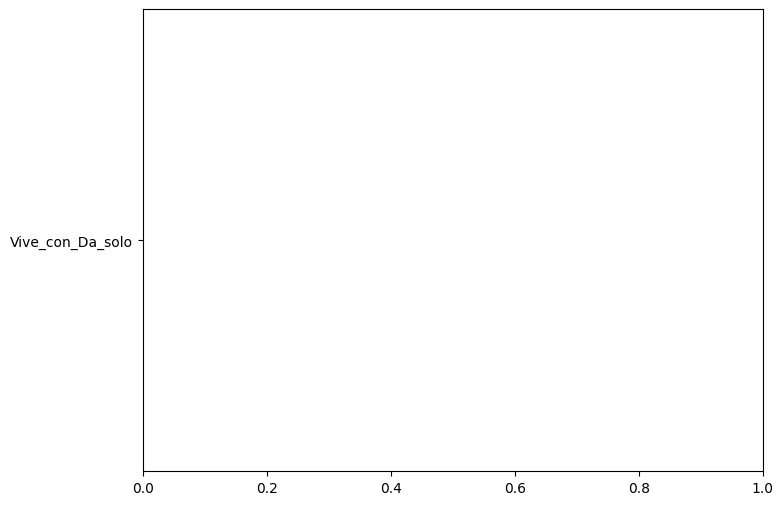

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- Resample coerente col training ---
X_test_resampled, y_test_resampled = NearMiss(version=3).fit_resample(X_test, y_test)

# --- Permutation Importance ---
r = permutation_importance(
    best_pipeline.named_steps["model"],
    X_test_resampled,
    y_test_resampled,
    n_repeats=20,
    random_state=42,
    scoring=f2_scorer
)

importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std
}).sort_values("importance_mean", ascending=False)

# --- Top 10 ---
top10 = importances.head(10)
print(top10)



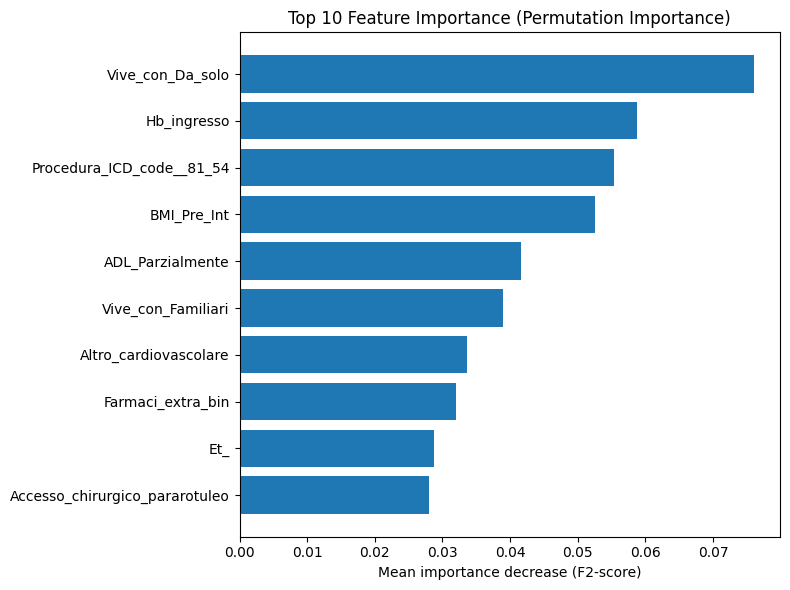

In [347]:
import matplotlib.pyplot as plt
import numpy as np

top10 = importances.head(10)

# Calcolo error bars: std sopra e sotto
x = top10["importance_mean"]

plt.figure(figsize=(8, 6))
plt.barh(top10["feature"], x, capsize=4)
plt.xlabel("Mean importance decrease (F2-score)")
plt.title("Top 10 Feature Importance (Permutation Importance)")
plt.gca().invert_yaxis()  # la più importante in alto
plt.tight_layout()
plt.show()


## TEST TRA MODELLI

### LOG-REG

In [95]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------
# 1. INDICI DELLE FEATURES CATEGORICALI
# -----------------------------------------------------
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]

# -----------------------------------------------------
# 2. COSTRUZIONE MODELLO CON PARAMETRI OTTIMALI
# -----------------------------------------------------
smote = SMOTENC(
    categorical_features=cat_idx,
    random_state=42
)

logreg = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    max_iter=500,
    C=0.01,            # ← miglior valore
    class_weight=None  # ← miglior valore
)

# **NOME CHIARO DEL MODELLO**
LogReg_SMOTENC_C001 = Pipeline([
    ('smote', smote),
    ('model', logreg)
])

# -----------------------------------------------------
# 3. TRAIN
# -----------------------------------------------------
LogReg_SMOTENC_C001.fit(X_train, y_train)

# -----------------------------------------------------
# 4. PREDIZIONI
# -----------------------------------------------------
y_pred_logreg = LogReg_SMOTENC_C001.predict(X_test)

# -----------------------------------------------------
# 5. VALUTAZIONE
# -----------------------------------------------------
results = evaluate_classification_with_ci(
    y_test, y_pred_logreg,
    "LogReg + SMOTENC (C=0.01)"
)



LogReg + SMOTENC (C=0.01) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.5755  [0.3921, 0.7103]
  Balanced Accuracy  = 0.8271  [0.7192, 0.9092]


### Random Forest

In [96]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score, balanced_accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# 1. COSTRUZIONE DEL MODELLO CON PARAMETRI SPECIFICI
# -----------------------------------------------------
BalancedRF_n300_split5_leaf1 = BalancedRandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=1,
    random_state=42
)

# -----------------------------------------------------
# 2. FIT SUI DATI DI TRAIN
# -----------------------------------------------------
BalancedRF_n300_split5_leaf1.fit(X_train, y_train)

# -----------------------------------------------------
# 3. PREDIZIONI SUL TEST SET
# -----------------------------------------------------
y_pred_brf = BalancedRF_n300_split5_leaf1.predict(X_test)

# -----------------------------------------------------
# 4. FUNZIONE DI VALUTAZIONE CON BOOTSTRAP
# -----------------------------------------------------
def evaluate_classification_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    f2 = fbeta_score(y_true, y_pred, beta=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    # Bootstrap
    f2_boot, balacc_boot = [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        f2_boot.append(fbeta_score(y_true_sample, y_pred_sample, beta=2))
        balacc_boot.append(balanced_accuracy_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    f2_ci = np.percentile(f2_boot, [lower, upper])
    balacc_ci = np.percentile(balacc_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  F2-score           = {f2:.4f}  [{f2_ci[0]:.4f}, {f2_ci[1]:.4f}]")
    print(f"  Balanced Accuracy  = {bal_acc:.4f}  [{balacc_ci[0]:.4f}, {balacc_ci[1]:.4f}]")

    return {
        'F2': f2, 'F2_CI': f2_ci,
        'Balanced_Accuracy': bal_acc, 'Balanced_Accuracy_CI': balacc_ci
    }

# -----------------------------------------------------
# 5. VALUTAZIONE FINALE
# -----------------------------------------------------
results = evaluate_classification_with_ci(y_test, y_pred_brf, "Balanced Random Forest (n300, split5, leaf1)")

# -----------------------------------------------------
# 6. CLASSIFICATION REPORT E CONFUSION MATRIX
# -----------------------------------------------------
print("\nClassification report:\n", classification_report(y_test, y_pred_brf, digits=4))
cm = confusion_matrix(y_test, y_pred_brf)
print("Confusion matrix:\n", cm)




Balanced Random Forest (n300, split5, leaf1) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.6349  [0.4443, 0.7693]
  Balanced Accuracy  = 0.8492  [0.7422, 0.9320]

Classification report:
               precision    recall  f1-score   support

           0     0.9851    0.8983    0.9397       295
           1     0.3478    0.8000    0.4848        20

    accuracy                         0.8921       315
   macro avg     0.6665    0.8492    0.7123       315
weighted avg     0.9447    0.8921    0.9108       315

Confusion matrix:
 [[265  30]
 [  4  16]]


### LightGBM

In [97]:
import re

def clean_colname(col):
    # conserva solo lettere, numeri e underscore
    return re.sub(r'[^A-Za-z0-9_]+', '_', col)

X_train = X_train.rename(columns=lambda c: clean_colname(c))
X_test = X_test.rename(columns=lambda c: clean_colname(c))

categorical_features = [clean_colname(c) for c in categorical_features]

# CATEGORICAL INDICES
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]


In [98]:
from lightgbm import LGBMClassifier

# -----------------------------------------------------
# 1. CALCOLO scale_pos_weight
# -----------------------------------------------------
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / n_pos

print("scale_pos_weight =", scale_pos_weight)

# -----------------------------------------------------
# 2. COSTRUZIONE MODELLO CON PARAMETRI SPECIFICI
# -----------------------------------------------------
LGBM_scalePW_n200_depth5_lr001_leaves31 = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.01,
    num_leaves=31,
    min_child_samples=None,
    random_state=42,
    scale_pos_weight=scale_pos_weight,  # gestione sbilanciamento
    class_weight=None                    # evitare insieme a scale_pos_weight
)

# -----------------------------------------------------
# 3. FIT SUI DATI DI TRAIN
# -----------------------------------------------------
LGBM_scalePW_n200_depth5_lr001_leaves31.fit(X_train, y_train)

# -----------------------------------------------------
# 4. PREDIZIONI SUL TEST SET
# -----------------------------------------------------
y_pred_lgb = LGBM_scalePW_n200_depth5_lr001_leaves31.predict(X_test)

# -----------------------------------------------------
# 5. VALUTAZIONE
# -----------------------------------------------------
results = evaluate_classification_with_ci(
    y_test, y_pred_lgb,
    "LightGBM (scale_pos_weight, n200, depth5, lr0.01, leaves31)"
)


scale_pos_weight = 15.986486486486486
[LightGBM] [Info] Number of positive: 74, number of negative: 1183
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 450
[LightGBM] [Info] Number of data points in the train set: 1257, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.058870 -> initscore=-2.771744
[LightGBM] [Info] Start training from score -2.771744
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

### Decision Tree

In [99]:
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# -----------------------------------------------------
# 1. COSTRUZIONE MODELLO CON PARAMETRI SPECIFICI
# -----------------------------------------------------
BalancedBagging_DT_n50_depth10 = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ),
    n_estimators=50,
    random_state=42
)

# -----------------------------------------------------
# 2. FIT SUI DATI DI TRAIN
# -----------------------------------------------------
BalancedBagging_DT_n50_depth10.fit(X_train, y_train)

# -----------------------------------------------------
# 3. PREDIZIONI SUL TEST SET
# -----------------------------------------------------
y_pred_dt = BalancedBagging_DT_n50_depth10.predict(X_test)

# -----------------------------------------------------
# 4. VALUTAZIONE
# -----------------------------------------------------
results = evaluate_classification_with_ci(
    y_test, y_pred_dt, "Balanced Bagging + DT (n50, depth10)"
)



Balanced Bagging + DT (n50, depth10) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.5839  [0.4018, 0.7203]
  Balanced Accuracy  = 0.8305  [0.7210, 0.9117]


### SVC

In [100]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import NearMiss
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------
# 1. DEFINIZIONE UNDERSAMPLER
# -----------------------------------------------------
best_sampler = NearMiss(version=3)

# -----------------------------------------------------
# 2. COSTRUZIONE PIPELINE CON PARAMETRI SPECIFICI
# -----------------------------------------------------
SVC_NearMissv3_rbf_C1_gammaScale = Pipeline([
    ('under', best_sampler),
    ('scaler', StandardScaler(with_mean=False)),
    ('model', SVC(
        kernel='rbf',
        C=1,
        gamma='scale',
        probability=True,
        random_state=42
    ))
])

# -----------------------------------------------------
# 3. FIT SUI DATI DI TRAIN
# -----------------------------------------------------
SVC_NearMissv3_rbf_C1_gammaScale.fit(X_train, y_train)

# -----------------------------------------------------
# 4. PREDIZIONI SUL TEST SET
# -----------------------------------------------------
y_pred_svc = SVC_NearMissv3_rbf_C1_gammaScale.predict(X_test)

# -----------------------------------------------------
# 5. VALUTAZIONE
# -----------------------------------------------------
results = evaluate_classification_with_ci(
    y_test, y_pred_svc,
    "SVC + NearMiss v3 (rbf, C=1, gamma=scale)"
)


SVC + NearMiss v3 (rbf, C=1, gamma=scale) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4972  [0.3425, 0.6154]
  Balanced Accuracy  = 0.8093  [0.7254, 0.8699]


### MLP

In [22]:
import numpy as np
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from imblearn.under_sampling import NearMiss
from imblearn.pipeline import Pipeline
from scikeras.wrappers import KerasClassifier

# ---------------------------------------------------
# 1. RIPRODUCIBILITÀ
# ---------------------------------------------------
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# ---------------------------------------------------
# 2. DEFINIZIONE DEL MODELLO MLP
# ---------------------------------------------------
def build_mlp(n_hidden=1, n_neurons=64, dropout_rate=0.0, lr=0.001, optimizer="rmsprop"):
    
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    # Hidden layers
    for _ in range(n_hidden):
        model.add(layers.Dense(n_neurons, activation="relu"))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    # Output layer
    model.add(layers.Dense(1, activation="sigmoid"))

    # Optimizer
    if optimizer == "rmsprop":
        opt = keras.optimizers.RMSprop(learning_rate=lr)
    else:
        opt = keras.optimizers.Adam(learning_rate=lr)

    # Compile
    model.compile(
        loss="binary_crossentropy",
        optimizer=opt,
        metrics=["accuracy"]
    )

    return model

# ---------------------------------------------------
# 3. UNDERSAMPLER
# ---------------------------------------------------
under_sampler = NearMiss(version=3)

# ---------------------------------------------------
# 4. PIPELINE COMPLETA MLP
# ---------------------------------------------------
MLP_deterministic = Pipeline([
    ("under", under_sampler),
    ("model", KerasClassifier(
        model=build_mlp,
        n_hidden=1,
        n_neurons=64,
        dropout_rate=0.0,
        lr=0.001,
        optimizer="rmsprop",
        batch_size=32,
        epochs=50,
        verbose=0,         # evita spam
        random_state=42
    ))
])

# ---------------------------------------------------
# 5. FIT
# ---------------------------------------------------
MLP_deterministic.fit(X_train, y_train)

# ---------------------------------------------------
# 6. PREVISIONI
# ---------------------------------------------------
y_pred_mlp = MLP_deterministic.predict(X_test)

# ---------------------------------------------------
# 7. VALUTAZIONE
# ---------------------------------------------------
evaluate_classification_with_ci(
    y_test, y_pred_mlp,
    "MLP + NearMiss_v3 (FINAL, deterministic)"
)



MLP + NearMiss_v3 (FINAL, deterministic) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.5249  [0.3773, 0.6365]
  Balanced Accuracy  = 0.8360  [0.7726, 0.8793]


{'F2': 0.5248618784530387,
 'F2_CI': array([0.37729953, 0.6364644 ]),
 'Balanced_Accuracy': 0.8360169491525424,
 'Balanced_Accuracy_CI': array([0.7725696 , 0.87931911])}

### Ensemble all

In [101]:
from sklearn.ensemble import VotingClassifier
from itertools import combinations
import numpy as np

# ================================
# 1. DIZIONARIO DEI MODELLI
# ================================
models = {
    "LogReg": LogReg_SMOTENC_C001,
    "BalancedRF": BalancedRF_n300_split5_leaf1,
    "LightGBM": LGBM_scalePW_n200_depth5_lr001_leaves31,
    "BalancedBagging": BalancedBagging_DT_n50_depth10,
    "SVC": SVC_NearMissv3_rbf_C1_gammaScale,
}

# ================================
# 2. GENERAZIONE DI TUTTE LE COMBINAZIONI
# ================================
all_combinations = []
model_names = list(models.keys())

for r in range(2, len(models) + 1):
    combos = list(combinations(model_names, r))
    all_combinations.extend(combos)

print(f"Numero totale ensemble: {len(all_combinations)}")

# ================================
# 3. FUNZIONE PER CREARE ENSEMBLE
# ================================
def build_voting_ensemble(names):
    estimators = [(name, models[name]) for name in names]
    
    # Determina se tutti gli stimatori supportano predict_proba
    supports_proba = True
    for _, est in estimators:
        try:
            _ = est.predict_proba(X_train[:1])
        except:
            supports_proba = False
            break
    
    voting_type = 'soft' if supports_proba else 'hard'
    
    return VotingClassifier(
        estimators=estimators,
        voting=voting_type
    )

# ================================
# 4. TRAIN & EVALUATION LOOP
# ================================
ensemble_results = {}

for combo in all_combinations:
    print("\n==============================================")
    print(f"➡️  ENSEMBLE: {combo}")
    print("==============================================")

    ensemble = build_voting_ensemble(combo)

    # Fit
    ensemble.fit(X_train, y_train)

    # Predizioni
    y_pred = ensemble.predict(X_test)

    # Valutazione con CI
    name = "Ensemble [" + " + ".join(combo) + "]"
    res = evaluate_classification_with_ci(y_test, y_pred, name)

    # Salvataggio
    ensemble_results[name] = res

print("\n\n⭐⭐ FINITO! Tutti gli ensemble sono stati valutati.")


Numero totale ensemble: 26

➡️  ENSEMBLE: ('LogReg', 'BalancedRF')

Ensemble [LogReg + BalancedRF] Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.5932  [0.3911, 0.7438]
  Balanced Accuracy  = 0.8093  [0.6895, 0.9080]

➡️  ENSEMBLE: ('LogReg', 'LightGBM')
[LightGBM] [Info] Number of positive: 74, number of negative: 1183
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001321 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 450
[LightGBM] [Info] Number of data points in the train set: 1257, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.058870 -> initscore=-2.771744
[LightGBM] [Info] Start training from score -2.771744
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

In [31]:
ensemble_results

{'Ensemble [LogReg + BalancedRF]': {'F2': 0.5932203389830508,
  'F2_CI': array([0.39113712, 0.74384015]),
  'Balanced_Accuracy': 0.809322033898305,
  'Balanced_Accuracy_CI': array([0.68951999, 0.90798898])},
 'Ensemble [LogReg + LightGBM]': {'F2': 0.6140350877192983,
  'F2_CI': array([0.40399687, 0.75955395]),
  'Balanced_Accuracy': 0.8161016949152542,
  'Balanced_Accuracy_CI': array([0.69825715, 0.91346716])},
 'Ensemble [LogReg + BalancedBagging]': {'F2': 0.603448275862069,
  'F2_CI': array([0.39600703, 0.75482227]),
  'Balanced_Accuracy': 0.8127118644067797,
  'Balanced_Accuracy_CI': array([0.69191288, 0.91175143])},
 'Ensemble [LogReg + SVC]': {'F2': 0.5882352941176471,
  'F2_CI': array([0.40228602, 0.72117313]),
  'Balanced_Accuracy': 0.8322033898305086,
  'Balanced_Accuracy_CI': array([0.72526714, 0.91445183])},
 'Ensemble [BalancedRF + LightGBM]': {'F2': 0.6722689075630253,
  'F2_CI': array([0.48182805, 0.80357143]),
  'Balanced_Accuracy': 0.8610169491525423,
  'Balanced_Accurac

In [32]:
sorted_results = sorted(
    ensemble_results.items(),
    key=lambda x: (x[1]['F2'], x[1]['Balanced_Accuracy']),
    reverse=True
)

for name, metrics in sorted_results:
    print(
        f"{name}\n"
        f"  F2: {metrics['F2']}\n"
        f"  F2_CI: {metrics['F2_CI']}\n"
        f"  Balanced_Accuracy: {metrics['Balanced_Accuracy']}\n"
        f"  Balanced_Accuracy_CI: {metrics['Balanced_Accuracy_CI']}\n"
    )


Ensemble [BalancedRF + LightGBM]
  F2: 0.6722689075630253
  F2_CI: [0.48182805 0.80357143]
  Balanced_Accuracy: 0.8610169491525423
  Balanced_Accuracy_CI: [0.75304994 0.94379863]

Ensemble [LogReg + BalancedRF + LightGBM + BalancedBagging]
  F2: 0.6611570247933884
  F2_CI: [0.47086704 0.79547969]
  Balanced_Accuracy: 0.8576271186440678
  Balanced_Accuracy_CI: [0.74918006 0.94003591]

Ensemble [LogReg + LightGBM + BalancedBagging + SVC]
  F2: 0.6611570247933884
  F2_CI: [0.47045144 0.79792553]
  Balanced_Accuracy: 0.8576271186440678
  Balanced_Accuracy_CI: [0.75061911 0.93890538]

Ensemble [BalancedRF + LightGBM + BalancedBagging + SVC]
  F2: 0.6611570247933884
  F2_CI: [0.47037815 0.79755417]
  Balanced_Accuracy: 0.8576271186440678
  Balanced_Accuracy_CI: [0.75048115 0.94061081]

Ensemble [BalancedRF + BalancedBagging]
  F2: 0.6557377049180327
  F2_CI: [0.46607706 0.79269344]
  Balanced_Accuracy: 0.8559322033898304
  Balanced_Accuracy_CI: [0.74874556 0.93875322]

Ensemble [LogReg + Bal

#### Feature Importance del modello migliore LightGBM + RF

[LightGBM] [Info] Number of positive: 74, number of negative: 1183
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001081 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 450
[LightGBM] [Info] Number of data points in the train set: 1257, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.058870 -> initscore=-2.771744
[LightGBM] [Info] Start training from score -2.771744
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

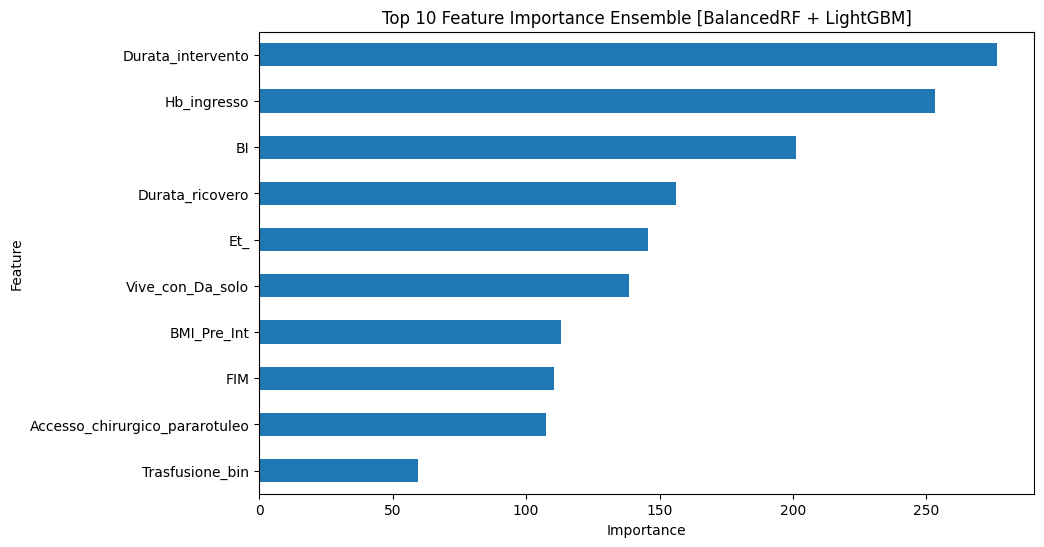


Top 10 Feature Importance combinata:

                                BalancedRF  LightGBM  mean_importance
Durata_intervento                 0.070782       553       276.535391
Hb_ingresso                       0.062271       506       253.031135
BI                                0.056745       402       201.028373
Durata_ricovero                   0.110774       312       156.055387
Et_                               0.074452       291       145.537226
Vive_con_Da_solo                  0.096521       277       138.548260
BMI_Pre_Int                       0.062294       226       113.031147
FIM                               0.058376       221       110.529188
Accesso_chirurgico_pararotuleo    0.022254       215       107.511127
Trasfusione_bin                   0.014365       119        59.507182


In [110]:
# ==============================
# ✅ VotingClassifier + Top 10 Feature Importance
# ==============================
from sklearn.ensemble import VotingClassifier
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------
# 1. CREAZIONE DEL VOTING CLASSIFIER
# ------------------------------
def build_voting_ensemble(names, models_dict, X_train):
    """
    Crea un VotingClassifier dai nomi dei modelli e dal dizionario.
    Sceglie 'soft' se tutti supportano predict_proba, altrimenti 'hard'.
    """
    estimators = [(name, models_dict[name]) for name in names]
    
    # Controllo supporto predict_proba
    supports_proba = True
    for _, est in estimators:
        try:
            _ = est.predict_proba(X_train[:1])
        except:
            supports_proba = False
            break
    
    voting_type = 'soft' if supports_proba else 'hard'
    
    return VotingClassifier(estimators=estimators, voting=voting_type)

# ------------------------------
# 2. FUNZIONE FEATURE IMPORTANCE
# ------------------------------
def ensemble_feature_importance_top10(voting_ensemble, feature_names):
    """
    Calcola feature importance combinata per un VotingClassifier e mostra top 10.
    Mostra le feature più importanti in alto nel grafico a barre orizzontali.
    """
    fi_dict = {}
    
    # Prendiamo i nomi dai tuple originali passate a VotingClassifier
    for name, est in voting_ensemble.estimators:
        if hasattr(est, "feature_importances_"):
            fi_dict[name] = est.feature_importances_
        else:
            print(f"{name} non supporta feature_importances_ e sarà ignorato")
    
    fi_df = pd.DataFrame(fi_dict, index=feature_names)
    fi_df["mean_importance"] = fi_df.mean(axis=1)
    fi_df = fi_df.sort_values("mean_importance", ascending=False)
    
    # Top 10
    fi_top10 = fi_df.head(10)
    
    # Plot barre orizzontali con le feature più importanti in alto
    plt.figure(figsize=(10,6))
    fi_top10["mean_importance"].sort_values(ascending=True).plot(kind="barh")
    plt.title("Top 10 Feature Importance Ensemble [BalancedRF + LightGBM]")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
    
    return fi_top10


# ------------------------------
# 3. DIZIONARIO MODELLI
# ------------------------------
models = {
    "BalancedRF": BalancedRF_n300_split5_leaf1,
    "LightGBM": LGBM_scalePW_n200_depth5_lr001_leaves31
}

# ------------------------------
# 4. CREAZIONE E FIT DEL VOTING ENSEMBLE
# ------------------------------
best_ensemble = build_voting_ensemble(["BalancedRF", "LightGBM"], models, X_train)
best_ensemble.fit(X_train, y_train)

# ------------------------------
# 5. CALCOLO TOP 10 FEATURE IMPORTANCE
# ------------------------------
feature_names = X_train.columns  # se X_train è DataFrame
fi_top10 = ensemble_feature_importance_top10(best_ensemble, feature_names)

# ------------------------------
# 6. STAMPA RISULTATO
# ------------------------------
print("\nTop 10 Feature Importance combinata:\n")
print(fi_top10)


### TEST

In [ ]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations
import pandas as pd
import numpy as np
from sklearn.metrics import fbeta_score

def compute_sample_f2(y_true, y_pred):
    """
    Calcola il 'contributo F2' per ogni sample.
    Restituisce un array float [0,1] per ogni campione:
      1 se corretto, 0 se sbagliato
      o ponderato se si usa probabilità
    """
    return (y_pred == y_true).astype(float)

def compare_classifiers_continuous(y_test, y_pred_model1, y_pred_model2, metric_func=compute_sample_f2):
    """
    Confronta due modelli usando Wilcoxon sui vettori metrici per sample.
    """
    metric1 = metric_func(y_test, y_pred_model1)
    metric2 = metric_func(y_test, y_pred_model2)
    
    stat, p_value = wilcoxon(metric1, metric2)
    return stat, p_value

def compare_multiple_classifiers_continuous(y_test, predictions_dict, metric_func=compute_sample_f2, correction='fdr_bh'):
    """
    Confronta tutti i modelli a coppie usando Wilcoxon sui vettori metrici e corregge p-value.
    """
    results = []
    p_values = []
    
    for (name1, y_pred1), (name2, y_pred2) in combinations(predictions_dict.items(), 2):
        stat, p_value = compare_classifiers_continuous(y_test, y_pred1, y_pred2, metric_func)
        results.append({
            'Model 1': name1,
            'Model 2': name2,
            'Statistic': stat,
            'Raw p-value': p_value
        })
        p_values.append(p_value)
    
    # Correzione per test multipli (Benjamini–Hochberg)
    reject, corrected_pvals, _, _ = multipletests(p_values, method=correction)
    
    for i, res in enumerate(results):
        res['Corrected p-value'] = corrected_pvals[i]
        res['Significant'] = reject[i]
    
    return pd.DataFrame(results)

# -----------------------------
# Esempio d’uso
# -----------------------------
predictions_classifiers = {
    'LogReg_SMOTENC': y_pred_logreg,
    'BalancedRF': y_pred_brf,
    'LightGBM': y_pred_lgb,
    'BalancedBagging_DT': y_pred_dt,
    'SVC_NearMissv3': y_pred_svc,
    'MLP_NearMissv3': y_pred_mlp
}

results_df_classifiers = compare_multiple_classifiers_continuous(
    y_test,
    predictions_classifiers,
    metric_func=compute_sample_f2
)

print(results_df_classifiers)


               Model 1             Model 2  Statistic   Raw p-value  \
0       LogReg_SMOTENC          BalancedRF      120.0  1.577676e-02   
1       LogReg_SMOTENC            LightGBM      136.0  3.083186e-03   
2       LogReg_SMOTENC  BalancedBagging_DT      472.5  7.630246e-01   
3       LogReg_SMOTENC      SVC_NearMissv3      122.5  4.138729e-08   
4       LogReg_SMOTENC      MLP_NearMissv3      243.0  1.527379e-06   
5           BalancedRF            LightGBM       16.5  2.059032e-01   
6           BalancedRF  BalancedBagging_DT       40.0  1.161689e-02   
7           BalancedRF      SVC_NearMissv3      120.0  3.144620e-11   
8           BalancedRF      MLP_NearMissv3      220.5  1.087513e-09   
9             LightGBM  BalancedBagging_DT       33.0  1.063115e-03   
10            LightGBM      SVC_NearMissv3      165.0  8.983769e-12   
11            LightGBM      MLP_NearMissv3      234.5  1.546079e-10   
12  BalancedBagging_DT      SVC_NearMissv3      532.5  1.744996e-06   
13  Ba

## ANALISI DEGLI ERRORI

In [384]:
print(X_train.columns.tolist())


['Sesso_F', 'Rischio_bio_bin', 'Trasfusione_bin', 'Farmaci_extra_bin', 'Sedentarieta', 'Diagnosi_alla_dimissione_ICD_code__715_16', 'Diagnosi_alla_dimissione_ICD_code__715_25', 'Diagnosi_alla_dimissione_ICD_code__715_26', 'Procedura_ICD_code__81_54', 'Accesso_chirurgico_laterale_diretto', 'Accesso_chirurgico_midvastus', 'Accesso_chirurgico_pararotuleo', 'Accesso_chirurgico_postero_laterale', 'Anestesia_Blended', 'Anestesia_Generale', 'Anestesia_Subaracnoidea', 'ADL_Non_Autonomo', 'ADL_Parzialmente', 'L_Autonomia_passaggi_posturali_Non_Autonomo', 'L_Autonomia_passaggi_posturali_Parzialmente', 'Ausili_Deambulazione_Canadesi_e_walker', 'Ausili_Deambulazione_Girello', 'Ausili_Deambulazione_Walker', 'Vive_con_Con_familiare_caregiver', 'Vive_con_Da_solo', 'Vive_con_Familiari', 'Precedente_protesi_si_anca', 'Precedente_protesi_si_anca_e_ginocchio', 'Precedente_protesi_si_ginocchio', 'Altro_apparato_digerente', 'Altro_cardiovascolare', 'Altro_cute_ed_annessi', 'Altro_muscoloscheletrico', 'Altr

In [385]:
import pandas as pd
import numpy as np

# Dizionario dei modelli e predizioni
models = {
    "LogReg + SMOTENC (C=0.01)": y_pred_logreg,
    "Balanced RF (n300, split5, leaf1)": y_pred_brf,
    "LightGBM (scale_pos_weight)": y_pred_lgb,
    "Balanced Bagging + DT (n50, depth10)": y_pred_dt,
    "SVC + NearMiss v3 (rbf, C=1)": y_pred_svc,
    "MLP + NearMiss_v3 (FINAL, deterministic)": y_pred_mlp
}

# Lista delle feature cliniche principali (modifica se necessario)
numeric_features = [
    "Et_",                # età
    "BMI_Pre_Int",        # BMI pre-intervento
    "Durata_ricovero",    # durata ricovero
    "Durata_intervento",  # durata intervento
    "BI",                 # Barthel Index
    "FIM",                # Functional Independence Measure
    "Hb_ingresso",        # emoglobina all’ingresso
    "Terapia_farm_num"    # numero di farmaci
]
categorical_features = [
    "Sesso_F",
    "Rischio_bio_bin",
    "Trasfusione_bin",
    "Farmaci_extra_bin",
    "Sedentarieta",
    "Diagnosi_alla_dimissione_ICD_code__715_16",
    "Diagnosi_alla_dimissione_ICD_code__715_25",
    "Diagnosi_alla_dimissione_ICD_code__715_26",
    "Procedura_ICD_code__81_54",
    "Accesso_chirurgico_laterale_diretto",
    "Accesso_chirurgico_midvastus",
    "Accesso_chirurgico_pararotuleo",
    "Accesso_chirurgico_postero_laterale",
    "Anestesia_Blended",
    "Anestesia_Generale",
    "Anestesia_Subaracnoidea",
    "ADL_Non_Autonomo",
    "ADL_Parzialmente",
    "L_Autonomia_passaggi_posturali_Non_Autonomo",
    "L_Autonomia_passaggi_posturali_Parzialmente",
    "Ausili_Deambulazione_Canadesi_e_walker",
    "Ausili_Deambulazione_Girello",
    "Ausili_Deambulazione_Walker",
    "Vive_con_Con_familiare_caregiver",
    "Vive_con_Da_solo",
    "Vive_con_Familiari",
    "Precedente_protesi_si_anca",
    "Precedente_protesi_si_anca_e_ginocchio",
    "Precedente_protesi_si_ginocchio",
    "Altro_apparato_digerente",
    "Altro_cardiovascolare",
    "Altro_cute_ed_annessi",
    "Altro_muscoloscheletrico",
    "Altro_respiratorio",
    "Altro_sistema_emolinfopoietico",
    "Altro_sistema_endocrino_metabolico",
    "Altro_sistema_nervoso_centrale",
    "Altro_sistema_nervoso_periferico",
    "Altro_sistema_urinario",
    "Anemie",
    "Apnee_notturne",
    "Apparato_visivo",
    "Artrite_reumatoide",
    "Asma",
    "BPCO",
    "Diabete_1",
    "Diabete_2",
    "Dislipidemia",
    "Fibrillazione_atriale",
    "Insufficienza_renale_cronica",
    "Ipercol_e_o_ipertrig_",
    "Ipertensione_arteriosa",
    "Malattie_della_tiroide",
    "Malattie_infettive",
    "Osteoporosi",
    "Parkinson",
    "Psiche",
    "Tiroide",
    "Tumore",
    "Tumori"
]

# Analisi errori per ciascun modello
error_analysis = {}

for name, y_pred in models.items():
    # Costruisci DataFrame con predizioni e target
    df = X_test.copy()
    df['y_true'] = y_test
    df['y_pred'] = y_pred
    
    # Casi mal classificati
    misclassified = df[df['y_true'] != df['y_pred']]
    n_errors = misclassified.shape[0]
    
    # Errori per classe
    errors_per_class = misclassified['y_true'].value_counts().to_dict()
    
    # Statistiche numeriche
    numeric_stats = misclassified[numeric_features].describe().T[['mean','std','min','max']]
    
    # Frequenze feature categoriche
    categorical_stats = {}
    for col in categorical_features:
        categorical_stats[col] = misclassified[col].value_counts().to_dict()
    
    # Salvataggio risultati
    error_analysis[name] = {
        "total_errors": n_errors,
        "errors_per_class": errors_per_class,
        "numeric_stats": numeric_stats,
        "categorical_stats": categorical_stats
    }

# Stampa riepilogo
for name, stats in error_analysis.items():
    print(f"\n=== {name} ===")
    print(f"Total misclassified: {stats['total_errors']}")
    print(f"Errors per class: {stats['errors_per_class']}")
    print("Numeric feature stats on misclassified cases:")
    print(stats['numeric_stats'])
    print("Categorical feature frequencies on misclassified cases:")
    for col, freq in stats['categorical_stats'].items():
        print(f"  {col}: {freq}")



=== LogReg + SMOTENC (C=0.01) ===
Total misclassified: 47
Errors per class: {0: 43, 1: 4}
Numeric feature stats on misclassified cases:
                       mean       std       min       max
Et_                0.552463  0.962253 -1.793092  1.960637
BMI_Pre_Int       -0.004297  1.070824 -1.822970  2.530057
Durata_ricovero    0.398187  1.082152 -1.269196  3.044583
Durata_intervento  0.174796  0.952259 -1.275278  2.493133
BI                 0.337345  0.987163 -2.037037  1.775248
FIM                0.334792  0.960028 -1.983147  2.607468
Hb_ingresso       -0.175995  0.943615 -1.670977  1.804005
Terapia_farm_num   0.946809  0.155830  0.500000  1.000000
Categorical feature frequencies on misclassified cases:
  Sesso_F: {1: 38, 0: 9}
  Rischio_bio_bin: {0: 47}
  Trasfusione_bin: {0: 43, 1: 4}
  Farmaci_extra_bin: {0: 35, 1: 12}
  Sedentarieta: {0: 36, 1: 11}
  Diagnosi_alla_dimissione_ICD_code__715_16: {1.0: 24, 0.0: 23}
  Diagnosi_alla_dimissione_ICD_code__715_25: {0.0: 44, 1.0: 3}
  Diag

## Visualizzazione comparativa

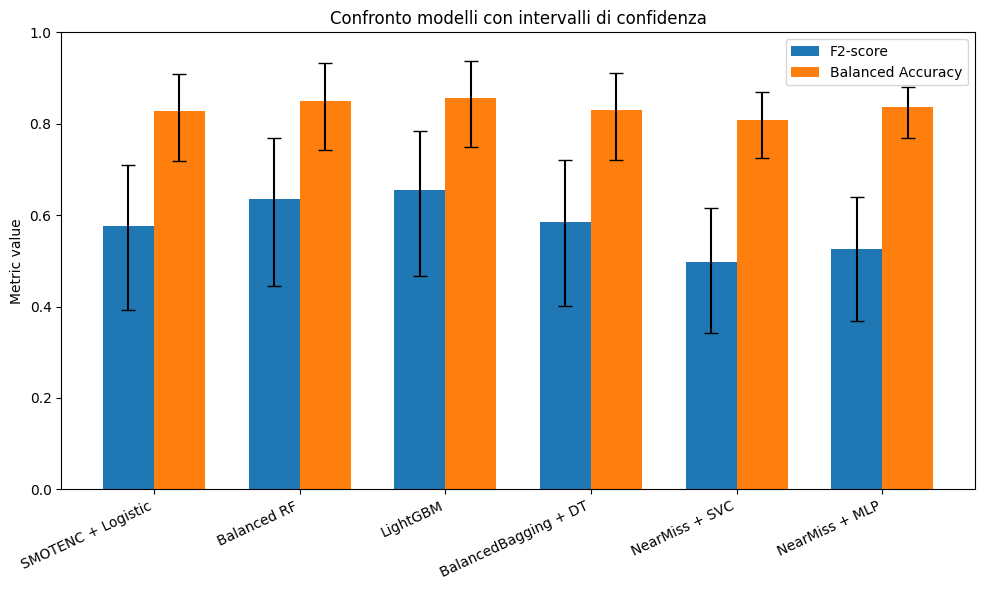

In [387]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "SMOTENC + Logistic",
    "Balanced RF",
    "LightGBM",
    "BalancedBagging + DT",
    "NearMiss + SVC",
    "NearMiss + MLP"
]

f2 = [0.576, 0.635, 0.656, 0.584, 0.497, 0.525]
f2_err = [[0.576 - 0.392, 0.635 - 0.444, 0.656 - 0.467, 0.584 - 0.402, 0.497 - 0.343, 0.525 - 0.369],
          [0.710 - 0.576, 0.769 - 0.635, 0.785 - 0.656, 0.720 - 0.584, 0.615 - 0.497, 0.639 - 0.525]]

ba = [0.827, 0.849, 0.856, 0.831, 0.809, 0.836]
ba_err = [[0.827 - 0.719, 0.849 - 0.742, 0.856 - 0.748, 0.831 - 0.721, 0.809 - 0.725, 0.836 - 0.768],
          [0.909 - 0.827, 0.932 - 0.849, 0.937 - 0.856, 0.912 - 0.831, 0.870 - 0.809, 0.880 - 0.836]]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, f2, width, yerr=f2_err, capsize=5, label='F2-score')
ax.bar(x + width/2, ba, width, yerr=ba_err, capsize=5, label='Balanced Accuracy')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha='right')
ax.set_ylim(0,1)
ax.set_ylabel("Metric value")
ax.set_title("Confronto modelli con intervalli di confidenza")
ax.legend()

plt.tight_layout()
plt.show()


# No Imputation

In [76]:
# Target
y_train = train_df['Outcome Sociale bin']
y_test = test_df['Outcome Sociale bin']

# Features
X_train = train_final_no_imputation  
X_test = test_final_no_imputation   

X_train_clean = X_train.dropna()
y_train_clean = y_train.loc[X_train_clean.index]

X_test_clean = X_test.dropna()
y_test_clean = y_test.loc[X_test_clean.index]


## Logistic

### OVERSAMPLING

#### SMOTENC

In [404]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np

# -----------------------------
# CATEGORICAL INDICES
# -----------------------------
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]

# -----------------------------
# PIPELINE LR + SMOTENC
# -----------------------------
smote = SMOTENC(categorical_features=cat_idx, random_state=42)

lr = LogisticRegression(
    penalty='l2',
    solver='liblinear',   # ottimo per dataset sbilanciati e piccoli
    max_iter=500
)

pipeline = Pipeline([
    ('smote', smote),
    ('model', lr)
])

# -----------------------------
# GRIDSEARCH
# -----------------------------
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

# -----------------------------
# FIT GRIDSEARCH
# -----------------------------
grid_search.fit(X_train_clean, y_train_clean)
best_pipeline = grid_search.best_estimator_
print("Best Hyper-parameters:", grid_search.best_params_)

# -----------------------------
# PREDIZIONI TEST
# -----------------------------
y_pred = best_pipeline.predict(X_test_clean)

# -----------------------------
# VALUTAZIONE
# -----------------------------
results = evaluate_classification_with_ci(
    y_test_clean, y_pred,
    "Logistic Regression + SMOTENC"
)


Best Hyper-parameters: {'model__C': 0.01, 'model__class_weight': None}

Logistic Regression + SMOTENC Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.5046  [0.3191, 0.6594]
  Balanced Accuracy  = 0.7636  [0.6536, 0.8808]


#### Class_weight Balanced

In [405]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np

# -----------------------------
# MODELLO BASE
# -----------------------------
lr_balanced = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    class_weight='balanced',
    max_iter=500,
    random_state=42
)

# -----------------------------
# GRIDSEARCH
# -----------------------------
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=lr_balanced,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

# -----------------------------
# FIT GRIDSEARCH
# -----------------------------
grid_search.fit(X_train_clean, y_train_clean)
best_lr = grid_search.best_estimator_
print("Best Hyper-parameters:", grid_search.best_params_)

# -----------------------------
# PREDIZIONI TEST
# -----------------------------
y_pred = best_lr.predict(X_test_clean)

# -----------------------------
# VALUTAZIONE
# -----------------------------
results = evaluate_classification_with_ci(
    y_test_clean, y_pred,
    "Logistic Regression (class_weight=balanced)"
)


Best Hyper-parameters: {'C': 0.01}

Logistic Regression (class_weight=balanced) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4962  [0.3174, 0.6333]
  Balanced Accuracy  = 0.7789  [0.6642, 0.8773]


### UNDERSAMPLING

In [406]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss,
    EditedNearestNeighbours, TomekLinks,
    ClusterCentroids
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np
import pandas as pd

# -----------------------------
# SCORERS
# -----------------------------
f2_scorer = make_scorer(fbeta_score, beta=2)

# -----------------------------
# UNDERSAMPLING METHODS
# -----------------------------
methods = {
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss_v1": NearMiss(version=1),
    "NearMiss_v2": NearMiss(version=2),
    "NearMiss_v3": NearMiss(version=3),
    "EditedNearestNeighbours": EditedNearestNeighbours(),
    "TomekLinks": TomekLinks(),
    "ClusterCentroids": ClusterCentroids(random_state=42)
}

# -----------------------------
# PARAM GRID LR
# -----------------------------
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__class_weight': [None, 'balanced']
}

# -----------------------------
# CROSS-VALIDATION
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# LOOP SUI METODI
# -----------------------------
results = []

for name, sampler in methods.items():
    print(f"\n--- GridSearch per {name} ---")
    
    pipeline = Pipeline([
        ('under', sampler),
        ('model', LogisticRegression(
            penalty='l2',
            solver='liblinear',
            max_iter=500
        ))
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring=f2_scorer,
        n_jobs=-1
    )
    
    grid_search.fit(X_train_clean, y_train_clean)
    best_pipeline = grid_search.best_estimator_
    
    print("Best params:", grid_search.best_params_)
    
    y_pred = best_pipeline.predict(X_test_clean)
    metrics = evaluate_classification_with_ci(
        y_test_clean,
        y_pred,
        f"{name} + Logistic Regression"
    )
    
    results.append({
        "Method": name,
        "F2": metrics['F2'],
        "F2_CI": metrics['F2_CI'],
        "Balanced_Accuracy": metrics['Balanced_Accuracy'],
        "Balanced_Accuracy_CI": metrics['Balanced_Accuracy_CI']
    })

df_results = pd.DataFrame(results).sort_values(by="F2", ascending=False)
print("\n===== RISULTATI FINALI (LR + Undersampling) =====\n")
print(df_results.to_string(index=False))



--- GridSearch per RandomUnderSampler ---
Best params: {'model__C': 0.1, 'model__class_weight': None}

RandomUnderSampler + Logistic Regression Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.3896  [0.2380, 0.5264]
  Balanced Accuracy  = 0.6910  [0.5731, 0.8047]

--- GridSearch per NearMiss_v1 ---
Best params: {'model__C': 0.1, 'model__class_weight': None}

NearMiss_v1 + Logistic Regression Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.3529  [0.2069, 0.4884]
  Balanced Accuracy  = 0.6533  [0.5380, 0.7648]

--- GridSearch per NearMiss_v2 ---
Best params: {'model__C': 0.1, 'model__class_weight': None}

NearMiss_v2 + Logistic Regression Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4412  [0.3040, 0.5631]
  Balanced Accuracy  = 0.7541  [0.6764, 0.8140]

--- GridSearch per NearMiss_v3 ---
Best params: {'model__C': 1, 'model__class_weight': None}

NearMiss_v3 + Logistic Regression Perfo

## RANDOM FOREST

### OVERSAMPLING

#### SMOTENC

In [412]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np

# -----------------------------
# CATEGORICAL INDICES
# -----------------------------
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]

# -----------------------------
# PIPELINE BASE
# -----------------------------
smote = SMOTENC(categorical_features=cat_idx, random_state=42)
rf = RandomForestClassifier(random_state=42)

pipeline = Pipeline([
    ('smote', smote),
    ('model', rf)
])

# -----------------------------
# GRIDSEARCH
# -----------------------------
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

# -----------------------------
# FIT GRIDSEARCH
# -----------------------------
grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
print("Best Hyper-parameters:", grid_search.best_params_)

# -----------------------------
# PREDIZIONI SUL TEST
# -----------------------------
y_pred = best_pipeline.predict(X_test)

# -----------------------------
# FUNZIONE DI VALUTAZIONE CON BOOTSTRAP
# -----------------------------
def evaluate_classification_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    f2 = fbeta_score(y_true, y_pred, beta=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    # Bootstrap
    f2_boot, balacc_boot = [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        f2_boot.append(fbeta_score(y_true_sample, y_pred_sample, beta=2))
        balacc_boot.append(balanced_accuracy_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    f2_ci = np.percentile(f2_boot, [lower, upper])
    balacc_ci = np.percentile(balacc_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  F2-score           = {f2:.4f}  [{f2_ci[0]:.4f}, {f2_ci[1]:.4f}]")
    print(f"  Balanced Accuracy  = {bal_acc:.4f}  [{balacc_ci[0]:.4f}, {balacc_ci[1]:.4f}]")

    return {
        'F2': f2, 'F2_CI': f2_ci,
        'Balanced_Accuracy': bal_acc, 'Balanced_Accuracy_CI': balacc_ci
    }

# -----------------------------
# VALUTAZIONE FINALE
# -----------------------------
results = evaluate_classification_with_ci(y_test, y_pred, "Random Forest Classifier + SMOTENC (GridSearchCV)")


Best Hyper-parameters: {'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 300}

Random Forest Classifier + SMOTENC (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.2475  [0.0694, 0.4310]
  Balanced Accuracy  = 0.5979  [0.5126, 0.6993]


#### CLass weight balanced

In [413]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np

# -----------------------------
# DEFINIZIONE DEL MODELLO BASE
# -----------------------------
rf_balanced = RandomForestClassifier(class_weight="balanced", random_state=42)

# -----------------------------
# PARAM GRID PER GRIDSEARCH
# -----------------------------
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# -----------------------------
# CROSS-VALIDATION
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

# -----------------------------
# GRIDSEARCHCV
# -----------------------------
grid_search = GridSearchCV(
    estimator=rf_balanced,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

# -----------------------------
# FIT GRIDSEARCH
# -----------------------------
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best Hyper-parameters:", grid_search.best_params_)

# -----------------------------
# PREDIZIONI SUL TEST
# -----------------------------
y_pred = best_rf.predict(X_test)

# -----------------------------
# FUNZIONE VALUTAZIONE CON BOOTSTRAP
# -----------------------------
def evaluate_classification_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    f2 = fbeta_score(y_true, y_pred, beta=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    # Bootstrap
    f2_boot, balacc_boot = [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        f2_boot.append(fbeta_score(y_true_sample, y_pred_sample, beta=2))
        balacc_boot.append(balanced_accuracy_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    f2_ci = np.percentile(f2_boot, [lower, upper])
    balacc_ci = np.percentile(balacc_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  F2-score           = {f2:.4f}  [{f2_ci[0]:.4f}, {f2_ci[1]:.4f}]")
    print(f"  Balanced Accuracy  = {bal_acc:.4f}  [{balacc_ci[0]:.4f}, {balacc_ci[1]:.4f}]")

    return {
        'F2': f2, 'F2_CI': f2_ci,
        'Balanced_Accuracy': bal_acc, 'Balanced_Accuracy_CI': balacc_ci
    }

# -----------------------------
# VALUTAZIONE FINALE
# -----------------------------
results = evaluate_classification_with_ci(y_test, y_pred, "Random Forest Classifier (class_weight='balanced') + GridSearchCV")


Best Hyper-parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

Random Forest Classifier (class_weight='balanced') + GridSearchCV Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.5093  [0.3164, 0.6838]
  Balanced Accuracy  = 0.7462  [0.6386, 0.8581]


#### BRC

Best Hyper-parameters (BalancedRF): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}

Balanced Random Forest + GridSearchCV Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.6202  [0.4301, 0.7566]
  Balanced Accuracy  = 0.8441  [0.7342, 0.9270]

Classification report:
               precision    recall  f1-score   support

           0     0.9850    0.8881    0.9340       295
           1     0.3265    0.8000    0.4638        20

    accuracy                         0.8825       315
   macro avg     0.6557    0.8441    0.6989       315
weighted avg     0.9432    0.8825    0.9042       315

Confusion matrix:
 [[262  33]
 [  4  16]]


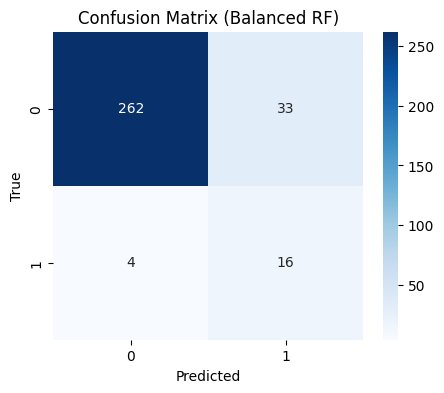

In [414]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# MODELLO BASE
# -----------------------------
brf = BalancedRandomForestClassifier(random_state=42)

# -----------------------------
# PARAM GRID PER GRIDSEARCH
# -----------------------------
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# -----------------------------
# CROSS-VALIDATION
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

# -----------------------------
# GRIDSEARCHCV
# -----------------------------
grid_search = GridSearchCV(
    estimator=brf,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

# -----------------------------
# FIT GRIDSEARCH
# -----------------------------
grid_search.fit(X_train, y_train)
best_brf = grid_search.best_estimator_
print("Best Hyper-parameters (BalancedRF):", grid_search.best_params_)

# -----------------------------
# PREDIZIONI SUL TEST SET
# -----------------------------
y_pred = best_brf.predict(X_test)

# -----------------------------
# FUNZIONE DI VALUTAZIONE CON BOOTSTRAP
# -----------------------------
def evaluate_classification_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    f2 = fbeta_score(y_true, y_pred, beta=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    # Bootstrap
    f2_boot, balacc_boot = [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        f2_boot.append(fbeta_score(y_true_sample, y_pred_sample, beta=2))
        balacc_boot.append(balanced_accuracy_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    f2_ci = np.percentile(f2_boot, [lower, upper])
    balacc_ci = np.percentile(balacc_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  F2-score           = {f2:.4f}  [{f2_ci[0]:.4f}, {f2_ci[1]:.4f}]")
    print(f"  Balanced Accuracy  = {bal_acc:.4f}  [{balacc_ci[0]:.4f}, {balacc_ci[1]:.4f}]")

    return {
        'F2': f2, 'F2_CI': f2_ci,
        'Balanced_Accuracy': bal_acc, 'Balanced_Accuracy_CI': balacc_ci
    }

# -----------------------------
# VALUTAZIONE FINALE
# -----------------------------
results = evaluate_classification_with_ci(y_test, y_pred, "Balanced Random Forest + GridSearchCV")

# -----------------------------
# CLASSIFICATION REPORT E CONFUSION MATRIX
# -----------------------------
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

# -----------------------------
# GRAFICO CONFUSION MATRIX
# -----------------------------
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Balanced RF)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


### UNDERSAMPLING

In [416]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss,
    EditedNearestNeighbours, TomekLinks,
    ClusterCentroids
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np
import pandas as pd

# -----------------------------
# SCORERS
# -----------------------------
f2_scorer = make_scorer(fbeta_score, beta=2)
balacc_scorer = make_scorer(balanced_accuracy_score)

# -----------------------------
# UNDERSAMPLING METHODS
# -----------------------------
methods = {
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss_v1": NearMiss(version=1),
    "NearMiss_v2": NearMiss(version=2),
    "NearMiss_v3": NearMiss(version=3),
    "EditedNearestNeighbours": EditedNearestNeighbours(),
    "TomekLinks": TomekLinks(),
    "ClusterCentroids": ClusterCentroids(random_state=42)
}

# -----------------------------
# PARAM GRID RF
# -----------------------------
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

# -----------------------------
# CROSS-VALIDATION
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# FUNZIONE VALUTAZIONE CON BOOTSTRAP
# -----------------------------
def evaluate_classification_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    f2 = fbeta_score(y_true, y_pred, beta=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    # Bootstrap
    f2_boot, balacc_boot = [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        f2_boot.append(fbeta_score(y_true_sample, y_pred_sample, beta=2))
        balacc_boot.append(balanced_accuracy_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    f2_ci = np.percentile(f2_boot, [lower, upper])
    balacc_ci = np.percentile(balacc_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  F2-score           = {f2:.4f}  [{f2_ci[0]:.4f}, {f2_ci[1]:.4f}]")
    print(f"  Balanced Accuracy  = {bal_acc:.4f}  [{balacc_ci[0]:.4f}, {balacc_ci[1]:.4f}]")

    return {
        'F2': f2, 'F2_CI': f2_ci,
        'Balanced_Accuracy': bal_acc, 'Balanced_Accuracy_CI': balacc_ci
    }

# -----------------------------
# LOOP SUI METODI DI UNDERSAMPLING
# -----------------------------
results = []

for name, sampler in methods.items():
    print(f"\n--- Esecuzione GridSearch per {name} ---")
    
    pipeline = Pipeline([
        ('under', sampler),
        ('model', RandomForestClassifier(random_state=42))
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring=f2_scorer,
        n_jobs=-1
    )
    
    grid_search.fit(X_train_clean, y_train_clean)
    best_pipeline = grid_search.best_estimator_
    
    print("Best params:", grid_search.best_params_)
    
    y_pred = best_pipeline.predict(X_test_clean)
    metrics = evaluate_classification_with_ci(y_test_clean, y_pred, f"{name} + GridSearchCV")
    
    results.append({
        "Method": name,
        "F2": metrics['F2'],
        "F2_CI": metrics['F2_CI'],
        "Balanced_Accuracy": metrics['Balanced_Accuracy'],
        "Balanced_Accuracy_CI": metrics['Balanced_Accuracy_CI']
    })

# -----------------------------
# RISULTATI FINALI
# -----------------------------
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="F2", ascending=False)
print("\n===== RISULTATI FINALI =====\n")
print(df_results.to_string(index=False))



--- Esecuzione GridSearch per RandomUnderSampler ---
Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

RandomUnderSampler + GridSearchCV Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4808  [0.3383, 0.6039]
  Balanced Accuracy  = 0.7871  [0.7130, 0.8442]

--- Esecuzione GridSearch per NearMiss_v1 ---
Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}

NearMiss_v1 + GridSearchCV Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.3476  [0.2096, 0.4737]
  Balanced Accuracy  = 0.6468  [0.5333, 0.7394]

--- Esecuzione GridSearch per NearMiss_v2 ---
Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}

NearMiss_v2 + GridSearchCV Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score       

## LightGBM

In [80]:
import re

def clean_colname(col):
    # conserva solo lettere, numeri e underscore
    return re.sub(r'[^A-Za-z0-9_]+', '_', col)

X_train = X_train.rename(columns=lambda c: clean_colname(c))
X_test = X_test.rename(columns=lambda c: clean_colname(c))

categorical_features = [clean_colname(c) for c in categorical_features]

# CATEGORICAL INDICES
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]

import re

def clean_column_name(col):
    col = col.strip()
    col = re.sub(r'[^A-Za-z0-9_]', '_', col)  # sostituisce caratteri non validi
    col = re.sub(r'_+', '_', col)             # riduce i doppi/tripli _
    return col

X_train_clean = X_train_clean.rename(columns=lambda c: clean_column_name(c))
X_test_clean = X_test_clean.rename(columns=lambda c: clean_column_name(c))



### OVERSAMPLING

#### SMOTENC

In [418]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np

# -----------------------------
# CATEGORICAL FEATURES
# -----------------------------
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]

# -----------------------------
# SMOTENC
# -----------------------------
smote = SMOTENC(categorical_features=cat_idx, random_state=42)

# -----------------------------
# MODELLO LIGHTGBM
# -----------------------------
lgb = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    random_state=42,
    n_estimators=200  # default, sarà ottimizzato
)

pipeline = Pipeline([
    ('smote', smote),
    ('model', lgb)
])

# -----------------------------
# GRIDSEARCH
# -----------------------------
param_grid = {
    'model__n_estimators': [200, 400],
    'model__num_leaves': [31, 63, 127],
    'model__max_depth': [-1, 10, 20],
    'model__learning_rate': [0.1, 0.05],
    'model__min_child_samples': [20, 40],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_lgb_smote = grid_search.best_estimator_

print("Best Hyper-parameters:", grid_search.best_params_)

# -----------------------------
# PREDIZIONI
# -----------------------------
y_pred = best_lgb_smote.predict(X_test)

results = evaluate_classification_with_ci(
    y_test, y_pred,
    "LightGBM + SMOTENC"
)


[LightGBM] [Info] Number of positive: 1183, number of negative: 1183
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,050780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1832
[LightGBM] [Info] Number of data points in the train set: 2366, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,500000 -> initscore=0,000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

#### Class weight balanced

In [419]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score

lgb_balanced = LGBMClassifier(
    class_weight="balanced",
    objective="binary",
    random_state=42
)

param_grid = {
    'n_estimators': [200, 400],
    'num_leaves': [31, 63, 127],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.1, 0.05],
    'min_child_samples': [20, 40],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=lgb_balanced,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_lgb_balanced = grid_search.best_estimator_

print("Best Hyper-parameters:", grid_search.best_params_)

y_pred = best_lgb_balanced.predict(X_test)

results = evaluate_classification_with_ci(
    y_test, y_pred,
    "LightGBM (class_weight balanced)"
)


[LightGBM] [Info] Number of positive: 74, number of negative: 1183
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,038886 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 433
[LightGBM] [Info] Number of data points in the train set: 1257, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,500000 -> initscore=0,000000
[LightGBM] [Info] Start training from score 0,000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


#### SCALE POS 

In [420]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np

# -----------------------------
# CALCOLO scale_pos_weight
# -----------------------------
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / n_pos

print("scale_pos_weight =", scale_pos_weight)

# -----------------------------
# MODELLO BASE
# -----------------------------
lgb = LGBMClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,   # <--- gestione sbilanciamento
    class_weight=None                    # <--- EVITARE di usarlo insieme
)

# -----------------------------
# GRIDSEARCH
# -----------------------------
param_grid = {
    "num_leaves": [31, 50, 70],
    "max_depth": [-1, 5, 10],
    "learning_rate": [0.1, 0.05, 0.01],
    "n_estimators": [200, 400, 800]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=lgb,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1,
    verbose=1
)

# -----------------------------
# FIT GRIDSEARCH
# -----------------------------
grid_search.fit(X_train, y_train)

best_lgbm = grid_search.best_estimator_
print("\nBest params:", grid_search.best_params_)

y_pred = best_lgbm.predict(X_test)

results = evaluate_classification_with_ci(
    y_test, y_pred,
    "LightGBM (scale_pos_weight)"
)


scale_pos_weight = 15.986486486486486
Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Info] Number of positive: 74, number of negative: 1183
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,064916 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 451
[LightGBM] [Info] Number of data points in the train set: 1257, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,058870 -> initscore=-2,771744
[LightGBM] [Info] Start training from score -2,771744
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

### UNDERSAMPLING

In [430]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss,
    EditedNearestNeighbours, TomekLinks,
    ClusterCentroids
)
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np
import pandas as pd

# -----------------------------
# SCORERS
# -----------------------------
f2_scorer = make_scorer(fbeta_score, beta=2)

# -----------------------------
# UNDERSAMPLING METHODS
# -----------------------------
methods = {
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss_v1": NearMiss(version=1),
    "NearMiss_v2": NearMiss(version=2),
    "NearMiss_v3": NearMiss(version=3),
    "EditedNearestNeighbours": EditedNearestNeighbours(),
    "TomekLinks": TomekLinks(),
    "ClusterCentroids": ClusterCentroids(random_state=42)
}

# -----------------------------
# GRID PARAMS FOR LGBM
# -----------------------------
param_grid = {
    'model__n_estimators': [200],
    'model__num_leaves': [31, 63],
    'model__max_depth': [-1, 10],
    'model__learning_rate': [0.1, 0.05],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, sampler in methods.items():
    print(f"\n--- GridSearch LGBM + {name} ---")

    pipeline = Pipeline([
        ('under', sampler),
        ('model', LGBMClassifier(
            objective="binary",
            random_state=42
        ))
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=f2_scorer,
        cv=cv,
        n_jobs=-1
    )

    grid_search.fit(X_train_clean, y_train_clean)

    y_pred = grid_search.best_estimator_.predict(X_test_clean)

    metrics = evaluate_classification_with_ci(
        y_test_clean, y_pred,
        f"LGBM + {name}"
    )

    results.append({
        "Method": name,
        "F2": metrics["F2"],
        "F2_CI": metrics["F2_CI"],
        "Balanced_Accuracy": metrics["Balanced_Accuracy"],
        "Balanced_Accuracy_CI": metrics["Balanced_Accuracy_CI"]
    })

df_results = pd.DataFrame(results).sort_values(by="F2", ascending=False)
print(df_results.to_string(index=False))



--- GridSearch LGBM + RandomUnderSampler ---


[LightGBM] [Info] Number of positive: 62, number of negative: 62
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,025242 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 200
[LightGBM] [Info] Number of data points in the train set: 124, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,500000 -> initscore=0,000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

## DECISION TREE

### OVERSAMPLING

#### SMOTENC

In [431]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np

# Indici delle variabili categoriche
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]

# Pipeline
smote = SMOTENC(categorical_features=cat_idx, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

pipeline = Pipeline([
    ('smote', smote),
    ('model', dt)
])

# GridSearch parameters
param_grid = {
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_pipeline = grid_search.best_estimator_

print("Best Hyper-parameters:", grid_search.best_params_)

y_pred = best_pipeline.predict(X_test)

results = evaluate_classification_with_ci(
    y_test, y_pred, "Decision Tree + SMOTENC (GridSearchCV)"
)


Best Hyper-parameters: {'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Decision Tree + SMOTENC (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.3226  [0.1456, 0.4963]
  Balanced Accuracy  = 0.6390  [0.5344, 0.7551]


#### CLASS weight BALANCED

In [432]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score

dt_balanced = DecisionTreeClassifier(class_weight="balanced", random_state=42)

param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=dt_balanced,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_dt = grid_search.best_estimator_

print("Best Hyper-parameters:", grid_search.best_params_)

y_pred = best_dt.predict(X_test)

results = evaluate_classification_with_ci(
    y_test, y_pred, "Decision Tree (class_weight='balanced')"
)


Best Hyper-parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

Decision Tree (class_weight='balanced') Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4965  [0.3101, 0.6419]
  Balanced Accuracy  = 0.7703  [0.6486, 0.8691]


#### Balanced Bagging

In [433]:
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score

bbc = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

param_grid = {
    'n_estimators': [50, 100, 200],
    'estimator__max_depth': [None, 5, 10, 20],
    'estimator__min_samples_split': [2, 5],
    'estimator__min_samples_leaf': [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=bbc,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_bbc = grid_search.best_estimator_
print("Best params:", grid_search.best_params_)

y_pred = best_bbc.predict(X_test)

results = evaluate_classification_with_ci(
    y_test, y_pred, "Balanced Bagging + DT"
)


Best params: {'estimator__max_depth': None, 'estimator__min_samples_leaf': 2, 'estimator__min_samples_split': 2, 'n_estimators': 200}

Balanced Bagging + DT Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.6061  [0.4296, 0.7394]
  Balanced Accuracy  = 0.8390  [0.7303, 0.9204]


### UNDERSAMPLING

In [435]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss,
    EditedNearestNeighbours, TomekLinks,
    ClusterCentroids
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np
import pandas as pd

f2_scorer = make_scorer(fbeta_score, beta=2)

methods = {
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss_v1": NearMiss(version=1),
    "NearMiss_v2": NearMiss(version=2),
    "NearMiss_v3": NearMiss(version=3),
    "EditedNearestNeighbours": EditedNearestNeighbours(),
    "TomekLinks": TomekLinks(),
    "ClusterCentroids": ClusterCentroids(random_state=42)
}

param_grid = {
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, sampler in methods.items():
    print(f"\n--- Esecuzione GridSearch per {name} ---")
    
    pipeline = Pipeline([
        ('under', sampler),
        ('model', DecisionTreeClassifier(random_state=42))
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring=f2_scorer,
        n_jobs=-1
    )
    
    grid_search.fit(X_train_clean, y_train_clean)
    best_pipeline = grid_search.best_estimator_

    print("Best params:", grid_search.best_params_)
    
    y_pred = best_pipeline.predict(X_test_clean)
    metrics = evaluate_classification_with_ci(
        y_test_clean, y_pred, f"{name} + DecisionTree + GridSearchCV"
    )
    
    results.append({
        "Method": name,
        "F2": metrics['F2'],
        "Balanced_Accuracy": metrics['Balanced_Accuracy']
    })

df_results = pd.DataFrame(results).sort_values(by="F2", ascending=False)
print("\n===== RISULTATI FINALI =====\n")
print(df_results)



--- Esecuzione GridSearch per RandomUnderSampler ---
Best params: {'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10}

RandomUnderSampler + DecisionTree + GridSearchCV Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4580  [0.2804, 0.6061]
  Balanced Accuracy  = 0.7453  [0.6204, 0.8565]

--- Esecuzione GridSearch per NearMiss_v1 ---
Best params: {'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}

NearMiss_v1 + DecisionTree + GridSearchCV Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.2941  [0.1402, 0.4422]
  Balanced Accuracy  = 0.5991  [0.4773, 0.7236]

--- Esecuzione GridSearch per NearMiss_v2 ---
Best params: {'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

NearMiss_v2 + DecisionTree + GridSearchCV Performance sul

## SVM

### OVER

#### SMOTENC

In [437]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
import numpy as np

# -----------------------------
# CATEGORICAL INDICES
# -----------------------------
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]

# -----------------------------
# PIPELINE
# -----------------------------
pipeline = Pipeline([
    ('smote', SMOTENC(categorical_features=cat_idx, random_state=42)),
    ('scaler', StandardScaler(with_mean=False)),   # SVC vuole dati scalati
    ('model', SVC(probability=True, class_weight=None, random_state=42))
])

# -----------------------------
# GRIDSEARCH PARAMS (SVC)
# -----------------------------
param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear'],
    'model__gamma': ['scale', 'auto']
}

# -----------------------------
# CROSS VALIDATION
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

# -----------------------------
# GRIDSEARCHCV
# -----------------------------
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

grid_search.fit(X_train_clean, y_train_clean)

best_pipeline = grid_search.best_estimator_
print("Best Params (SVC + SMOTENC):", grid_search.best_params_)

# -----------------------------
# PREDIZIONI
# -----------------------------
y_pred = best_pipeline.predict(X_test_clean)

# RIUTILIZZI la tua evaluate_classification_with_ci()
results = evaluate_classification_with_ci(
    y_test_clean, y_pred, "SVC + SMOTENC (GridSearchCV)"
)


Best Params (SVC + SMOTENC): {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

SVC + SMOTENC (GridSearchCV) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.2907  [0.0769, 0.4902]
  Balanced Accuracy  = 0.6162  [0.5044, 0.7414]


#### Class weight balanced

In [438]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score
import numpy as np

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(class_weight="balanced", probability=True, random_state=42))
])

param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear'],
    'model__gamma': ['scale', 'auto']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f2_scorer = make_scorer(fbeta_score, beta=2)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train_clean, y_train_clean)
best_svc = grid_search.best_estimator_
print("Best Params (SVC balanced):", grid_search.best_params_)

y_pred = best_svc.predict(X_test_clean)

results = evaluate_classification_with_ci(
    y_test_clean, y_pred, "SVC (class_weight=balanced)"
)


Best Params (SVC balanced): {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

SVC (class_weight=balanced) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.5607  [0.3762, 0.7143]
  Balanced Accuracy  = 0.8019  [0.6880, 0.9044]


### UNDER

In [439]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss,
    EditedNearestNeighbours, TomekLinks,
    ClusterCentroids
)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score
import numpy as np
import pandas as pd

# -----------------------------
# SCORER
# -----------------------------
f2_scorer = make_scorer(fbeta_score, beta=2)

# -----------------------------
# UNDERSAMPLING METHODS
# -----------------------------
methods = {
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss_v1": NearMiss(version=1),
    "NearMiss_v2": NearMiss(version=2),
    "NearMiss_v3": NearMiss(version=3),
    "EditedNearestNeighbours": EditedNearestNeighbours(),
    "TomekLinks": TomekLinks(),
    "ClusterCentroids": ClusterCentroids(random_state=42)
}

# -----------------------------
# SVC PARAM GRID
# -----------------------------
param_grid = {
    'model__C': [0.1, 1],
    'model__kernel': ['rbf', 'linear'],
    'model__gamma': ['scale', 'auto']
}

# -----------------------------
# CV
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# LOOP SU TUTTI GLI UNDERSAMPLER
# -----------------------------
results = []
best_models = {}   # <-- per salvare il best_model per ogni metodo

for name, sampler in methods.items():
    print(f"\n--- Running {name} ---")

    pipeline = Pipeline([
        ('under', sampler),
        ('scaler', StandardScaler(with_mean=False)),
        ('model', SVC(probability=True, random_state=42))
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=f2_scorer,
        cv=cv,
        n_jobs=-1
    )

    grid_search.fit(X_train_clean, y_train_clean)

    # Salvo il modello migliore per questo metodo
    best_models[name] = grid_search.best_estimator_

    y_pred = grid_search.best_estimator_.predict(X_test_clean)

    metrics = evaluate_classification_with_ci(
        y_test_clean, y_pred, f"SVC + {name}"
    )

    # Salvo anche gli iperparametri migliori
    best_params = grid_search.best_params_

    results.append({
        "Method": name,
        "Best_Params": best_params,
        "F2": metrics["F2"],
        "Balanced_Accuracy": metrics["Balanced_Accuracy"],
        "F2_CI": metrics["F2_CI"],
        "Balanced_Accuracy_CI": metrics["Balanced_Accuracy_CI"]
    })

df_results = pd.DataFrame(results).sort_values("F2", ascending=False)
print(df_results)

# -----------------------------
# MODELLO MIGLIORE IN ASSOLUTO
# -----------------------------
best_row = df_results.iloc[0]
best_method = best_row["Method"]
best_model = best_models[best_method]

print("\nMIGLIOR MODELLO:")
print("Metodo di bilanciamento:", best_method)
print("Iperparametri migliori:", best_row["Best_Params"])



--- Running RandomUnderSampler ---

SVC + RandomUnderSampler Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4730  [0.3167, 0.6061]
  Balanced Accuracy  = 0.7724  [0.6782, 0.8521]

--- Running NearMiss_v1 ---

SVC + NearMiss_v1 Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.3704  [0.2095, 0.5076]
  Balanced Accuracy  = 0.6722  [0.5470, 0.7812]

--- Running NearMiss_v2 ---

SVC + NearMiss_v2 Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.3886  [0.2616, 0.5112]
  Balanced Accuracy  = 0.6999  [0.6302, 0.7570]

--- Running NearMiss_v3 ---

SVC + NearMiss_v3 Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4636  [0.3081, 0.5899]
  Balanced Accuracy  = 0.7653  [0.6672, 0.8413]

--- Running EditedNearestNeighbours ---

SVC + EditedNearestNeighbours Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.2027  [0.0000, 0.4348]
  Bal

## MLP

### OVER

#### SMOTENC

In [442]:
# =======================================
# IMPORT
# =======================================
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score, balanced_accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop
from scikeras.wrappers import KerasClassifier
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# =======================================
# FUNZIONE PER COSTRUIRE IL MODELLO MLP
# =======================================
def build_mlp(n_hidden=2, n_neurons=64, dropout_rate=0.2, lr=0.001, optimizer='adam'):
    model = Sequential()
    model.add(Dense(n_neurons, input_dim=X_train.shape[1], activation='relu'))
    
    for _ in range(n_hidden - 1):
        model.add(Dense(n_neurons, activation='relu'))
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation='sigmoid'))  # classificazione binaria

    if optimizer == 'adam':
        opt = Adam(learning_rate=lr)
    else:
        opt = RMSprop(learning_rate=lr)
    
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# =======================================
# SMOTENC + KerasClassifier
# =======================================
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]
smote = SMOTENC(categorical_features=cat_idx, random_state=42)

keras_clf = KerasClassifier(
    model=build_mlp,
    n_hidden=2,
    n_neurons=64,
    dropout_rate=0.2,
    lr=0.001,
    optimizer='adam',
    batch_size=32,
    epochs=50,
    verbose=0
)

pipeline = Pipeline([
    ('smote', smote),
    ('model', keras_clf)
])

param_grid = {
    "model__n_hidden": [1, 2],
    "model__n_neurons": [32, 64],
    "model__dropout_rate": [0.0, 0.2],
    "model__lr": [0.001, 0.0005],
    "model__optimizer": ['adam', 'rmsprop'],
    "model__batch_size": [16, 32],
    "model__epochs": [50, 100]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)


grid_search.fit(X_train_clean, y_train_clean)
best_pipeline = grid_search.best_estimator_
print("Best Hyper-parameters (SMOTENC):", grid_search.best_params_)

y_pred = best_pipeline.predict(X_test_clean)

# =======================================
# FUNZIONE VALUTAZIONE
# =======================================
def evaluate_classification_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    f2 = fbeta_score(y_true, y_pred, beta=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    f2_boot, balacc_boot = [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        f2_boot.append(fbeta_score(y_true[idx], y_pred[idx], beta=2))
        balacc_boot.append(balanced_accuracy_score(y_true[idx], y_pred[idx]))

    lower = (100 - ci) / 2
    upper = 100 - lower
    f2_ci = np.percentile(f2_boot, [lower, upper])
    balacc_ci = np.percentile(balacc_boot, [lower, upper])

    print(f"\n{name} Performance sul test set:")
    print(f"  F2-score           = {f2:.4f}  [{f2_ci[0]:.4f}, {f2_ci[1]:.4f}]")
    print(f"  Balanced Accuracy  = {bal_acc:.4f}  [{balacc_ci[0]:.4f}, {balacc_ci[1]:.4f}]")

evaluate_classification_with_ci(y_test_clean, y_pred, "MLP + SMOTENC")


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best Hyper-parameters (SMOTENC): {'model__batch_size': 32, 'model__dropout_rate': 0.0, 'model__epochs': 50, 'model__lr': 0.0005, 'model__n_hidden': 1, 'model__n_neurons': 32, 'model__optimizer': 'rmsprop'}

MLP + SMOTENC Performance sul test set:
  F2-score           = 0.2469  [0.0568, 0.4630]
  Balanced Accuracy  = 0.5943  [0.4920, 0.7182]


#### Class weight Balanced

In [443]:
from sklearn.utils.class_weight import compute_class_weight

# Calcolo dei pesi di classe
classes = np.unique(y_train_clean)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_clean)
class_weight_dict = dict(zip(classes, class_weights))

# Wrapper SciKeras
keras_clf = KerasClassifier(model=build_mlp, verbose=0)

# Parametri per GridSearchCV
# NOTA: i parametri del modello iniziano con "model__"
# mentre batch_size ed epochs restano senza prefisso
param_grid = {
    "model__n_hidden": [1, 2],
    "model__n_neurons": [32, 64],
    "model__dropout_rate": [0.0, 0.2],
    "model__lr": [0.001, 0.0005],
    "model__optimizer": ['adam', 'rmsprop'],
    "batch_size": [16, 32],   # <-- corretto
    "epochs": [50, 100]       # <-- corretto
}

# Grid Search
grid_search = GridSearchCV(
    estimator=keras_clf,
    param_grid=param_grid,
    cv=cv,
    scoring=f2_scorer,
    n_jobs=-1
)

# class_weight si passa direttamente al fit
grid_search.fit(X_train_clean, y_train_clean, class_weight=class_weight_dict)

# Miglior modello trovato
best_model = grid_search.best_estimator_
print("Best Hyper-parameters (Class Weight):", grid_search.best_params_)

# Predizione e valutazione finale
y_pred = best_model.predict(X_test_clean)
evaluate_classification_with_ci(y_test_clean, y_pred, "MLP + Class Weight Bilanciato")


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Best Hyper-parameters (Class Weight): {'batch_size': 32, 'epochs': 50, 'model__dropout_rate': 0.2, 'model__lr': 0.0005, 'model__n_hidden': 1, 'model__n_neurons': 64, 'model__optimizer': 'rmsprop'}

MLP + Class Weight Bilanciato Performance sul test set:
  F2-score           = 0.5607  [0.3659, 0.7192]
  Balanced Accuracy  = 0.8019  [0.6852, 0.9081]


### UNDER

In [444]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import (
    RandomUnderSampler, NearMiss,
    EditedNearestNeighbours, TomekLinks,
    ClusterCentroids
)
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score
import pandas as pd
import numpy as np
from scikeras.wrappers import KerasClassifier

f2_scorer = make_scorer(fbeta_score, beta=2)
def evaluate_classification_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    f2 = fbeta_score(y_true, y_pred, beta=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    f2_boot, balacc_boot = [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        f2_boot.append(fbeta_score(y_true[idx], y_pred[idx], beta=2))
        balacc_boot.append(balanced_accuracy_score(y_true[idx], y_pred[idx]))

    lower = (100 - ci) / 2
    upper = 100 - lower
    f2_ci = np.percentile(f2_boot, [lower, upper])
    balacc_ci = np.percentile(balacc_boot, [lower, upper])

    print(f"\n{name} Performance sul test set:")
    print(f"  F2-score           = {f2:.4f}  [{f2_ci[0]:.4f}, {f2_ci[1]:.4f}]")
    print(f"  Balanced Accuracy  = {bal_acc:.4f}  [{balacc_ci[0]:.4f}, {balacc_ci[1]:.4f}]")

    # ✅ RITORNO LE METRICHE
    return {
        "F2": f2,
        "F2_CI": f2_ci,
        "Balanced_Accuracy": bal_acc,
        "Balanced_Accuracy_CI": balacc_ci
    }

# 🔥 Stessi metodi del tuo primo codice
methods = {
    "RandomUnderSampler": RandomUnderSampler(random_state=42),
    "NearMiss_v1": NearMiss(version=1),
    "NearMiss_v2": NearMiss(version=2),
    "NearMiss_v3": NearMiss(version=3),
    "EditedNearestNeighbours": EditedNearestNeighbours(),
    "TomekLinks": TomekLinks(),
    "ClusterCentroids": ClusterCentroids(random_state=42)
}

# 🔥 Parametri della pipeline corretti
param_grid = {
    # Parametri della funzione build_mlp
    "model__model__n_hidden": [1, 2],
    "model__model__n_neurons": [32, 64],
    "model__model__dropout_rate": [0.0, 0.2],
    "model__model__lr": [0.001, 0.0005],
    "model__model__optimizer": ['adam', 'rmsprop'],

    # Parametri del KerasClassifier
    "model__batch_size": [16, 32],
    "model__epochs": [50, 100]
}

results = []

for name, sampler in methods.items():
    print(f"\n--- GridSearch per {name} ---")

    keras_clf = KerasClassifier(model=build_mlp, verbose=1)

    pipeline = Pipeline([
        ("under", sampler),
        ("model", keras_clf)
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,                 # stesso StratifiedKFold del tuo primo codice
        scoring=f2_scorer,
        n_jobs=-1
    )

    grid_search.fit(X_train_clean, y_train_clean)
    best_pipeline = grid_search.best_estimator_

    print("Best params:", grid_search.best_params_)

    y_pred = best_pipeline.predict(X_test_clean)
    metrics = evaluate_classification_with_ci(
        y_test_clean, y_pred, f"MLP + {name}"
    )

    results.append({
        "Method": name,
        "F2": metrics["F2"],
        "Balanced_Accuracy": metrics["Balanced_Accuracy"]
    })

# 🔥 Risultati finali ordinati per F2
df_results = pd.DataFrame(results).sort_values(by="F2", ascending=False)
print("\n===== RISULTATI FINALI =====\n")
print(df_results)


--- GridSearch per RandomUnderSampler ---


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.3960 - loss: 0.7705
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4497 - loss: 0.7469 
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4529 - loss: 0.7272 
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4773 - loss: 0.7091 
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5101 - loss: 0.6921 
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5081 - loss: 0.6761 
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5996 - loss: 0.6610 
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6164 - loss: 0.6467 
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6545 - loss: 0.6331 
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6977 - loss: 0.6201 
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7124 - loss: 0.6077 
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0

c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.4372 - loss: 0.7111
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5814 - loss: 0.6836 
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6225 - loss: 0.6662 
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6668 - loss: 0.6520 
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6669 - loss: 0.6397 
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6700 - loss: 0.6286 
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7026 - loss: 0.6182 
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7120 - loss: 0.6083 
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7395 - loss: 0.5987 
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7689 - loss: 0.5895 
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7848 - loss: 0.5807 
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7932 - loss

c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Epoch 1/50


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4918 - loss: 0.7087
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5425 - loss: 0.6780 
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6497 - loss: 0.6538 
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7002 - loss: 0.6328 
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7246 - loss: 0.6140 
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7753 - loss: 0.5973 
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7723 - loss: 0.5824 
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7902 - loss: 0.5686 
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7955 - loss: 0.5557 
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8155 - loss: 0.5435
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8187 - loss: 0.5321 
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8187 - loss: 0.5213
Epo

c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Epoch 1/50


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6522 - loss: 0.6750
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7091 - loss: 0.6372 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7335 - loss: 0.6120 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7208 - loss: 0.5910 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7504 - loss: 0.5725 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7631 - loss: 0.5563 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7829 - loss: 0.5419 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7869 - loss: 0.5289 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7473 - loss: 0.5172 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7473 - loss: 0.5065 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7473 - loss: 0.4962 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7491 - loss: 0.4864 
E

c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8392 - loss: 0.4989
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9257 - loss: 0.2337
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9257 - loss: 0.2116
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9257 - loss: 0.1944
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9266 - loss: 0.1809
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9276 - loss: 0.1690
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9436 - loss: 0.1579
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9499 - loss: 0.1479
Epoch 9/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9511 - loss: 0.1392
Epoch 10/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9536 - loss: 0.1304
Epoch 11/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9551 - loss: 0.1220
Epoch 12/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy:

c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6366 - loss: 0.6095
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9312 - loss: 0.2499
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9312 - loss: 0.2275
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9312 - loss: 0.2122
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9312 - loss: 0.2111
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9312 - loss: 0.1945
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9312 - loss: 0.1979
Epoch 8/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9312 - loss: 0.1824
Epoch 9/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9312 - loss: 0.1775
Epoch 10/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9322 - loss: 0.1760
Epoch 11/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9322 - loss: 0.1676
Epoch 12/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy:

c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Epoch 1/50


c:\Users\fccat\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5125 - loss: 0.7892
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5125 - loss: 0.7712 
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5125 - loss: 0.7551 
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5125 - loss: 0.7401 
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4978 - loss: 0.7261 
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5178 - loss: 0.7131 
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5378 - loss: 0.7009 
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5410 - loss: 0.6896 
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5548 - loss: 0.6790 
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5918 - loss: 0.6689 
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5951 - loss: 0.6591 
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6225 - loss: 0.6497 
E

## TEST tra modelli

### LOGREG

In [77]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------
# 1. INDICI DELLE FEATURES CATEGORICALI
# -----------------------------------------------------
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]

# -----------------------------------------------------
# 2. COSTRUZIONE MODELLO CON PARAMETRI OTTIMALI
# -----------------------------------------------------
smote = SMOTENC(
    categorical_features=cat_idx,
    random_state=42
)

logreg = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    max_iter=500,
    C=0.01,            # ← miglior valore
    class_weight=None  # ← miglior valore
)

# **NOME CHIARO DEL MODELLO**
LogReg_SMOTENC_C001 = Pipeline([
    ('smote', smote),
    ('model', logreg)
])

# -----------------------------------------------------
# 3. TRAIN
# -----------------------------------------------------
LogReg_SMOTENC_C001.fit(X_train_clean, y_train_clean)

# -----------------------------------------------------
# 4. PREDIZIONI
# -----------------------------------------------------
y_pred_logreg = LogReg_SMOTENC_C001.predict(X_test_clean)

# -----------------------------------------------------
# 5. VALUTAZIONE
# -----------------------------------------------------
results = evaluate_classification_with_ci(
    y_test_clean, y_pred_logreg,
    "LogReg + SMOTENC (C=0.01)"
)



LogReg + SMOTENC (C=0.01) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.5046  [0.3191, 0.6594]
  Balanced Accuracy  = 0.7636  [0.6536, 0.8808]


### RF

In [78]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score, balanced_accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------
# 1. COSTRUZIONE DEL MODELLO CON PARAMETRI SPECIFICI
# -----------------------------------------------------
BalancedRF_n300_split5_leaf1 = BalancedRandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=1,
    random_state=42
)

# -----------------------------------------------------
# 2. FIT SUI DATI DI TRAIN
# -----------------------------------------------------
BalancedRF_n300_split5_leaf1.fit(X_train, y_train)

# -----------------------------------------------------
# 3. PREDIZIONI SUL TEST SET
# -----------------------------------------------------
y_pred_brf = BalancedRF_n300_split5_leaf1.predict(X_test)

# -----------------------------------------------------
# 4. FUNZIONE DI VALUTAZIONE CON BOOTSTRAP
# -----------------------------------------------------
def evaluate_classification_with_ci(y_true, y_pred, name, n_bootstrap=1000, ci=95):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    rng = np.random.default_rng(42)
    n = len(y_true)

    f2 = fbeta_score(y_true, y_pred, beta=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    # Bootstrap
    f2_boot, balacc_boot = [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        y_true_sample = y_true[idx]
        y_pred_sample = y_pred[idx]
        f2_boot.append(fbeta_score(y_true_sample, y_pred_sample, beta=2))
        balacc_boot.append(balanced_accuracy_score(y_true_sample, y_pred_sample))

    lower = (100 - ci) / 2
    upper = 100 - lower
    f2_ci = np.percentile(f2_boot, [lower, upper])
    balacc_ci = np.percentile(balacc_boot, [lower, upper])

    print(f"\n{name} Performance sul test set (con {ci}% CI bootstrap, n={n_bootstrap}):")
    print(f"  F2-score           = {f2:.4f}  [{f2_ci[0]:.4f}, {f2_ci[1]:.4f}]")
    print(f"  Balanced Accuracy  = {bal_acc:.4f}  [{balacc_ci[0]:.4f}, {balacc_ci[1]:.4f}]")

    return {
        'F2': f2, 'F2_CI': f2_ci,
        'Balanced_Accuracy': bal_acc, 'Balanced_Accuracy_CI': balacc_ci
    }

# -----------------------------------------------------
# 5. VALUTAZIONE FINALE
# -----------------------------------------------------
results = evaluate_classification_with_ci(y_test, y_pred_brf, "Balanced Random Forest (n300, split5, leaf1)")

# -----------------------------------------------------
# 6. CLASSIFICATION REPORT E CONFUSION MATRIX
# -----------------------------------------------------
print("\nClassification report:\n", classification_report(y_test, y_pred_brf, digits=4))
cm = confusion_matrix(y_test, y_pred_brf)
print("Confusion matrix:\n", cm)




Balanced Random Forest (n300, split5, leaf1) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.6202  [0.4301, 0.7566]
  Balanced Accuracy  = 0.8441  [0.7342, 0.9270]

Classification report:
               precision    recall  f1-score   support

           0     0.9850    0.8881    0.9340       295
           1     0.3265    0.8000    0.4638        20

    accuracy                         0.8825       315
   macro avg     0.6557    0.8441    0.6989       315
weighted avg     0.9432    0.8825    0.9042       315

Confusion matrix:
 [[262  33]
 [  4  16]]


### LightGBM

In [ ]:
import re

def clean_colname(col):
    # conserva solo lettere, numeri e underscore
    return re.sub(r'[^A-Za-z0-9_]+', '_', col)

X_train = X_train.rename(columns=lambda c: clean_colname(c))
X_test = X_test.rename(columns=lambda c: clean_colname(c))

categorical_features = [clean_colname(c) for c in categorical_features]

# CATEGORICAL INDICES
cat_idx = [X_train.columns.get_loc(col) for col in categorical_features]

import re

def clean_column_name(col):
    col = col.strip()
    col = re.sub(r'[^A-Za-z0-9_]', '_', col)  # sostituisce caratteri non validi
    col = re.sub(r'_+', '_', col)             # riduce i doppi/tripli _
    return col

X_train_clean = X_train_clean.rename(columns=lambda c: clean_column_name(c))
X_test_clean = X_test_clean.rename(columns=lambda c: clean_column_name(c))



In [81]:
from lightgbm import LGBMClassifier

# -----------------------------------------------------
# 1. CALCOLO scale_pos_weight
# -----------------------------------------------------
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / n_pos

print("scale_pos_weight =", scale_pos_weight)

# -----------------------------------------------------
# 2. COSTRUZIONE MODELLO CON PARAMETRI SPECIFICI
# -----------------------------------------------------
LGBM_scalePW_n200_depth5_lr001_leaves31 = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.01,
    num_leaves=31,
    min_child_samples=None,
    random_state=42,
    scale_pos_weight=scale_pos_weight,  # gestione sbilanciamento
    class_weight=None                    # evitare insieme a scale_pos_weight
)

# -----------------------------------------------------
# 3. FIT SUI DATI DI TRAIN
# -----------------------------------------------------
LGBM_scalePW_n200_depth5_lr001_leaves31.fit(X_train, y_train)

# -----------------------------------------------------
# 4. PREDIZIONI SUL TEST SET
# -----------------------------------------------------
y_pred_lgb = LGBM_scalePW_n200_depth5_lr001_leaves31.predict(X_test)

# -----------------------------------------------------
# 5. VALUTAZIONE
# -----------------------------------------------------
results = evaluate_classification_with_ci(
    y_test, y_pred_lgb,
    "LightGBM (scale_pos_weight, n200, depth5, lr0.01, leaves31)"
)


scale_pos_weight = 15.986486486486486
[LightGBM] [Info] Number of positive: 74, number of negative: 1183
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001849 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 451
[LightGBM] [Info] Number of data points in the train set: 1257, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.058870 -> initscore=-2.771744
[LightGBM] [Info] Start training from score -2.771744
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

### DT

In [82]:
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# -----------------------------------------------------
# 1. COSTRUZIONE MODELLO CON PARAMETRI SPECIFICI
# -----------------------------------------------------
BalancedBagging_DT_n50_depth10 = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=2,
        random_state=42
    ),
    n_estimators=200,
    random_state=42
)

# -----------------------------------------------------
# 2. FIT SUI DATI DI TRAIN
# -----------------------------------------------------
BalancedBagging_DT_n50_depth10.fit(X_train, y_train)

# -----------------------------------------------------
# 3. PREDIZIONI SUL TEST SET
# -----------------------------------------------------
y_pred_dt = BalancedBagging_DT_n50_depth10.predict(X_test)

# -----------------------------------------------------
# 4. VALUTAZIONE
# -----------------------------------------------------
results = evaluate_classification_with_ci(
    y_test, y_pred_dt, "Balanced Bagging + DT (n50, depth10)"
)



Balanced Bagging + DT (n50, depth10) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.6061  [0.4296, 0.7394]
  Balanced Accuracy  = 0.8390  [0.7303, 0.9204]


### SVM

In [83]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------
# 1. DEFINIZIONE DEL MIGLIOR UNDERSAMPLER
# -----------------------------------------------------
best_sampler = RandomUnderSampler(random_state=42)

# -----------------------------------------------------
# 2. COSTRUZIONE PIPELINE CON I MIGLIORI IPERPARAMETRI
#    (kernel='rbf', C=0.1, gamma='scale')
# -----------------------------------------------------
Best_SVC_RandomUnderSampler = Pipeline([
    ('under', best_sampler),
    ('scaler', StandardScaler(with_mean=False)),
    ('model', SVC(
        kernel='rbf',
        C=0.1,
        gamma='scale',
        probability=True,
        random_state=42
    ))
])

# -----------------------------------------------------
# 3. FIT SUI DATI DI TRAIN
# -----------------------------------------------------
Best_SVC_RandomUnderSampler.fit(X_train_clean, y_train_clean)

# -----------------------------------------------------
# 4. PREDIZIONI SUL TEST SET
# -----------------------------------------------------
y_pred_best_svc = Best_SVC_RandomUnderSampler.predict(X_test_clean)

# -----------------------------------------------------
# 5. VALUTAZIONE FINALE
# -----------------------------------------------------
final_results = evaluate_classification_with_ci(
    y_test_clean,
    y_pred_best_svc,
    "SVC + RandomUnderSampler (rbf, C=0.1, gamma=scale)"
)

final_results



SVC + RandomUnderSampler (rbf, C=0.1, gamma=scale) Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4730  [0.3167, 0.6061]
  Balanced Accuracy  = 0.7724  [0.6782, 0.8521]


{'F2': 0.47297297297297297,
 'F2_CI': array([0.31672224, 0.60606061]),
 'Balanced_Accuracy': 0.7724056603773585,
 'Balanced_Accuracy_CI': array([0.67817692, 0.85212322])}

### MLP

In [ ]:
import numpy as np
import tensorflow as tf
import random
from sklearn.utils.class_weight import compute_class_weight
from scikeras.wrappers import KerasClassifier

# -------------------------
# 0. Fissiamo il seed
# -------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# -------------------------
# 1. Calcolo class weights
# -------------------------
classes = np.unique(y_train_clean)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_clean
)
class_weight_dict = dict(zip(classes, class_weights))

# -------------------------
# 2. Modello ottimizzato
# -------------------------
optimized_clf = KerasClassifier(
    model=build_mlp,
    model__n_hidden=1,
    model__n_neurons=64,
    model__dropout_rate=0.2,
    model__lr=0.0005,
    model__optimizer="rmsprop",
    batch_size=32,
    epochs=50,
    verbose=1,
    random_state=SEED
)

# -------------------------
# 3. Training
# -------------------------
optimized_clf.fit(
    X_train_clean,
    y_train_clean,
    class_weight=class_weight_dict
)

# -------------------------
# 4. Predizione e valutazione
# -------------------------
y_pred_mlp = optimized_clf.predict(X_test_clean)

evaluate_classification_with_ci(
    y_test_clean,
    y_pred_mlp,
    "Optimized MLP (best hyperparameters + fixed seed)"
)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8728 - loss: 0.7158
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8505 - loss: 0.6463
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8145 - loss: 0.6246
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7872 - loss: 0.6047
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8082 - loss: 0.5887
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7984 - loss: 0.5727
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7926 - loss: 0.5571
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8018 - loss: 0.5376
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8215 - loss: 0.5220
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7911 - loss: 0.5183
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8359 - loss: 0.5086
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8228

{'F2': 0.5714285714285714,
 'F2_CI': array([0.37488426, 0.73037133]),
 'Balanced_Accuracy': 0.8066037735849056,
 'Balanced_Accuracy_CI': array([0.68925107, 0.912712  ])}

### TEST

In [ ]:
from itertools import combinations
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

# ------------------------------------------------------
# 1. Accuracy per-sample per un modello
# ------------------------------------------------------
def compute_sample_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # OK: confrontiamo solo pred e true dello stesso modello
    return (y_pred == y_true).astype(float)

# ------------------------------------------------------
# 2. Confronto UNPAIRED tra due modelli
# ------------------------------------------------------
def compare_classifiers_unpaired(y_true1, y_pred1, y_true2, y_pred2):

    m1 = compute_sample_accuracy(y_true1, y_pred1)
    m2 = compute_sample_accuracy(y_true2, y_pred2)

    # Mann–Whitney U → funziona per vettori di lunghezza diversa
    stat, p_value = mannwhitneyu(m1, m2, alternative="two-sided")

    return stat, p_value

# ------------------------------------------------------
# 3. Confronto multiplo di tutti i modelli (pairwise)
# ------------------------------------------------------
def compare_multiple_classifiers_unpaired(y_tests_dict, predictions_dict,
                                          correction="fdr_bh"):

    results = []
    raw_pvals = []

    for (name1, y_pred1), (name2, y_pred2) in combinations(predictions_dict.items(), 2):

        y_true1 = y_tests_dict[name1]
        y_true2 = y_tests_dict[name2]

        stat, p_value = compare_classifiers_unpaired(
            y_true1, y_pred1, y_true2, y_pred2
        )

        results.append({
            "Model 1": name1,
            "Model 2": name2,
            "Statistic": stat,
            "Raw p-value": p_value
        })

        raw_pvals.append(p_value)

    # Correzione multipla (Benjamini-Hochberg)
    reject, corrected_pvals, _, _ = multipletests(raw_pvals, method=correction)

    for i, r in enumerate(results):
        r["Corrected p-value"] = corrected_pvals[i]
        r["Significant"] = reject[i]

    return pd.DataFrame(results)


# ------------------------------------------------------
# 4. Dizionari test set e predizioni
# ------------------------------------------------------
y_tests = {
    "LogReg": y_test_clean,
    "LightGBM": y_test,
    "RandomForest": y_test,
    "SVC": y_test_clean,
    "MLP": y_test_clean,
    "Decision Tree": y_test
}

predictions = {
    "LogReg": y_pred_logreg,
    "LightGBM": y_pred_lgb,
    "RandomForest": y_pred_brf,
    "SVC": y_pred_best_svc,
    "MLP": y_pred_mlp,
    "Decision Tree": y_pred_dt
}

# ------------------------------------------------------
# 5. Esecuzione confronti
# ------------------------------------------------------
results_df = compare_multiple_classifiers_unpaired(
    y_tests,
    predictions
)

print(results_df)


         Model 1        Model 2  Statistic   Raw p-value  Corrected p-value  \
0         LogReg       LightGBM    32959.5  4.104188e-03       1.026047e-02   
1         LogReg   RandomForest    33985.5  7.600022e-02       1.425004e-01   
2         LogReg            SVC    29754.0  3.224166e-04       9.672499e-04   
3         LogReg            MLP    25308.0  4.418080e-01       5.097784e-01   
4         LogReg  Decision Tree    34327.5  1.511092e-01       2.266638e-01   
5       LightGBM   RandomForest    51030.0  2.390254e-01       3.259438e-01   
6       LightGBM            SVC    44058.0  1.748999e-11       2.623499e-10   
7       LightGBM            MLP    37915.5  4.219669e-02       9.042148e-02   
8       LightGBM  Decision Tree    51502.5  1.237780e-01       2.062966e-01   
9   RandomForest            SVC    43032.0  1.279388e-08       9.595406e-08   
10  RandomForest            MLP    36889.5  3.499010e-01       4.373762e-01   
11  RandomForest  Decision Tree    50085.0  7.156843

In [ ]:
print("LUNGHEZZE Y_TEST:")
for name, arr in y_tests.items():
    print(f"{name}: {len(arr)}")

print("\nLUNGHEZZE PREDIZIONI:")
for name, arr in predictions.items():
    print(f"{name}: {len(arr)}")


LUNGHEZZE Y_TEST:
LogReg: 228
LightGBM: 315
RandomForest: 315
SVC: 228
MLP: 228
Decision Tree: 315

LUNGHEZZE PREDIZIONI:
LogReg: 228
LightGBM: 315
RandomForest: 315
SVC: 228
MLP: 228
Decision Tree: 315


### Ensemble

In [ ]:
from sklearn.ensemble import VotingClassifier
from itertools import combinations
import numpy as np


y_tests = {
    "LogReg": y_test_clean,
    "BalancedRF": y_test,            # corrisponde a BalancedRF
    "LightGBM": y_test,
    "BalancedBagging": y_test,       # corrisponde a BalancedBagging
    "SVC": y_test_clean
}

predictions = {
    "LogReg": y_pred_logreg,
    "BalancedRF": y_pred_brf,        # corrisponde a BalancedRF
    "LightGBM": y_pred_lgb,
    "BalancedBagging": y_pred_dt,    # oppure le predizioni del modello BalancedBagging
    "SVC": y_pred_best_svc
}

# ================================
# 1. DIZIONARIO DEI MODELLI
# ================================
models = {
    "LogReg": LogReg_SMOTENC_C001,
    "BalancedRF": BalancedRF_n300_split5_leaf1,
    "LightGBM": LGBM_scalePW_n200_depth5_lr001_leaves31,
    "BalancedBagging": BalancedBagging_DT_n50_depth10,
    "SVC": Best_SVC_RandomUnderSampler,
}

# ================================
# 2. GENERAZIONE DI TUTTE LE COMBINAZIONI
# ================================
all_combinations = []
model_names = list(models.keys())

for r in range(2, len(models) + 1):
    combos = list(combinations(model_names, r))
    all_combinations.extend(combos)

print(f"Numero totale ensemble: {len(all_combinations)}")

# ================================
# 3. LOOP DI VALUTAZIONE (senza fit)
# ================================
ensemble_results = {}

for combo in all_combinations:
    # Verifica che tutti i modelli nell'ensemble abbiano lo stesso test set
    test_lengths = [len(y_tests[model_name]) for model_name in combo]
    if len(set(test_lengths)) > 1:
        print(f"⚠️  Skipping ensemble {combo} (test set lengths differ)")
        continue

    name = "Ensemble [" + " + ".join(combo) + "]"
    
    # Ottieni le predizioni e il test set
    y_preds_combo = [predictions[model_name] for model_name in combo]
    y_tests_combo = y_tests[combo[0]]  # tutti hanno stesso test set

    # Media delle predizioni
    y_pred_ensemble = np.round(np.mean(y_preds_combo, axis=0)).astype(int)

    # Valutazione con CI
    res = evaluate_classification_with_ci(y_tests_combo, y_pred_ensemble, name)

    # Salvataggio
    ensemble_results[name] = res

print("\n\n⭐⭐ FINITO! Tutti gli ensemble validi sono stati valutati.")

Numero totale ensemble: 26
⚠️  Skipping ensemble ('LogReg', 'BalancedRF') (test set lengths differ)
⚠️  Skipping ensemble ('LogReg', 'LightGBM') (test set lengths differ)
⚠️  Skipping ensemble ('LogReg', 'BalancedBagging') (test set lengths differ)

Ensemble [LogReg + SVC] Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.4854  [0.2907, 0.6500]
  Balanced Accuracy  = 0.7441  [0.6249, 0.8625]

Ensemble [BalancedRF + LightGBM] Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.6723  [0.4818, 0.8036]
  Balanced Accuracy  = 0.8610  [0.7530, 0.9438]

Ensemble [BalancedRF + BalancedBagging] Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.6504  [0.4596, 0.7879]
  Balanced Accuracy  = 0.8542  [0.7471, 0.9370]
⚠️  Skipping ensemble ('BalancedRF', 'SVC') (test set lengths differ)

Ensemble [LightGBM + BalancedBagging] Performance sul test set (con 95% CI bootstrap, n=1000):
  F2-score           = 0.6

In [ ]:
sorted_results = sorted(
    ensemble_results.items(),
    key=lambda x: (x[1]['F2'], x[1]['Balanced_Accuracy']),
    reverse=True
)

for name, metrics in sorted_results:
    print(
        f"{name}\n"
        f"  F2: {metrics['F2']}\n"
        f"  F2_CI: {metrics['F2_CI']}\n"
        f"  Balanced_Accuracy: {metrics['Balanced_Accuracy']}\n"
        f"  Balanced_Accuracy_CI: {metrics['Balanced_Accuracy_CI']}\n"
    )


Ensemble [BalancedRF + LightGBM]
  F2: 0.6722689075630253
  F2_CI: [0.48182805 0.80357143]
  Balanced_Accuracy: 0.8610169491525423
  Balanced_Accuracy_CI: [0.75304994 0.94379863]

Ensemble [LightGBM + BalancedBagging]
  F2: 0.6666666666666666
  F2_CI: [0.47789741 0.79412452]
  Balanced_Accuracy: 0.8593220338983051
  Balanced_Accuracy_CI: [0.75212122 0.94037595]

Ensemble [BalancedRF + BalancedBagging]
  F2: 0.6504065040650406
  F2_CI: [0.4596395  0.78791866]
  Balanced_Accuracy: 0.8542372881355933
  Balanced_Accuracy_CI: [0.74710688 0.93703453]

Ensemble [BalancedRF + LightGBM + BalancedBagging]
  F2: 0.6451612903225806
  F2_CI: [0.45454545 0.78021661]
  Balanced_Accuracy: 0.8525423728813559
  Balanced_Accuracy_CI: [0.74378208 0.93484587]

Ensemble [LogReg + SVC]
  F2: 0.4854368932038835
  F2_CI: [0.29069767 0.65001016]
  Balanced_Accuracy: 0.7441037735849056
  Balanced_Accuracy_CI: [0.62485445 0.8625127 ]



## ANALISI ERRORI

In [464]:
print(X_train.columns.tolist())


['Sesso_F', 'Rischio_bio_bin', 'Trasfusione_bin', 'Farmaci_extra_bin', 'Sedentarieta', 'Diagnosi_alla_dimissione_ICD_code__715_16', 'Diagnosi_alla_dimissione_ICD_code__715_25', 'Diagnosi_alla_dimissione_ICD_code__715_26', 'Procedura_ICD_code__81_54', 'Accesso_chirurgico_laterale_diretto', 'Accesso_chirurgico_midvastus', 'Accesso_chirurgico_pararotuleo', 'Accesso_chirurgico_postero_laterale', 'Anestesia_Blended', 'Anestesia_Generale', 'Anestesia_Subaracnoidea', 'ADL_Non_Autonomo', 'ADL_Parzialmente', 'L_Autonomia_passaggi_posturali_Non_Autonomo', 'L_Autonomia_passaggi_posturali_Parzialmente', 'Ausili_Deambulazione_Canadesi_e_walker', 'Ausili_Deambulazione_Girello', 'Ausili_Deambulazione_Walker', 'Vive_con_Con_familiare_caregiver', 'Vive_con_Da_solo', 'Vive_con_Familiari', 'Precedente_protesi_si_anca', 'Precedente_protesi_si_anca_e_ginocchio', 'Precedente_protesi_si_ginocchio', 'Altro_apparato_digerente', 'Altro_cardiovascolare', 'Altro_cute_ed_annessi', 'Altro_muscoloscheletrico', 'Altr

In [465]:
import pandas as pd
import numpy as np

# ==========================================
# 1. Modelli e loro predizioni
# ==========================================
models = {
    "LogReg + SMOTENC (C=0.01)":      ("clean", y_pred_logreg, y_test_clean, X_test_clean),
    "SVC + NearMiss v3 (rbf, C=1)":   ("clean", y_pred_best_svc,   y_test_clean, X_test_clean),
    "MLP + NearMiss_v3 (FINAL)":      ("clean", y_pred_mlp,   y_test_clean, X_test_clean),

    "Balanced RF (n300)":             ("raw", y_pred_brf, y_test, X_test),
    "LightGBM (scale_pos_weight)":    ("raw", y_pred_lgb, y_test, X_test),
    "Balanced Bagging + DT (n50)":    ("raw", y_pred_dt,  y_test, X_test)
}

# ==========================================
# 2. Liste delle feature
# ==========================================
numeric_features = [
    "Et_","BMI_Pre_Int","Durata_ricovero","Durata_intervento",
    "BI","FIM","Hb_ingresso","Terapia_farm_num"
]

categorical_features = [
    "Sesso_F","Rischio_bio_bin","Trasfusione_bin","Farmaci_extra_bin","Sedentarieta",
    "Diagnosi_alla_dimissione_ICD_code__715_16",
    "Diagnosi_alla_dimissione_ICD_code__715_25",
    "Diagnosi_alla_dimissione_ICD_code__715_26",
    "Procedura_ICD_code__81_54","Accesso_chirurgico_laterale_diretto",
    "Accesso_chirurgico_midvastus","Accesso_chirurgico_pararotuleo",
    "Accesso_chirurgico_postero_laterale","Anestesia_Blended","Anestesia_Generale",
    "Anestesia_Subaracnoidea","ADL_Non_Autonomo","ADL_Parzialmente",
    "L_Autonomia_passaggi_posturali_Non_Autonomo",
    "L_Autonomia_passaggi_posturali_Parzialmente",
    "Ausili_Deambulazione_Canadesi_e_walker","Ausili_Deambulazione_Girello",
    "Ausili_Deambulazione_Walker","Vive_con_Con_familiare_caregiver",
    "Vive_con_Da_solo","Vive_con_Familiari","Precedente_protesi_si_anca",
    "Precedente_protesi_si_anca_e_ginocchio","Precedente_protesi_si_ginocchio",
    "Altro_apparato_digerente","Altro_cardiovascolare","Altro_cute_ed_annessi",
    "Altro_muscoloscheletrico","Altro_respiratorio","Altro_sistema_emolinfopoietico",
    "Altro_sistema_endocrino_metabolico","Altro_sistema_nervoso_centrale",
    "Altro_sistema_nervoso_periferico","Altro_sistema_urinario","Anemie",
    "Apnee_notturne","Apparato_visivo","Artrite_reumatoide","Asma","BPCO",
    "Diabete_1","Diabete_2","Dislipidemia","Fibrillazione_atriale",
    "Insufficienza_renale_cronica","Ipercol_e_o_ipertrig_","Ipertensione_arteriosa",
    "Malattie_della_tiroide","Malattie_infettive","Osteoporosi","Parkinson",
    "Psiche","Tiroide","Tumore","Tumori"
]

# ==========================================
# 3. Analisi degli errori
# ==========================================
error_analysis = {}

for model_name, (source, y_pred, y_true, Xtest) in models.items():
    
    # Usa il test set corretto (raw o clean)
    df = Xtest.copy()
    df["y_true"] = y_true
    df["y_pred"] = y_pred
    
    # Identifica i misclassified
    misclassified = df[df["y_true"] != df["y_pred"]]
    
    # Statistiche
    n_errors = len(misclassified)
    errors_per_class = misclassified["y_true"].value_counts().to_dict()
    
    # Statistiche numeriche robuste
    numeric_stats = (
        misclassified[numeric_features]
        .select_dtypes(include=[np.number])
        .describe()
        .T[["mean","std","min","max"]]
    )
    
    # Statistiche categoriche
    categorical_stats = {
        col: misclassified[col].value_counts().to_dict()
        for col in categorical_features
        if col in misclassified.columns
    }
    
    # Salva risultati
    error_analysis[model_name] = {
        "total_errors": n_errors,
        "errors_per_class": errors_per_class,
        "numeric_stats": numeric_stats,
        "categorical_stats": categorical_stats
    }

# ==========================================
# 4. STAMPA RISULTATI
# ==========================================
for name, stats in error_analysis.items():
    print(f"\n==============================")
    print(f"   {name}")
    print(f"==============================")
    print(f"Total misclassified: {stats['total_errors']}")
    print(f"Errors per class: {stats['errors_per_class']}")
    print("\nNumeric feature stats on misclassified cases:")
    print(stats['numeric_stats'])
    print("\nCategorical feature frequencies on misclassified cases:")
    for col, freq in stats['categorical_stats'].items():
        print(f"  {col}: {freq}")



   LogReg + SMOTENC (C=0.01)
Total misclassified: 39
Errors per class: {0: 34, 1: 5}

Numeric feature stats on misclassified cases:
                       mean       std       min       max
Et_                0.661269  0.795937 -1.595528  1.960637
BMI_Pre_Int       -0.026966  0.957987 -1.822970  2.530057
Durata_ricovero    0.353080  1.039497 -1.269196  3.044583
Durata_intervento  0.073356  0.918405 -1.275278  2.493133
BI                 0.277882  0.959465 -2.037037  1.688605
FIM                0.356660  1.032212 -1.983147  2.607468
Hb_ingresso       -0.058229  0.937219 -1.670977  1.804005
Terapia_farm_num   0.923077  0.182759  0.500000  1.000000

Categorical feature frequencies on misclassified cases:
  Sesso_F: {1: 32, 0: 7}
  Rischio_bio_bin: {0: 39}
  Trasfusione_bin: {0: 35, 1: 4}
  Farmaci_extra_bin: {0: 24, 1: 15}
  Sedentarieta: {0: 33, 1: 6}
  Accesso_chirurgico_laterale_diretto: {0.0: 39}
  Accesso_chirurgico_midvastus: {0.0: 35, 1.0: 4}
  Accesso_chirurgico_pararotuleo: {0.0

## VISUALIZZAZIONE comparativa

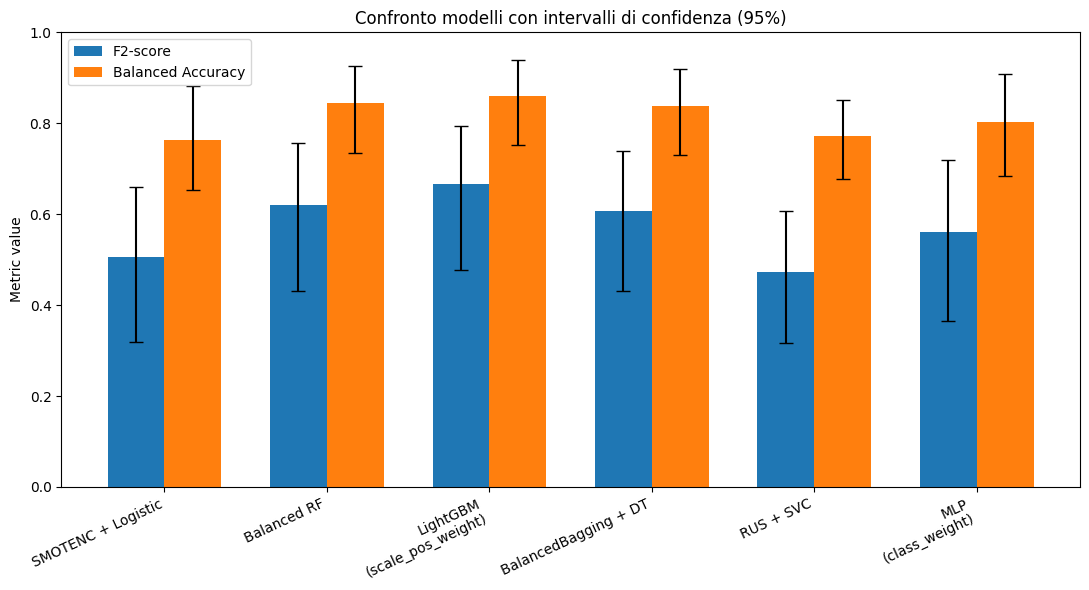

In [466]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------------
# 1. MODELLI
# -----------------------------------------------------------
models = [
    "SMOTENC + Logistic",
    "Balanced RF",
    "LightGBM\n(scale_pos_weight)",
    "BalancedBagging + DT",
    "RUS + SVC",
    "MLP\n(class_weight)"
]

# -----------------------------------------------------------
# 2. F2-SCORE: valori centrali e IC95%
# -----------------------------------------------------------
f2 = [0.505, 0.620, 0.667, 0.606, 0.473, 0.561]
f2_lower = [0.319, 0.430, 0.478, 0.430, 0.317, 0.366]
f2_upper = [0.659, 0.757, 0.794, 0.739, 0.606, 0.719]

# Calcolo error bars
f2_err = [
    [f2[i] - f2_lower[i] for i in range(len(f2))],  # errori verso il basso
    [f2_upper[i] - f2[i] for i in range(len(f2))]   # errori verso l'alto
]

# -----------------------------------------------------------
# 3. BALANCED ACCURACY: valori centrali e IC95%
# -----------------------------------------------------------
ba = [0.764, 0.844, 0.859, 0.839, 0.772, 0.802]
ba_lower = [0.654, 0.734, 0.752, 0.730, 0.678, 0.685]
ba_upper = [0.881, 0.927, 0.940, 0.920, 0.852, 0.908]

# Calcolo error bars
ba_err = [
    [ba[i] - ba_lower[i] for i in range(len(ba))],
    [ba_upper[i] - ba[i] for i in range(len(ba))]
]

# -----------------------------------------------------------
# 4. PLOT
# -----------------------------------------------------------
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(x - width/2, f2, width, yerr=f2_err, capsize=5, label='F2-score')
ax.bar(x + width/2, ba, width, yerr=ba_err, capsize=5, label='Balanced Accuracy')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel("Metric value")
ax.set_title("Confronto modelli con intervalli di confidenza (95%)")
ax.legend()

plt.tight_layout()
plt.show()
